В цьому ноутбуці ми проведемо дослідницький аналіз даних про історичні платежі по кредитам клієнтами.

[Опис колонок в даних тут.](https://drive.google.com/file/d/1Yp2aOdC33QFAVfTyxav_gKGwi4M9VN1Z/view?usp=sharing)

Цільова змінна TARGET тут має наступне значення: 1 – клієнт із труднощами з оплатою: він/вона прострочив платіж понад X днів принаймні одного з перших Y платежів кредиту в нашій вибірці, 0 – усі інші випадки

Задача - виявити, яким клієнтам видавати кредит, а яким - не варто, бо вони з високою імовірністю його не повернуть.

Дані взяті з [Kaggle](https://www.kaggle.com/datasets/gauravduttakiit/loan-defaulter). Прошу використовувати саме ті, які надані в нашому курсі, аби нам бути впевненими, що ми точно працюємо з одними і тими ж даними.

# Importing required libraries

In [388]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

# Data import

In [389]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [390]:
ls drive/MyDrive/ML

application_data.csv.zip        columns_description.csv
application_data_processed.zip  previous_application.csv.zip


In [391]:
descr = pd.read_csv("drive/MyDrive/ML/columns_description.csv")

In [392]:
df = pd.read_csv("drive/MyDrive/ML/application_data.csv.zip")

In [393]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

# Data structure check

In [394]:
df.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [395]:
df.shape

(307511, 122)

We have ~307k rows and 122 columns.

## Statistical report for numeric variables

In [396]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,307511.00,307511.00,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,307511.00,307511.00,104582.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307509.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,134133.00,306851.00,246546.00,151450.00,127568.00,157504.00,103023.00,92646.00,143620.00,152683.00,154491.00,98869.00,124921.00,97312.00,153161.00,93997.00,137829.00,151450.00,127568.00,157504.00,103023.00,92646.00,143620.00,152683.00,154491.00,98869.00,124921.00,97312.00,153161.00,93997.00,137829.00,151450.00,127568.00,157504.00,103023.00,92646.00,143620.00,152683.00,154491.00,98869.00,124921.00,97312.00,153161.00,93997.00,137829.00,159080.00,306490.00,306490.00,306490.00,306490.00,307510.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.08,0.42,168797.92,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,-4986.12,-2994.20,12.06,1.00,0.82,0.20,1.00,0.28,0.06,2.15,2.05,2.03,12.06,0.02,0.05,0.04,0.08,0.23,0.18,0.50,0.51,0.51,0.12,0.09,0.98,0.75,0.04,0.08,0.15,0.23,0.23,0.07,0.10,0.11,0.01,0.03,0.11,0.09,0.98,0.76,0.04,0.07,0.15,0.22,0.23,0.06,0.11,0.11,0.01,0.03,0.12,0.09,0.98,0.76,0.04,0.08,0.15,0.23,0.23,0.07,0.10,0.11,0.01,0.03,0.10,1.42,0.14,1.41,0.10,-962.86,0.00,0.71,0.00,0.02,0.09,0.00,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.27,0.72,237123.15,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,3522.89,1509.45,11.94,0.00,0.38,0.40,0.04,0.45,0.23,0.91,0.51,0.50,3.27,0.12,0.22,0.20,0.27,0.42,0.38,0.21,0.19,0.19,0.11,0.08,0.06,0.11,0.08,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.10,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.08,0.13,0.10,0.15,0.16,0.08,0.09,0.11,0.05,0.07,0.11,2.40,0.45,2.38,0.36,826.81,0.

# Analysis of categorical variables

In [397]:
df.select_dtypes(include = "object").columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [398]:
len(df.select_dtypes(include = "object").columns)

16

The data contains 16 `categorical` variables

# Analysis of numerical variables

In [399]:
number_df = df.select_dtypes(include="number")

In [400]:
number_df.columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [401]:
len(number_df.columns)

106

The data contains 106 `numerical` variables

In [402]:
number_df.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.00,406597.50,24700.50,351000.00,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,1.00,2,2,10,0,0,0,0,0,0,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.01,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,0,270000.00,1293502.50,35698.50,1129500.00,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,2.00,1,1,11,0,0,0,0,0,0,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,0.07,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,0,67500.00,135000.00,6750.00,135000.00,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,1.00,2,2,9,0,0,0,0,0,0,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,0,135000.00,312682.50,29686.50,297000.00,0.01,-19005,-3039,-9833.00,-2437,NaN,1,1,0,1,0,0,2.00,2,2,17,0,0,0,0,0,0,NaN,0.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00,0.00,-617.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0,121500.00,513000.00,21865.50,513000.00,0.03,-19932,-3038,-4311.00,-3458,NaN,1,1,0,1,0,0,1.00,2,2,11,0,0,0,0,1,1,NaN,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-1106.00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0

# Working with incorrect data types

Checking if we have a column with the wrong data type

In [403]:
df.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
AMT_CREDIT,float64
AMT_ANNUITY,float64


By looking at the data and its corresponding data types, you can change the type of the SKU column.

In [404]:
df['SK_ID_CURR'] = df['SK_ID_CURR'].astype("str")

We can also change all `flag` columns to a data type that is more storage-efficient.

This is how much memory in MB our data currently takes up.

In [405]:
df.memory_usage().sum()/1024/1024

np.float64(286.22710037231445)

In [406]:
'flag' in 'SK_ID_CURR'.lower()

False

In [407]:
flag_cols = ['flag' in col.lower() for col in df.columns]

In [408]:
df[df.columns[flag_cols]].head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,N,Y,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,N,N,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Y,Y,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,N,Y,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,N,Y,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [409]:
df[df.columns[flag_cols]].nunique()

,0
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
FLAG_MOBIL,2
FLAG_EMP_PHONE,2
FLAG_WORK_PHONE,2
FLAG_CONT_MOBILE,2
FLAG_PHONE,2
FLAG_EMAIL,2
FLAG_DOCUMENT_2,2
FLAG_DOCUMENT_3,2


Each data type takes up a certain amount of bytes in memory. Let's find out how much 1 int8 type and 1 int64 type take up and how much memory we will save if we change the type.

In [410]:
import numpy as np
from sys import getsizeof

In [411]:
getsizeof(np.int64(1))

32

In [412]:
getsizeof(np.int8(1))

25

In [413]:
7 * df.shape[0] * sum(flag_cols) / 1024 / 1024

57.48000717163086

So we can potentially save 57 MB of memory! And transforming our data frame will be easier. Let's change the type.


In [414]:
str_flag_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

In [415]:
for col in str_flag_cols:
  df[col] = np.where(df[col]=='Y', 1, 0)

In [416]:
df[str_flag_cols].nunique()

,0
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2


In [417]:
df.columns[flag_cols]

Index(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
       'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
       'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
       'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
       'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
       'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
       'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'],
      dtype='object')

In [418]:
df[df.columns[flag_cols]] = df[df.columns[flag_cols]].astype('int8')

In [419]:
df.memory_usage().sum()/1024/1024

np.float64(228.7470932006836)

# Working with missing values

The simplest rule of thumb for handling missing values ​​is: if there are more than 40% missing values, delete the column; if there are less than 40%, analyze how to fill in the missing values ​​and whether it is necessary.

Typically, if the percentage of missing data is more than 10 and there is no clear (significantly prominent) mode (most frequent) value in the data, then we leave the data as is until using machine learning methods. Then, if the method requires filling in the missing values, we can experiment with fillings. It is also good practice to create a separate flag column (0/1) that indicates where the values ​​were missing - this will be an additional feature for the model.


Let's check if there are any null values ​​in our dataset

In [420]:
df.isnull().values.any()

np.True_

Let's check if there are any null values ​​in our dataset

In [421]:
df.isnull().values.sum()

np.int64(9152465)

Let's form a list of columns with null values

In [422]:
df.columns[df.isnull().any()]

Index(['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OWN_CAR_AGE',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
       'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI',
       'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMI

In [423]:
len(df.columns[df.isnull().any()])

67

A total of `67` columns have one or more NULL values ​​in the data

## Number and percentage of missing values ​​in columns

In [424]:
null_count = df.isnull().sum()
null_percentage = round((df.isnull().sum()/df.shape[0])*100, 2)

In [425]:
df.shape[0]

307511

In [426]:
null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
null_df.reset_index(drop = True, inplace = True)

In [427]:
null_df.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
48,COMMONAREA_AVG,214865,69.87
62,COMMONAREA_MODE,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
56,NONLIVINGAPARTMENTS_AVG,213514,69.43
86,FONDKAPREMONT_MODE,210295,68.39
54,LIVINGAPARTMENTS_AVG,210199,68.35
82,LIVINGAPARTMENTS_MEDI,210199,68.35
68,LIVINGAPARTMENTS_MODE,210199,68.35


## Removing columns with NULL values ​​> 40%

Let's list the columns with NULL values ​​> 40% into a list. We will remove these columns from the dataframe because they have too many missing values.

In [428]:
columns_to_be_deleted = null_df[null_df['null_percentage'] > 40].column_name.to_list()

In [429]:
len(columns_to_be_deleted)

49

Total `49` columns need to be deleted. Deleting them from the main dataframe **`df`**

In [430]:
df.drop(columns = columns_to_be_deleted, inplace = True)

Checking column count after deletion. There should only be `73` columns left

In [431]:
df.shape

(307511, 73)

## Checking columns with NULL values ​​< 40%

Creating a dataframe `null_df_under40` with columns where the percentage of missing values ​​is less than 40%

In [432]:
null_df_under40 = null_df[null_df['null_percentage'] < 40]

In [433]:
null_df_under40.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
28,OCCUPATION_TYPE,96391,31.35
43,EXT_SOURCE_3,60965,19.83
121,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50
120,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50
116,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50
119,AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
118,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
117,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
11,NAME_TYPE_SUITE,1292,0.42
92,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.33


### Analysis of `OCCUPATION_TYPE`

- zero values ​​= 31.35%

In [434]:
df['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,55186
Sales staff,32102
Core staff,27570
Managers,21371
Drivers,18603
High skill tech staff,11380
Accountants,9813
Medicine staff,8537
Security staff,6721


Replacing NULL values ​​with `Unknown` category

In [435]:
df['OCCUPATION_TYPE'].fillna(value = 'Unknown', inplace = True)

/tmp/ipython-input-2107983880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OCCUPATION_TYPE'].fillna(value = 'Unknown', inplace = True)


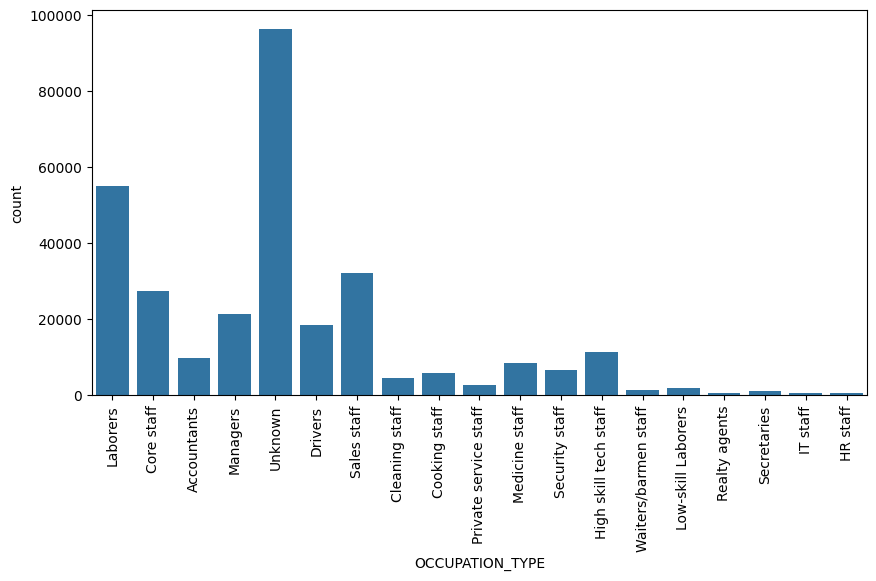

In [436]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "OCCUPATION_TYPE")
plt.xticks(rotation = 90)
plt.show()

**Observation**
- If you look at the graph, `Laborers` have the highest number of loan applicants
- For imputation, it is better to leave the data as is (missing values ​​are 31.35%) and not to impute by some constant like mode or min/max median if it is a numeric column, as this can skew the data in further calculations.

There is also the possibility of imputation using more "smart" methods, but we will explore them later, and for now we are doing what we can with some very simple transformations.

### Analysis of `EXT_SOURCE_3`

- missing values ​​= 19.83%

In [437]:
df.EXT_SOURCE_3.value_counts().head()

,count
EXT_SOURCE_3,
0.75,1460
0.71,1315
0.69,1276
0.67,1191
0.65,1154


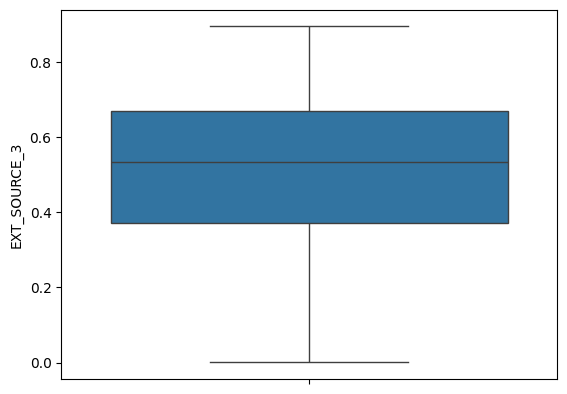

In [438]:
sns.boxplot(df.EXT_SOURCE_3)
plt.show()

Getting percentile values ​​for `EXT_SOURCE_3`

In [439]:
df.EXT_SOURCE_3.quantile(q = [0.25,0.5,0.75,1])

,EXT_SOURCE_3
0.25,0.37
0.50,0.54
0.75,0.67
1.00,0.90


Most repeated value in `EXT_SOURCE_3

In [440]:
df.EXT_SOURCE_3.mode()[0]

np.float64(0.746300213050371)

Checking the average value of `EXT_SOURCE_3`

In [441]:
df.EXT_SOURCE_3.mean()

np.float64(0.5108529061799658)

**Observation**
- Looking at the scatterplot, the median is 0.535276
- The most frequently occurring value is 0.74630
- The mean is 0.51085
- Although the mean and median are closer and can be used for imputation, since the percentage missing is higher (19.83%), it is better to leave the data as is and not perform imputation. If the method requires imputation, we can impute the data using the median and create another column that indicates which values ​​were imputed.

# Analysis of AMT_REQ_CREDIT_BUREAU columns with missing values

### Analysis of `AMT_REQ_CREDIT_BUREAU_YEAR`

In [442]:
amt_req_credit_cols = [
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_HOUR'
]

In [443]:
null_df[null_df.column_name.isin(amt_req_credit_cols)]

,column_name,null_count,null_percentage
116,AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.50
117,AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
118,AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
119,AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
120,AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50
121,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.50


Let's look at the summary statistics for the columns

In [444]:
df[amt_req_credit_cols].describe()

,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_HOUR
count,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,1.90,0.27,0.27,0.03,0.01,0.01
std,1.87,0.79,0.92,0.20,0.11,0.08
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,0.00,0.00,0.00,0.00
75%,3.00,0.00,0.00,0.00,0.00,0.00
max,25.00,261.00,27.00,8.00,9.00,4.00


In [445]:
df[amt_req_credit_cols].mode()

,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_HOUR
0,0.00,0.00,0.00,0.00,0.00,0.00


**Observation**
- The mean, mode and median are different and given that the missing percentage is 13.50%, it is better to leave the data as is and not perform imputations to avoid severe distortion

# Check for columns with NULL values ​​> 0% and < 1%

Creating a `null_df_under1` dataframe with percentage of missing values ​​> 0% and < 1% in each column

In [446]:
null_df_under1 = null_df[(null_df['null_percentage'] > 0) & (null_df['null_percentage'] < 1)]

In [447]:
null_df_under1.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
11,NAME_TYPE_SUITE,1292,0.42
92,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.33
91,OBS_30_CNT_SOCIAL_CIRCLE,1021,0.33
93,OBS_60_CNT_SOCIAL_CIRCLE,1021,0.33
94,DEF_60_CNT_SOCIAL_CIRCLE,1021,0.33
42,EXT_SOURCE_2,660,0.21
10,AMT_GOODS_PRICE,278,0.09


## Analysis of the `NAME_TYPE_SUITE` column

In [448]:
null_df_under1[null_df_under1.column_name == 'NAME_TYPE_SUITE']

,column_name,null_count,null_percentage
11,NAME_TYPE_SUITE,1292,0.42


In [449]:
df['NAME_TYPE_SUITE'].value_counts()

,count
NAME_TYPE_SUITE,
Unaccompanied,248526
Family,40149
"Spouse, partner",11370
Children,3267
Other_B,1770
Other_A,866
Group of people,271


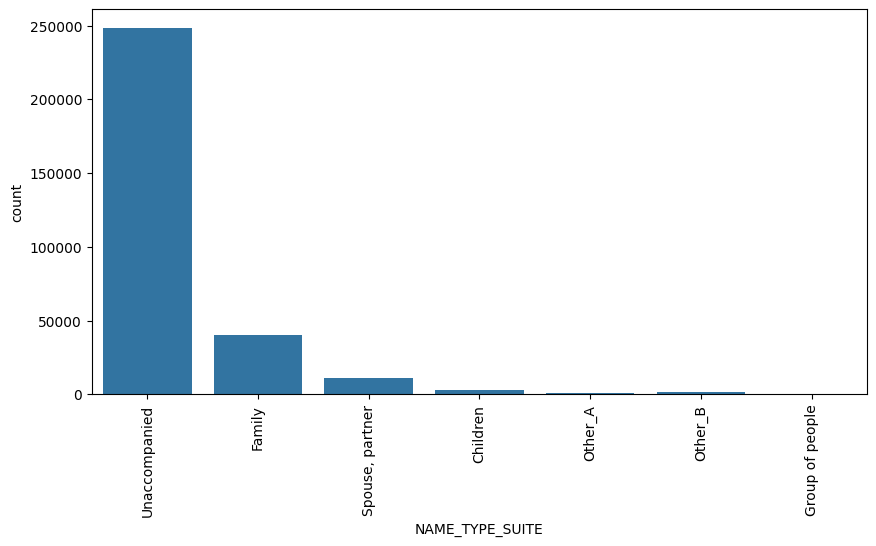

In [450]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "NAME_TYPE_SUITE")
plt.xticks(rotation = 90)
plt.show()

**Observation**
- Looking at the graph, the `Unaccompanied` category has the highest number of loan applicants. So, most of the borrowers decide to apply for a loan without an escort.
- We can continue to impute `Unaccompanied` in the dataframe, but it is better to prefer the second option.
- We could also impute the data with the value `NA` since this column is categorical.
- Similarly, if less than 1% of the data is missing in a column, we can omit it. But if we remove all the data in all the columns where <=1% of the data is missing, we may remove too much data. So I mostly keep the data as much as possible.

In [451]:
df['NAME_TYPE_SUITE'].fillna('NA', inplace=True)

/tmp/ipython-input-1528124425.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NAME_TYPE_SUITE'].fillna('NA', inplace=True)


## Analysis of `OBS_30_CNT_SOCIAL_CIRCLE`

In [452]:
null_df_under1[null_df_under1.column_name == 'OBS_30_CNT_SOCIAL_CIRCLE']

,column_name,null_count,null_percentage
91,OBS_30_CNT_SOCIAL_CIRCLE,1021,0.33


In [453]:
df.OBS_30_CNT_SOCIAL_CIRCLE.value_counts().head(10)

,count
OBS_30_CNT_SOCIAL_CIRCLE,
0.00,163910
1.00,48783
2.00,29808
3.00,20322
4.00,14143
5.00,9553
6.00,6453
7.00,4390
8.00,2967


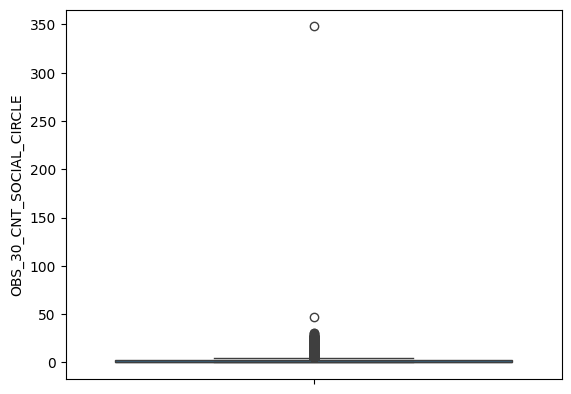

In [454]:
sns.boxplot(df.OBS_30_CNT_SOCIAL_CIRCLE)
plt.show()

Calculation of percentiles `OBS_30_CNT_SOCIAL_CIRCLE`

In [455]:
df.OBS_30_CNT_SOCIAL_CIRCLE.quantile(q = [0.25,0.5,0.75,1])

,OBS_30_CNT_SOCIAL_CIRCLE
0.25,0.00
0.50,0.00
0.75,2.00
1.00,348.00


Most repeated value in `OBS_30_CNT_SOCIAL_CIRCLE`

In [456]:
df.OBS_30_CNT_SOCIAL_CIRCLE.mode()[0]

np.float64(0.0)

Average value of `OBS_30_CNT_SOCIAL_CIRCLE`

In [457]:
df.OBS_30_CNT_SOCIAL_CIRCLE.mean()

np.float64(1.4222454239942575)

**Observation**
- Looking at the scatterplot, the median is 0.0
- The most frequently occurring value is 0.0
- The mean is 1.4222
- There are two outliers at 50 and 350.
- The median and mode are close (given the range of data in this column) and can be used for imputation. This will not introduce bias since the percentage of missing values ​​is small (0.33%)

In [458]:
df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_30_CNT_SOCIAL_CIRCLE'].median(), inplace=True)

/tmp/ipython-input-1727889282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_30_CNT_SOCIAL_CIRCLE'].median(), inplace=True)


Analysis and filling of blank values ​​in columns with a small percentage of missing values



- DEF_30_CNT_SOCIAL_CIRCLE
- EXT_SOURCE_2
- OBS_60_CNT_SOCIAL_CIRCLE
- DEF_60_CNT_SOCIAL_CIRCLE
- AMT_GOODS_PRICE

In [459]:
def missing_lt1_analysis(column):
    print('Number of missing values ​​in a column\n')
    display(null_df_under1[null_df_under1.column_name == column])
    print('\nNumber of occurrences of the top 5 frequency values ​​in the column\n')
    display(df[column].value_counts().head())

    sns.boxplot(df[column])
    plt.show()

    print(f"\nColumn percentiles\n")
    display(df[column].quantile(q = [0.25,0.5,0.75,0.99,1]))
    print(f"\nMost frequent column value\n")
    display(df[column].mode()[0])
    print(f"\nAverage column value\n")
    display(df[column].mean())

## Analysis of `DEF_30_CNT_SOCIAL_CIRCLE`

Number of missing values ​​in a column



,column_name,null_count,null_percentage
92,DEF_30_CNT_SOCIAL_CIRCLE,1021,0.33



Number of occurrences of the top 5 frequency values ​​in the column



,count
DEF_30_CNT_SOCIAL_CIRCLE,
0.00,271324
1.00,28328
2.00,5323
3.00,1192
4.00,253


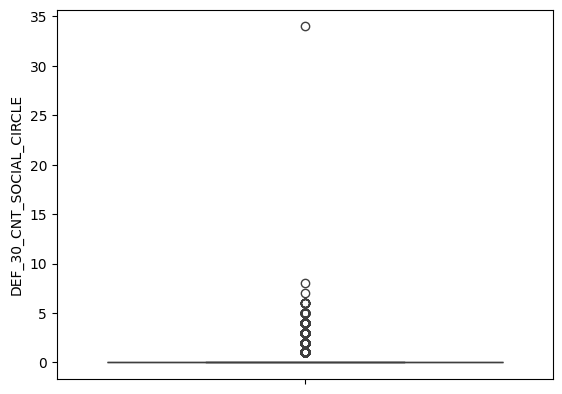


Column percentiles



,DEF_30_CNT_SOCIAL_CIRCLE
0.25,0.00
0.50,0.00
0.75,0.00
0.99,2.00
1.00,34.00



Most frequent column value



np.float64(0.0)


Average column value



np.float64(0.1434206662533851)

In [460]:
missing_lt1_analysis('DEF_30_CNT_SOCIAL_CIRCLE')

**Observation**
- The 99th percentile is 2. There are ~7 outliers, the largest being ~33.
- The mean and median are closer and can be used for imputation. This will not introduce bias as the percentage of missing values ​​is small (0.33%)

In [461]:
df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(df['DEF_30_CNT_SOCIAL_CIRCLE'].median(), inplace=True)

/tmp/ipython-input-2690385044.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(df['DEF_30_CNT_SOCIAL_CIRCLE'].median(), inplace=True)


## Analysis of `EXT_SOURCE_2`

Number of missing values ​​in a column



,column_name,null_count,null_percentage
42,EXT_SOURCE_2,660,0.21



Number of occurrences of the top 5 frequency values ​​in the column



,count
EXT_SOURCE_2,
0.29,721
0.26,417
0.27,343
0.16,322
0.27,306


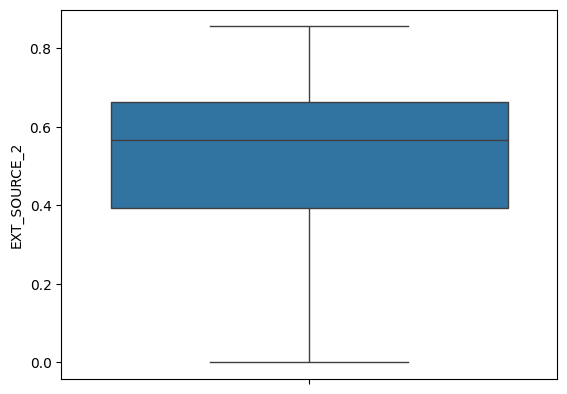


Column percentiles



,EXT_SOURCE_2
0.25,0.39
0.50,0.57
0.75,0.66
0.99,0.78
1.00,0.85



Most frequent column value



np.float64(0.2858978721410488)


Average column value



np.float64(0.5143926741308462)

In [462]:
missing_lt1_analysis('EXT_SOURCE_2')

**Observations**
- There are no outliers in the data set
- The mean and median are close and can be used for imputation. This will not introduce bias as the percentage of missing values ​​is small (0.21%)

In [463]:
df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].median(), inplace=True)

/tmp/ipython-input-2881929166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].median(), inplace=True)


## Analysis of `OBS_60_CNT_SOCIAL_CIRCLE`

Number of missing values ​​in a column



,column_name,null_count,null_percentage
93,OBS_60_CNT_SOCIAL_CIRCLE,1021,0.33



Number of occurrences of the top 5 frequency values ​​in the column



,count
OBS_60_CNT_SOCIAL_CIRCLE,
0.00,164666
1.00,48870
2.00,29766
3.00,20215
4.00,13946


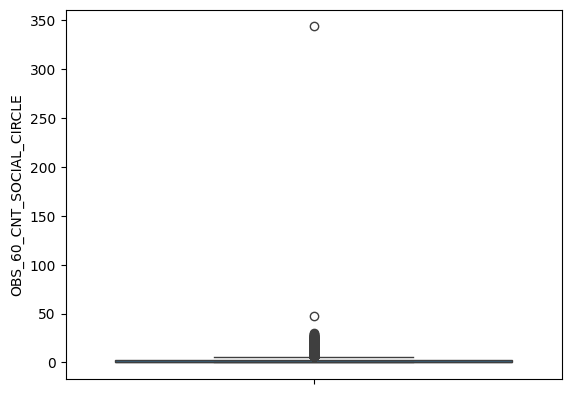


Column percentiles



,OBS_60_CNT_SOCIAL_CIRCLE
0.25,0.00
0.50,0.00
0.75,2.00
0.99,10.00
1.00,344.00



Most frequent column value



np.float64(0.0)


Average column value



np.float64(1.4052921791901856)

In [464]:
missing_lt1_analysis('OBS_60_CNT_SOCIAL_CIRCLE')

**Observation**
- The 99th percentile is 10. There is a noticeable outlier around 50 and 350.
- The mean and median are closer and can be used for imputation. This will not introduce bias because the percentage of missing values ​​is small (0.33%)

In [465]:
df['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median(), inplace=True)

/tmp/ipython-input-1535247501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median(), inplace=True)


## Analysis of `DEF_60_CNT_SOCIAL_CIRCLE`

Number of missing values ​​in a column



,column_name,null_count,null_percentage
94,DEF_60_CNT_SOCIAL_CIRCLE,1021,0.33



Number of occurrences of the top 5 frequency values ​​in the column



,count
DEF_60_CNT_SOCIAL_CIRCLE,
0.00,280721
1.00,21841
2.00,3170
3.00,598
4.00,135


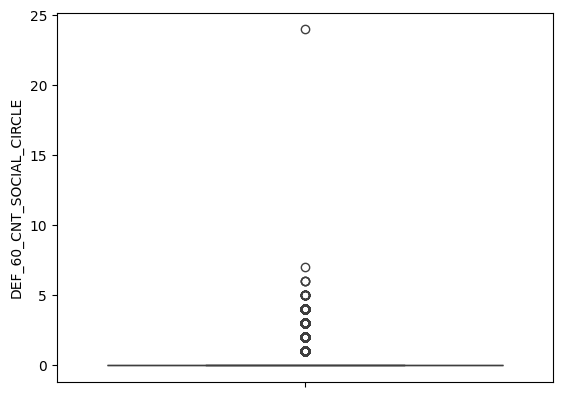


Column percentiles



,DEF_60_CNT_SOCIAL_CIRCLE
0.25,0.00
0.50,0.00
0.75,0.00
0.99,2.00
1.00,24.00



Most frequent column value



np.float64(0.0)


Average column value



np.float64(0.10004894123788705)

In [466]:
missing_lt1_analysis('DEF_60_CNT_SOCIAL_CIRCLE')

**Observation**
- The 99th percentile is 2. There are ~7 outliers, the largest being ~24.
- The mean and median are closer and can be used for imputation. This will not introduce bias as the percentage of missing values ​​is small (0.33%)

In [467]:
df['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median(), inplace=True)

/tmp/ipython-input-1535247501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median(), inplace=True)


## Analysis of  `AMT_GOODS_PRICE`

Number of missing values ​​in a column



,column_name,null_count,null_percentage
10,AMT_GOODS_PRICE,278,0.09



Number of occurrences of the top 5 frequency values ​​in the column



,count
AMT_GOODS_PRICE,
450000.00,26022
225000.00,25282
675000.00,24962
900000.00,15416
270000.00,11428


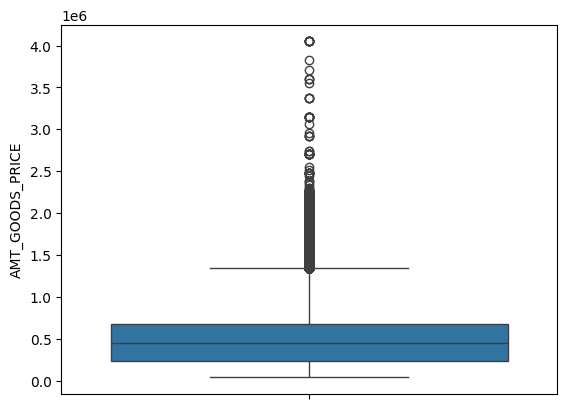


Column percentiles



,AMT_GOODS_PRICE
0.25,238500.00
0.50,450000.00
0.75,679500.00
0.99,1800000.00
1.00,4050000.00



Most frequent column value



np.float64(450000.0)


Average column value



np.float64(538396.2074288895)

In [468]:
missing_lt1_analysis('AMT_GOODS_PRICE')

**Observation**
- Although there are values ​​above 2500000, they cannot be considered outliers as they could be actual prices of goods
- The mean and median are exactly the same and can be used for imputation. This will not introduce bias as the percentage of missing values ​​is small (0.09%)

In [469]:
df['AMT_GOODS_PRICE'].fillna(df['AMT_GOODS_PRICE'].median(), inplace=True)

/tmp/ipython-input-1969904191.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AMT_GOODS_PRICE'].fillna(df['AMT_GOODS_PRICE'].median(), inplace=True)


# Dealing with incorrect/unknown data values

### Analysis of `CODE_GENDER`

Checking the value range



In [470]:
df['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


Gender must be male or female only. A value of `XNA` may indicate that the value was not provided by the applicant or was omitted by the loan officer reviewing the application

In [471]:
df[df['CODE_GENDER'] == 'XNA']

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
35657,141289,0,Revolving loans,XNA,1,1,0,207000.00,382500.00,19125.00,337500.00,Unaccompanied,Working,Secondary / secondary special,Married,Municipal apartment,0.02,-20232,-10044,-10024.00,-3537,1,1,1,1,1,0,Unknown,2.00,3,3,TUESDAY,10,0,0,0,0,0,0,Business Entity Type 1,0.30,0.46,0.00,0.00,0.00,0.00,-286.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
38566,144669,0,Revolving loans,XNA,0,1,2,157500.00,270000.00,13500.00,225000.00,Family,Working,Secondary / secondary special,Married,House / apartment,0.03,-13717,-2797,-2241.00,-4659,1,1,1,1,1,0,Low-skill Laborers,4.00,2,2,FRIDAY,16,0,0,0,0,0,0,Industry: type 3,0.71,0.31,0.00,0.00,0.00,0.00,-493.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,3.00,0.00,4.00
83382,196708,0,Revolving loans,XNA,0,1,1,135000.00,405000.00,20250.00,225000.00,Unaccompanied,Working,Higher education,Married,House / apartment,0.04,-10647,-1228,-183.00,-1671,1,1,1,1,1,0,Core staff,3.00,2,2,THURSDAY,15,0,0,0,0,0,0,Kindergarten,0.66,0.08,7.00,1.00,7.00,1.00,-851.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
189640,319880,0,Revolving loans,XNA,1,1,0,247500.00,540000.00,27000.00,900000.00,Unaccompanied,Commercial associate,Incomplete higher,Civil marriage,House / apartment,0.04,-9649,-2293,-4099.00,-2326,1,1,1,1,1,0,Unknown,2.00,2,2,FRIDAY,15,0,0,0,0,0,0,Medicine,0.66,0.36,10.00,4.00,10.00,4.00,-1681.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,1.00,6.00


Since the data looks reliable, we will check the possibility of applying the imputation method.
- There are twice as many female applicants as male applicants
- So, we will equate `CODE_GENDER` to 'F'

In [472]:
df['CODE_GENDER_CHANGED'] = df['CODE_GENDER'].apply(lambda x: 1 if x == 'XNA' else 0)

In [473]:
df['CODE_GENDER'] = df['CODE_GENDER'].apply(lambda x: 'F' if x == 'XNA' else x)

Checking if `XNA` is removed

In [474]:
df['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202452
M,105059


### Analysis of `DAYS_BIRTH`

In [475]:
df['DAYS_BIRTH'].value_counts().head()

,count
DAYS_BIRTH,
-13749,43
-13481,42
-10020,41
-18248,41
-15771,40


There are ~17K+ unique entries, all of which appear to have negative values.

In [476]:
df['DAYS_BIRTH'].unique()

array([ -9461, -16765, -19046, ...,  -7951,  -7857, -25061])

In [477]:
df['DAYS_BIRTH'].nunique()

17460

In [478]:
df['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,307511.00
mean,-16037.00
std,4363.99
min,-25229.00
25%,-19682.00
50%,-15750.00
75%,-12413.00
max,-7489.00


Convert `Days Birth` to positive days

In [479]:
df['DAYS_BIRTH'] = df['DAYS_BIRTH'].apply(lambda x: -x if x < 0 else x)

In [480]:
df['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,307511.00
mean,16037.00
std,4363.99
min,7489.00
25%,12413.00
50%,15750.00
75%,19682.00
max,25229.00


All days in `DAYS_BIRTH` have positive values ​​- this may be more convenient for analysis.

#### Let's create a new column `YEARS_BIRTH` for ease of analysis

In [481]:
df['YEARS_BIRTH'] = df['DAYS_BIRTH'].apply(lambda x: round(x/365))

In [482]:
df['YEARS_BIRTH'] = df['DAYS_BIRTH'].apply(lambda x: round(x/365))

### Analysis of `NAME_FAMILY_STATUS`

In [483]:
df['NAME_FAMILY_STATUS'].value_counts()

,count
NAME_FAMILY_STATUS,
Married,196432
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088
Unknown,2


Gender must be male or female only. A value of `Unknown` may mean that the value was not provided by the applicant or was omitted by the loan officer reviewing the application.

In [484]:
df[df['NAME_FAMILY_STATUS'] == 'Unknown']

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CODE_GENDER_CHANGED,YEARS_BIRTH
41982,148605,0,Revolving loans,M,0,1,0,450000.00,675000.00,33750.00,450000.00,NA,Commercial associate,Lower secondary,Unknown,Municipal apartment,0.02,12396,-1161,-3265.00,-4489,1,1,1,1,1,0,Managers,NaN,2,2,THURSDAY,15,0,1,1,0,1,1,Insurance,0.70,NaN,3.00,0.00,3.00,0.00,-876.00,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,34
187348,317181,0,Revolving loans,F,0,1,0,202500.00,585000.00,29250.00,450000.00,NA,Commercial associate,Higher education,Unknown,House / apartment,0.03,12844,-232,-1597.00,-1571,1,1,0,1,0,0,Accountants,NaN,2,2,FRIDAY,14,0,0,0,0,0,0,Business Entity Type 2,0.65,0.67,1.00,0.00,1.00,0.00,-654.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00,0,35


In [485]:
df['NAME_FAMILY_STATUS'].value_counts(normalize = True) * 100

,proportion
NAME_FAMILY_STATUS,
Married,63.88
Single / not married,14.78
Civil marriage,9.68
Separated,6.43
Widow,5.23
Unknown,0.00


Since the data looks reliable, we will continue to test the imputation method.
- Married applicants make up over 63% of applicants.
- So, we will equate `NAME_FAMILY_STATUS` to `Married`.

In [486]:
df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].apply(lambda x: 'Married' if x == 'Unknown' else x)

Checking if `Unknown` is removed

In [487]:
df['NAME_FAMILY_STATUS'].value_counts()

,count
NAME_FAMILY_STATUS,
Married,196434
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088


### Analysis of `DAYS_EMPLOYED`

In [488]:
df['DAYS_EMPLOYED'].value_counts().head()

,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-230,151
-199,151


In [489]:
df['DAYS_EMPLOYED'].value_counts(normalize = True) * 100

,proportion
DAYS_EMPLOYED,
365243,18.01
-200,0.05
-224,0.05
-230,0.05
-199,0.05
...,...
-11471,0.00
-12878,0.00
-10573,0.00


In [490]:
len(df[df['DAYS_EMPLOYED'] < 365243])

252137

In [491]:
df[df['DAYS_EMPLOYED'] < 365243].DAYS_EMPLOYED.value_counts()

,count
DAYS_EMPLOYED,
-200,156
-224,152
-230,151
-199,151
-212,150
...,...
-12037,1
-16554,1
-11276,1


In [492]:
df['DAYS_EMPLOYED'].unique()

array([  -637,  -1188,   -225, ..., -12971, -11084,  -8694])

In [493]:
df['DAYS_EMPLOYED'].nunique()

12574

**Observations**
- There are ~55K+ records for which `DAYS_EMPLOYED` is 365243 days
- The remaining 252K+ records have negative days
- There are 12,574 unique values ​​for `DAYS_EMPLOYED`

- The `DAYS_EMPLOYED` column indicates how many days before the application date the person started their current job, the applicant/loan officer should enter negative values ​​to indicate days prior to the application date.<br>
- We convert negative values ​​in `DAYS_EMPLOYED` to positive days to standardize days when used in calculations

In [494]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: -x if x < 0 else x)

In [495]:
df['DAYS_EMPLOYED'].value_counts().head()

,count
DAYS_EMPLOYED,
365243,55374
200,156
224,152
230,151
199,151


We see that all days in `DAYS_EMPLOYED` have positive values.

**For ~55K+ records where `DAYS_EMPLOYED` is 365243 days**
- Converting this to years gives us 1000 years that are physically impossible to employ the applicant
- This corresponds to 18% of the data and cannot be an anomaly
- They could be either ``retired'' or ``unemployed'' and looking at the data our conclusion is correct

> There are two ways to handle this
>> 1) We leave the data as is and take this into account in the analysis OR <br>
>> 2) We calculate the average number of days employed excluding this category and enter it instead of the 365243 days for retirees. <br>
>> For unemployed, the number of days employed could be 0

*Note*
- We must take this scenario into account when calculating this column, as otherwise it will skew our results

In [496]:
df[df['DAYS_EMPLOYED'] == 365243].NAME_INCOME_TYPE.value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,55352
Unemployed,22


In [497]:
days_median = df[df['DAYS_EMPLOYED'] != 365243].DAYS_EMPLOYED.median()

In [498]:
df_days_employed = df['DAYS_EMPLOYED'].apply(lambda x: days_median if x==365243 else x)

<Axes: >

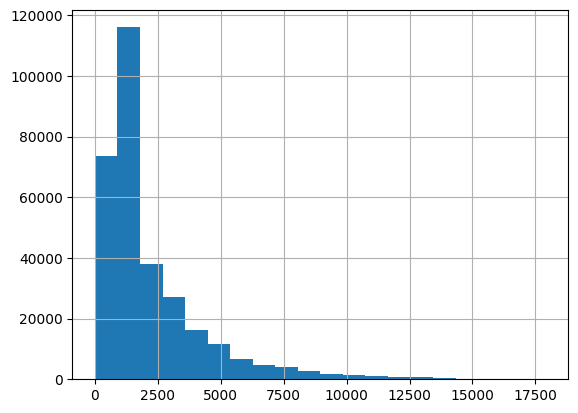

In [499]:
df_days_employed.hist(bins=20)

<Axes: >

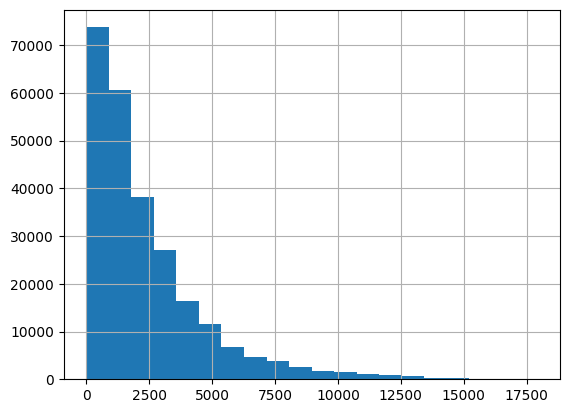

In [500]:
df[df['DAYS_EMPLOYED'] != 365243].DAYS_EMPLOYED.hist(bins=20)

In [501]:
df[df['DAYS_EMPLOYED'] == 365243].NAME_INCOME_TYPE.value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,55352
Unemployed,22


#### Let's create a new column `YEARS_EMPLOYED` for ease of analysis

In [502]:
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: round(x/365))

### Analysis of `DAYS_REGISTRATION`

In [503]:
df['DAYS_REGISTRATION'].value_counts().head()

,count
DAYS_REGISTRATION,
-1.00,113
-7.00,98
-6.00,96
-4.00,92
-2.00,92


In [504]:
df['DAYS_REGISTRATION'].value_counts(normalize = True).head()

,proportion
DAYS_REGISTRATION,
-1.00,0.00
-7.00,0.00
-6.00,0.00
-4.00,0.00
-2.00,0.00


In [505]:
df['DAYS_REGISTRATION'].unique()

array([ -3648.,  -1186.,  -4260., ..., -16396., -14558., -14798.])

In [506]:
df['DAYS_REGISTRATION'].nunique()

15688

Convert `DAYS_REGISTRATION` to positive days

In [507]:
df['DAYS_REGISTRATION'] = df['DAYS_REGISTRATION'].apply(lambda x: -x if x < 0 else x)

In [508]:
df['DAYS_REGISTRATION'].value_counts().head()

,count
DAYS_REGISTRATION,
1.00,113
7.00,98
6.00,96
4.00,92
2.00,92


All days in `DAYS_REGISTRATION` have positive values

#### Let's create a new column `YEARS_REGISTRATION` for ease of analysis

In [509]:
df['YEARS_REGISTRATION'] = df['DAYS_REGISTRATION'].apply(lambda x: round(x/365))

### Analysis of `DAYS_ID_PUBLISH`

In [510]:
df['DAYS_ID_PUBLISH'].value_counts().head()

,count
DAYS_ID_PUBLISH,
-4053,169
-4095,162
-4046,161
-4417,159
-4256,158


In [511]:
df['DAYS_ID_PUBLISH'].value_counts(normalize = True).head()

,proportion
DAYS_ID_PUBLISH,
-4053,0.00
-4095,0.00
-4046,0.00
-4417,0.00
-4256,0.00


In [512]:
df['DAYS_ID_PUBLISH'].unique()

array([-2120,  -291, -2531, ..., -6194, -5854, -6211])

In [513]:
df['DAYS_ID_PUBLISH'].nunique()

6168

Convert `DAYS_ID_PUBLISH` to positive days

In [514]:
df['DAYS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'].apply(lambda x: -x if x < 0 else x)

In [515]:
df['DAYS_ID_PUBLISH'].value_counts().head()

,count
DAYS_ID_PUBLISH,
4053,169
4095,162
4046,161
4417,159
4256,158


All days in `DAYS_ID_PUBLISH` have positive values

#### Let's create a new column `YEARS_ID_PUBLISH` for ease of analysis

In [516]:
df['YEARS_ID_PUBLISH'] = df['DAYS_ID_PUBLISH'].apply(lambda x: round(x/365))

### Analysis of `DAYS_LAST_PHONE_CHANGE`

In [517]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts().head()

,count
DAYS_LAST_PHONE_CHANGE,
0.00,37672
-1.00,2812
-2.00,2318
-3.00,1763
-4.00,1285


In [518]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts(normalize = True).head()

,proportion
DAYS_LAST_PHONE_CHANGE,
0.00,0.12
-1.00,0.01
-2.00,0.01
-3.00,0.01
-4.00,0.00


In [519]:
df['DAYS_LAST_PHONE_CHANGE'].unique()

array([-1134.,  -828.,  -815., ..., -3988., -3899., -3538.])

In [520]:
df['DAYS_LAST_PHONE_CHANGE'].nunique()

3773

Convert `DAYS_LAST_PHONE_CHANGE` to positive days

In [521]:
df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].apply(lambda x: -x if x < 0 else x)

In [522]:
df['DAYS_LAST_PHONE_CHANGE'].value_counts().head()

,count
DAYS_LAST_PHONE_CHANGE,
0.00,37672
1.00,2812
2.00,2318
3.00,1763
4.00,1285


All days in `DAYS_LAST_PHONE_CHANGE` have positive values

#### Creating a new column `YEARS_LAST_PHONE_CHANGE` for ease of analysis

In [523]:
df['YEARS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].apply(lambda x: round(x/365,0))

# Functions for automation

### Creating an `age_cat` function to categorize data containing information about years

In [524]:
def age_cat(years):
    if years <= 20:
        return '0-20'
    elif years > 20 and years <= 30:
        return '20-30'
    elif years > 30 and years <= 40:
        return '30-40'
    elif years > 40 and years <= 50:
        return '40-50'
    elif years > 50 and years <= 60:
        return '50-60'
    elif years > 60 and years <= 70:
        return '60-70'
    elif years > 70:
        return '70+'

### Univariate (categorical vs. target) and bivariate (categorical vs. categorical) analysis (histogram) - categorical columns

In [525]:
import matplotlib.pyplot as plt


def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Normalized distribution of values ​​by category: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Number of data by category: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='TARGET')


### Calculate the minimum and maximum deviation range for numeric columns

In [526]:
def outlier_range(dataset,column):
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.75)
    IQR = Q3 - Q1
    Min_value = (Q1 - 1.5 * IQR)
    Max_value = (Q3 + 1.5 * IQR)
    return Max_value

# Working with outliers for numeric columns

In [527]:
import warnings

def dist_box(dataset, column):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.distplot(dataset[column], color = 'purple')
      pltname = 'Distribution schedule for ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(y = column, data = dataset, flierprops = red_diamond)
      pltname = 'Boxplot for ' + column
      plt.title(pltname)

      plt.show()

### Analysis of `CNT_CHILDREN`

In [528]:
df['CNT_CHILDREN'].value_counts().sort_values(ascending = False);

In [529]:
(df['CNT_CHILDREN'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
CNT_CHILDREN,
0,70.04
1,19.88
2,8.70
3,1.21
4,0.14


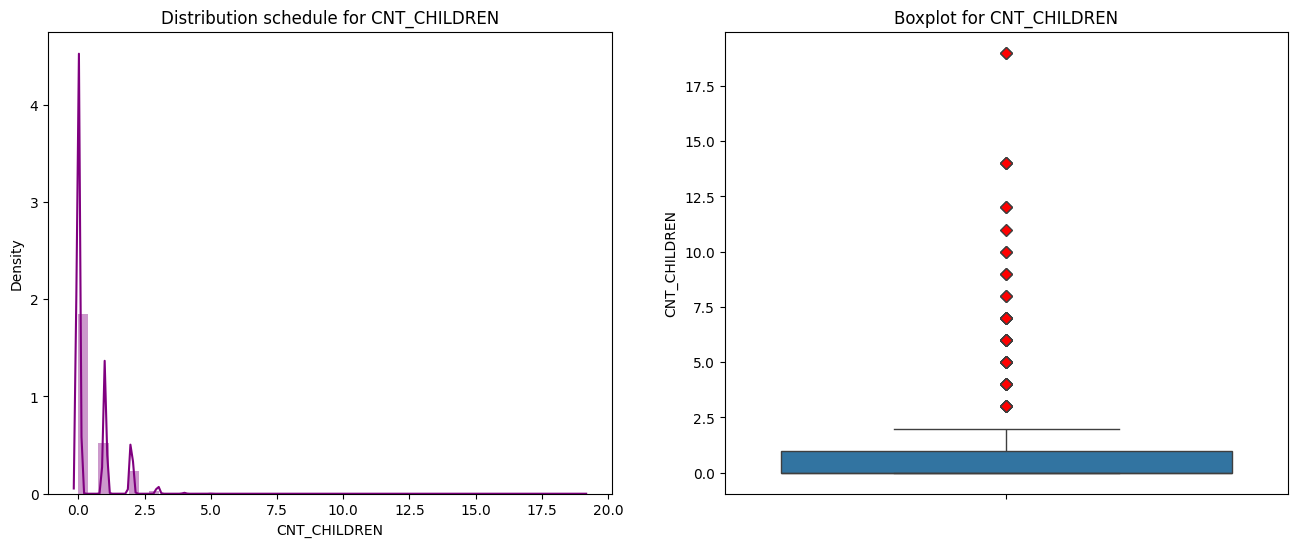

In [530]:
dist_box(df,'CNT_CHILDREN')

Let's calculate the IQR (Inter Quartile range)

In [531]:
Q1 = df['CNT_CHILDREN'].quantile(0.25)
Q3 = df['CNT_CHILDREN'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

1.0


In [532]:
Q1, Q3

(np.float64(0.0), np.float64(1.0))

The values ​​*before* (Q1 - 1.5 * IQR) and *after* (Q3 + 1.5 * IQR) are outliers

In [533]:
Min_value = (Q1 - 1.5 * IQR)
Max_value = (Q3 + 1.5 * IQR)
print("Minimum value up to which emissions exist: {}".format(Min_value))
print("Maximum value after which emissions exist: {}".format(Max_value))

Minimum value up to which emissions exist: -1.5
Maximum value after which emissions exist: 2.5


In [534]:
df[df['CNT_CHILDREN'].isin(range(10,20))].YEARS_BIRTH

,YEARS_BIRTH
34545,47
80948,39
132585,31
155369,30
171125,38
176011,49
183878,56
186820,41
265784,28
267998,42


In [535]:
df[df['CNT_CHILDREN'].isin([10])][['SK_ID_CURR', 'CNT_CHILDREN', 'YEARS_BIRTH']]

,SK_ID_CURR,CNT_CHILDREN,YEARS_BIRTH
132585,253779,10,31
186820,316580,10,41


**Observation**
- Looking at the data, we see that the number of applicants with more than 7 children is very minimal (2 or 3 in each category)
- Also, looking at the data for applicants with 10 children, the applicants are only 31 and 41 years old respectively. This looks like an isolated case and can be considered as an outlier
- Both the distribution and range plots clearly show that values ​​above 2.5 are outliers.

**Conclusion**
- Applicants with 3 or more children are outliers. We can provide a special analysis for these cases.

### Analysis of `AMT_INCOME_TOTAL`

In [536]:
df['AMT_INCOME_TOTAL'].value_counts().sort_values(ascending = False).head()

,count
AMT_INCOME_TOTAL,
135000.00,35750
112500.00,31019
157500.00,26556
180000.00,24719
90000.00,22483


In [537]:
(df['AMT_INCOME_TOTAL'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
AMT_INCOME_TOTAL,
135000.00,11.63
112500.00,10.09
157500.00,8.64
180000.00,8.04
90000.00,7.31


In [538]:
df['AMT_INCOME_TOTAL'].describe(percentiles = [0.75,0.99,0.999])

,AMT_INCOME_TOTAL
count,307511.00
mean,168797.92
std,237123.15
min,25650.00
50%,147150.00
75%,202500.00
99%,472500.00
99.9%,900000.00
max,117000000.00


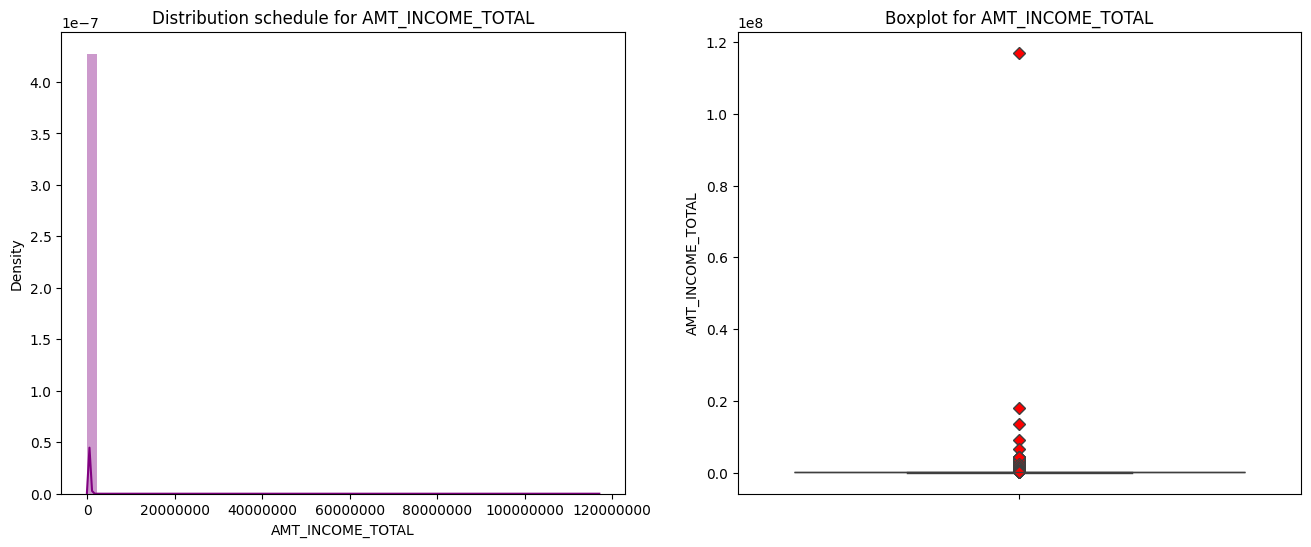

In [539]:
dist_box(df,'AMT_INCOME_TOTAL')

- The final result graphs are very thin, and we can see an outlier of about ~120 million.
- Let's plot the graph, considering only the income below the 99.9% value, i.e. 900 thousand.

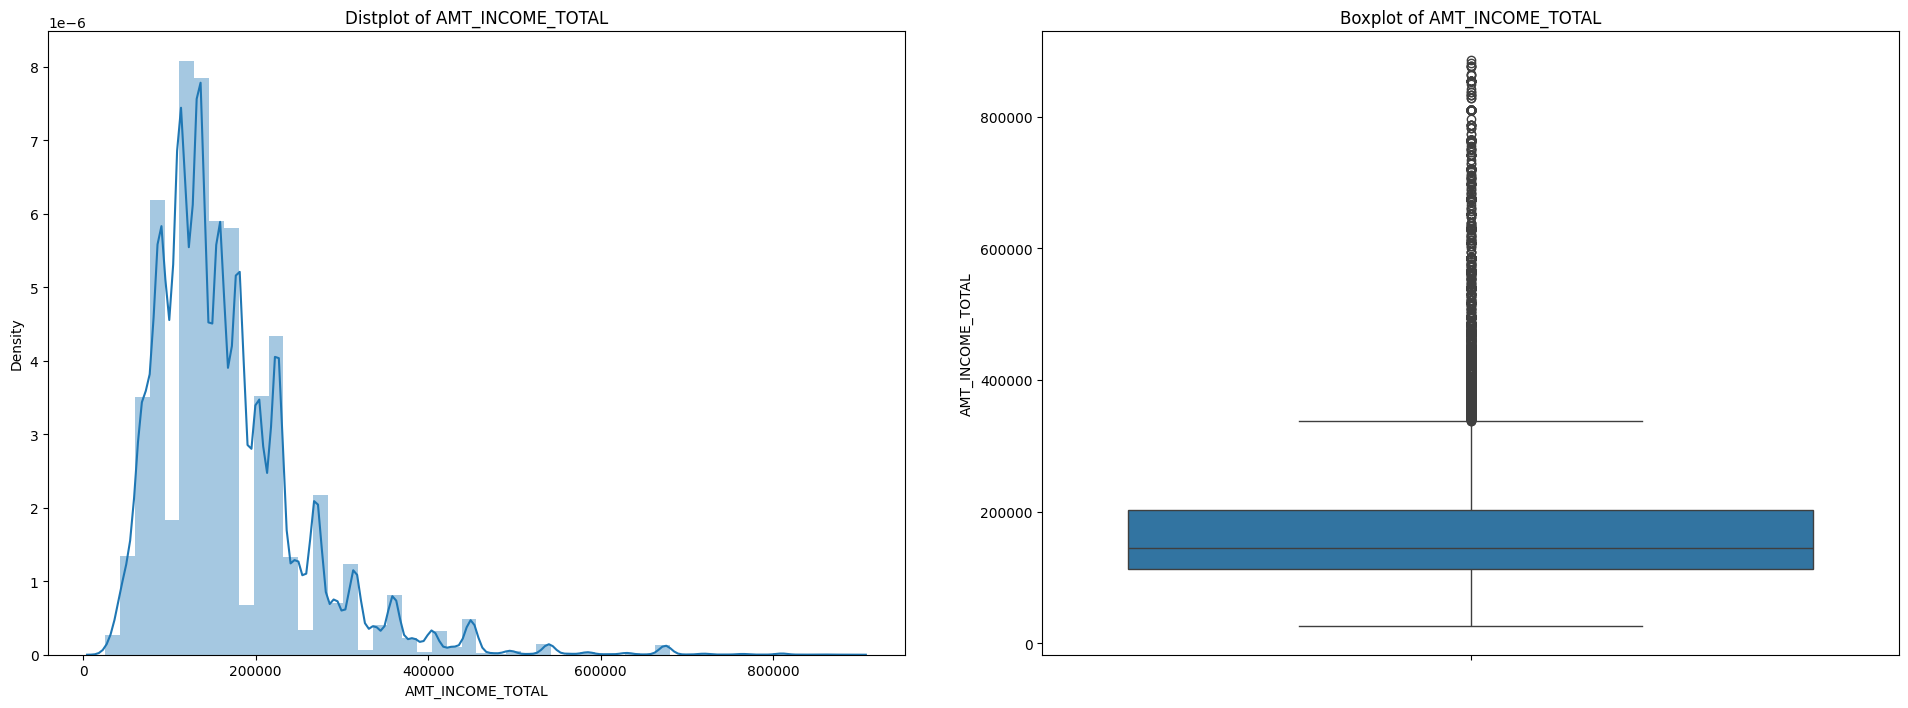

In [540]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.subplots(1,2 ,figsize = (20,8))

    plt.subplot(121)
    sns.distplot(df[df['AMT_INCOME_TOTAL'] < 900000].AMT_INCOME_TOTAL)
    pltname = 'Distplot of ' + 'AMT_INCOME_TOTAL'
    plt.title(pltname)

    plt.subplot(122)
    sns.boxplot(df[df['AMT_INCOME_TOTAL'] < 900000].AMT_INCOME_TOTAL)
    pltname = 'Boxplot of ' + 'AMT_INCOME_TOTAL'
    plt.title(pltname)

    plt.tight_layout(pad = 4)
    plt.show()

Now we can clearly see the distribution and range of the data in both graphs.
- This means that the values ​​above 900 thousand UAH of income are clearly outliers

In [ ]:
df[df['AMT_INCOME_TOTAL'] > 900000].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CODE_GENDER_CHANGED,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
1504,101769,0,Revolving loans,M,1,1,0,1080000.00,180000.00,9000.00,180000.00,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.07,13633,5536,3.00,4971,1,1,0,1,0,0,Unknown,2.00,1,1,FRIDAY,13,0,1,1,0,0,0,Business Entity Type 3,0.65,0.46,0.00,0.00,0.00,0.00,491.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0,37,15,0,14,1.00
1723,102015,0,Cash loans,F,0,1,0,1935000.00,269550.00,10534.50,225000.00,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.01,18636,365243,3401.00,2168,1,0,0,1,1,0,Unknown,2.00,2,2,MONDAY,11,0,0,0,0,0,0,XNA,0.27,0.33,1.00,0.00,1.00,0.00,381.00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0,51,1001,9,6,1.00
3371,103938,0,Cash loans,F,0,0,1,1350000.00,2410380.00,109053.00,2250000.00,NA,Commercial associate,Higher education,Married,House / apartment,0.07,12213,843,757.00,4132,1,1,0,1,1,0,Managers,3.00,1,1,SUNDAY,13,0,1,1,0,0,0,Housing,0.72,0.57,0.00,0.00,0.00,0.00,2.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.00,0.00,0.00,3.00,0.00,0.00,0,33,2,2,11,0.00
4603,105384,0,Revolving loans,F,1,1,0,1350000.00,405000.00,20250.00,405000.00,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.02,14781,4768,3469.00,4045,1,1,0,1,0,0,Managers,2.00,2,2,TUESDAY,12,0,0,0,0,0,0,Business Entity Type 3,0.66,0.73,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0,40,13,10,11,0.00
5673,106637,0,Cash loans,M,1,1,3,967500.00,450000.00,30073.50,450000.00,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.05,11901,546,2932.00,215,1,1,0,1,0,0,Managers,5.00,1,1,MONDAY,14,0,0,0,1,1,0,Business Entity Type 3,0.49,0.45,0.00,0.00,0.00,0.00,88.00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,1.00,1.00,0.00,0,33,1,8,1,0.00


**Observation**
- Looking at the data, we see that income over 900k UAH (99.9% of the value) is an outlier
- Both the scatterplot and the rangeplot clearly show us the same trend

**Conclusion**
- Applicants with income over 900k UAH (99.9% of the value) are outliers

### Analysis of `CNT_FAM_MEMBERS`

In [253]:
def outliers_analysis(df, column):
  display(df[column].describe(percentiles = [0.75,0.99,0.9999]))
  dist_box(df, column)

,CNT_FAM_MEMBERS
count,307509.00
mean,2.15
std,0.91
min,1.00
50%,2.00
75%,3.00
99%,5.00
99.99%,8.00
max,20.00


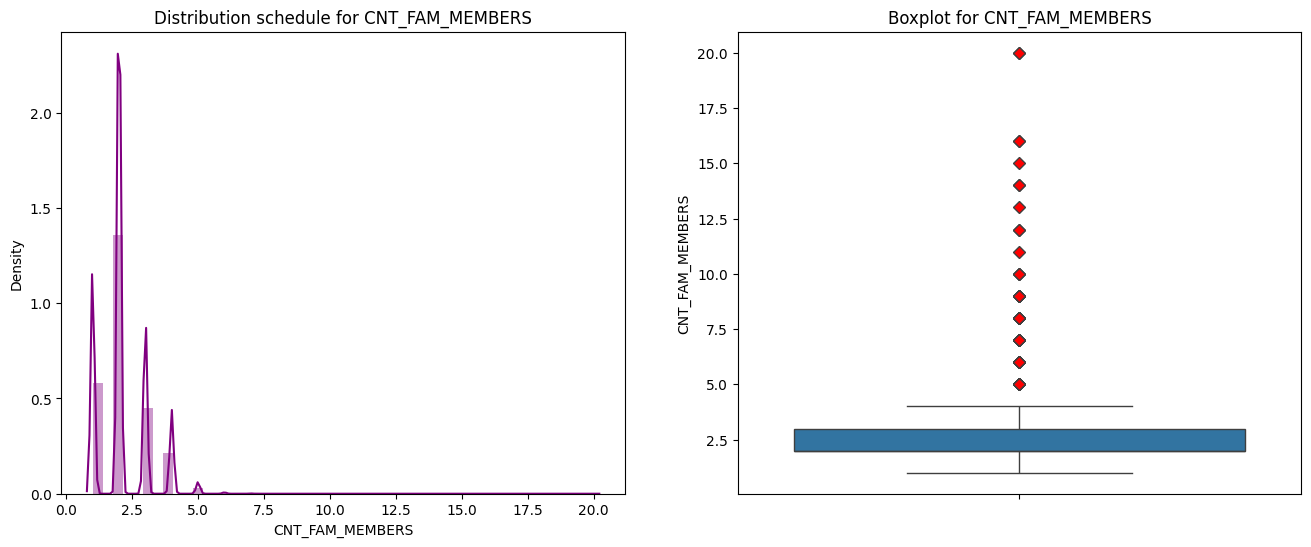

In [541]:
outliers_analysis(df, 'CNT_FAM_MEMBERS')

- For family members of 5 and above, the results are sparse, and there is a clear outlier of about 20
- Only 2 or 3 applicants with more than 10 family members
- Let's build a graph considering only family members whose number does not exceed 99.9%, i.e. 8

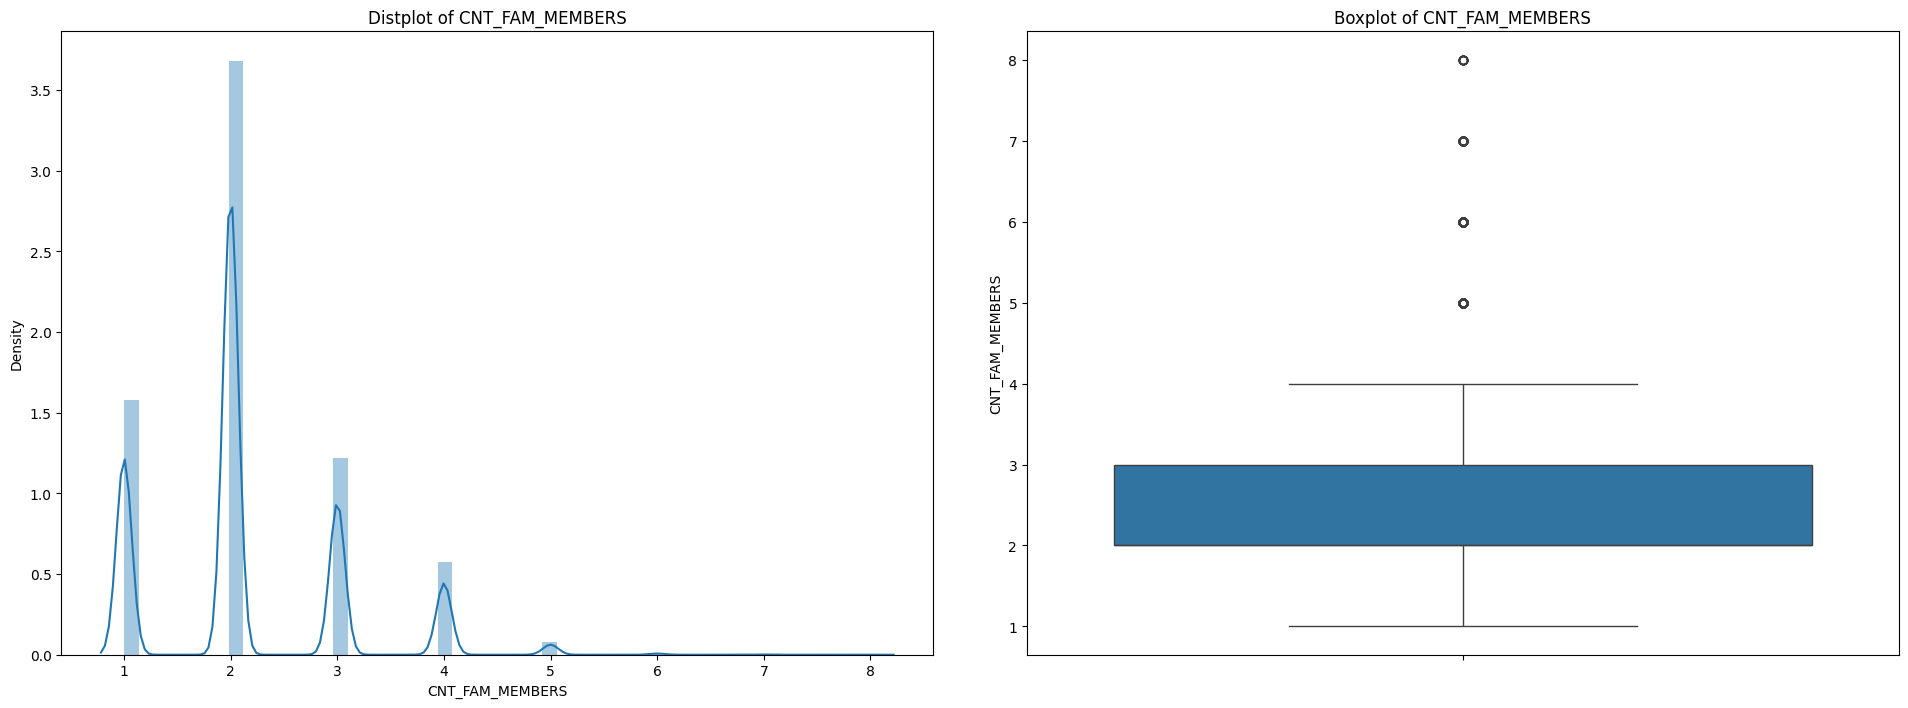

In [542]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.subplots(1,2 ,figsize = (20,8))

    plt.subplot(121)
    sns.distplot(df[df['CNT_FAM_MEMBERS'] <= 8].CNT_FAM_MEMBERS)
    pltname = 'Distplot of ' + 'CNT_FAM_MEMBERS'
    plt.title(pltname)

    plt.subplot(122)
    sns.boxplot(df[df['CNT_FAM_MEMBERS'] <= 8].CNT_FAM_MEMBERS)
    pltname = 'Boxplot of ' + 'CNT_FAM_MEMBERS'
    plt.title(pltname)

    plt.tight_layout(pad = 4)
    plt.show()

Now we can clearly see the distribution and range of the data in both graphs.
- This means that applicants who have 5 or more family members clearly stand out from the rest

## Analysis of `AMT_ANNUITY`

,AMT_ANNUITY
count,307499.00
mean,27108.57
std,14493.74
min,1615.50
50%,24903.00
75%,34596.00
99%,70006.50
99.99%,213291.00
max,258025.50


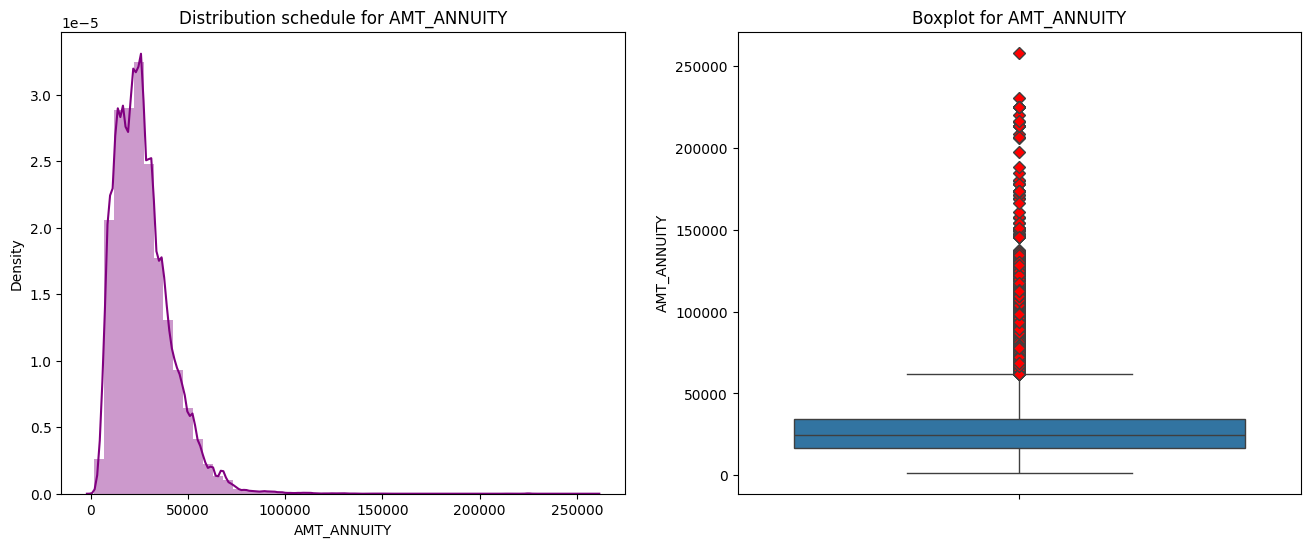

In [543]:
outliers_analysis(df, 'AMT_ANNUITY')

In [257]:
Q1 = df['AMT_ANNUITY'].quantile(0.25)
Q3 = df['AMT_ANNUITY'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

18072.0


*Values* *before* (Q1 - 1.5 * IQR) and *after* (Q3 + 1.5 * IQR) are outliers

In [545]:
Min_value = (Q1 - 1.5 * IQR)
Max_value = (Q3 + 1.5 * IQR)
print("Minimum value up to which emissions exist: {}".format(Min_value))
print("Maximum value after which emissions exist: {}".format(Max_value))

Minimum value up to which emissions exist: -1.5
Maximum value after which emissions exist: 2.5


- As can be seen from the scatter plot and range plot, there is a tendency towards outliers after the value 61704.0 (this value is obtained by `Max_value` using IQR formulas).
- We can verify the same by reproducing the same plots for the outlier value as shown below

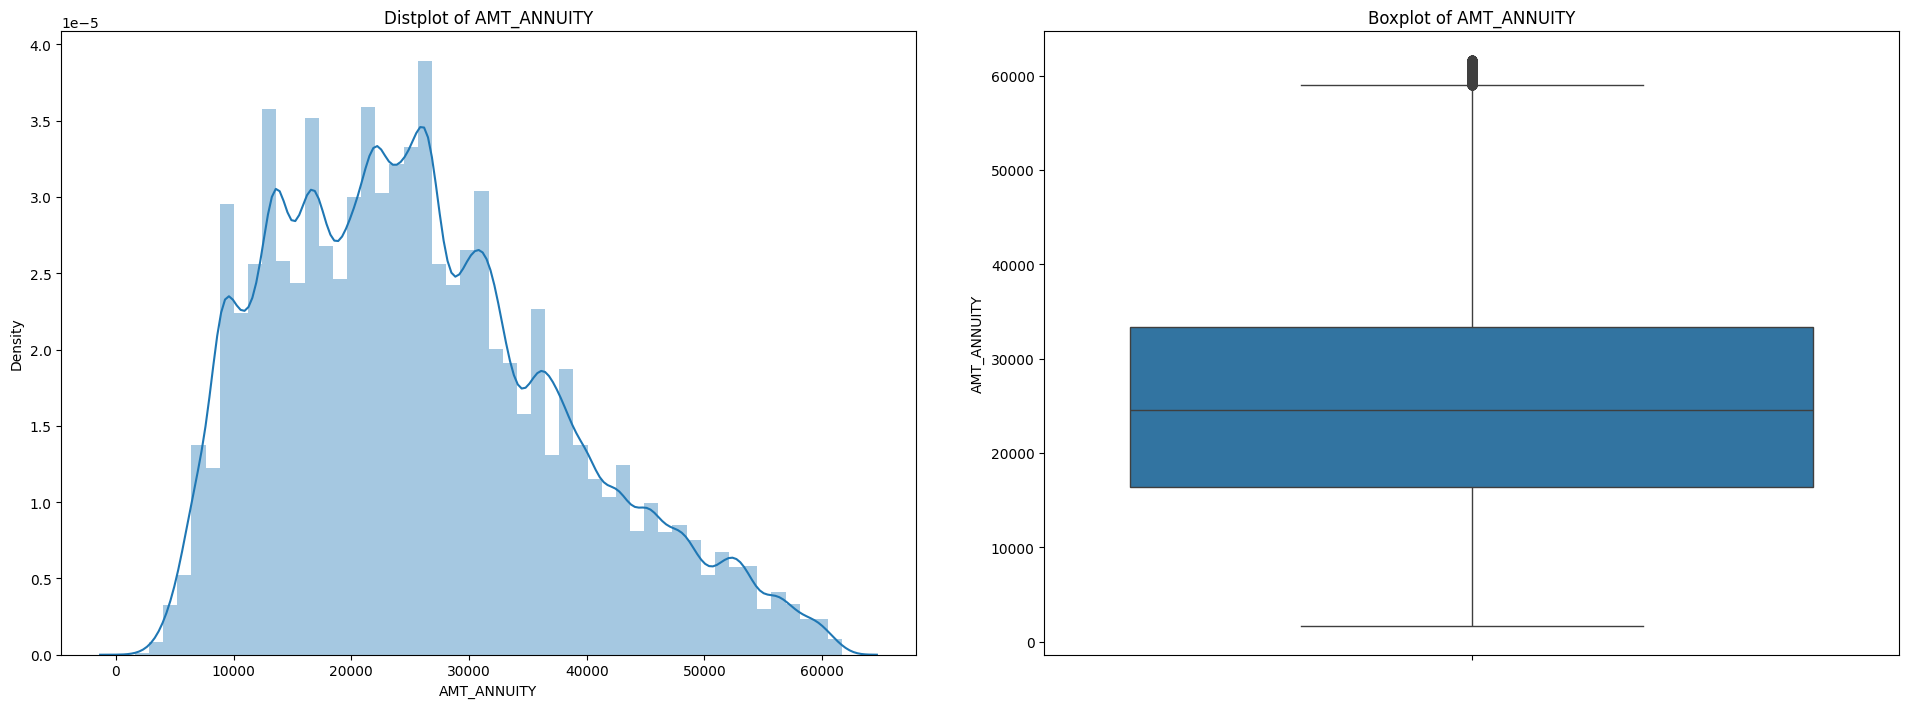

In [546]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.subplots(1,2 ,figsize = (20,8))

    plt.subplot(121)
    sns.distplot(df[df['AMT_ANNUITY'] <= 61704.0].AMT_ANNUITY)
    pltname = 'Distplot of ' + 'AMT_ANNUITY'
    plt.title(pltname)

    plt.subplot(122)
    sns.boxplot(df[df['AMT_ANNUITY'] <= 61704.0].AMT_ANNUITY)
    pltname = 'Boxplot of ' + 'AMT_ANNUITY'
    plt.title(pltname)

    plt.tight_layout(pad = 4)
    plt.show()

**Observation**
- As can be seen from the scatterplot and rangeplot, outliers tend to exist after the value 61704 (outlier values ​​are obtained by `Max_value` using IQR formulas)

**Conclusion**
- Applicants with `AMT_ANNUITY` above 61704 (calculated using IQR) are outliers

# Binning continuous columns for analysis

### Categorizing the `AMT_GOODS_PRICE` column

In [261]:
df['AMT_GOODS_PRICE'].value_counts().sort_values(ascending = False).head()

,count
AMT_GOODS_PRICE,
450000.00,26300
225000.00,25282
675000.00,24962
900000.00,15416
270000.00,11428


In [262]:
(df['AMT_GOODS_PRICE'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
AMT_GOODS_PRICE,
450000.00,8.55
225000.00,8.22
675000.00,8.12
900000.00,5.01
270000.00,3.72


In [263]:
df['AMT_GOODS_PRICE'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,AMT_GOODS_PRICE
count,307511.00
mean,538316.29
std,369288.98
min,40500.00
25%,238500.00
50%,450000.00
75%,679500.00
99%,1800000.00
99.99%,2933964.00
max,4050000.00


Let's divide the values ​​in `AMT_GOODS_PRICE` into 5 bins and create a new column `AMT_GOODS_PRICE_CATEGORY`.

In [264]:
df['AMT_GOODS_PRICE_CATEGORY'] = pd.cut(df['AMT_GOODS_PRICE'],
                                        bins = 5, labels = ['very low', 'low', 'medium', 'high', 'very high'])

In [265]:
df['AMT_GOODS_PRICE_CATEGORY'].value_counts()

,count
AMT_GOODS_PRICE_CATEGORY,
very low,247251
low,56087
medium,4108
high,47
very high,18


### Categorization of `YEARS_BIRTH` column

We will classify `YEARS_BIRTH` instead of `DAYS_BIRTH` because years are easier to interpret than days.

In [266]:
df['YEARS_BIRTH'].value_counts().sort_values(ascending = False).head()

,count
YEARS_BIRTH,
39,9023
38,8793
37,8727
40,8602
41,8495


In [267]:
(df['YEARS_BIRTH'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
YEARS_BIRTH,
39,2.93
38,2.86
37,2.84
40,2.80
41,2.76


In [268]:
df['YEARS_BIRTH'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,YEARS_BIRTH
count,307511.00
mean,43.94
std,11.96
min,21.00
25%,34.00
50%,43.00
75%,54.00
99%,67.00
99.99%,69.00
max,69.00


Let's categorize the values ​​from `YEARS_BIRTH` into a new column `YEARS_BIRTH_CATEGORY`.

In [269]:
df['YEARS_BIRTH_CATEGORY'] = df['YEARS_BIRTH'].apply(age_cat)

In [270]:
df['YEARS_BIRTH_CATEGORY'].value_counts().sort_values(ascending = False)

,count
YEARS_BIRTH_CATEGORY,
30-40,82770
40-50,75509
50-60,67955
20-30,48869
60-70,32408


### Categorization of `YEARS_REGISTRATION` column

We will classify `YEARS_REGISTRATION` instead of `DAYS_REGISTRATION` because years are easier to interpret than days.

In [271]:
df['YEARS_REGISTRATION'].value_counts().sort_values(ascending = False).head()

,count
YEARS_REGISTRATION,
1,15661
2,15564
3,13894
13,12866
12,12697


In [272]:
(df['YEARS_REGISTRATION'].value_counts(normalize = True).sort_values(ascending = False) * 100).head()

,proportion
YEARS_REGISTRATION,
1,5.09
2,5.06
3,4.52
13,4.18
12,4.13


In [273]:
df['YEARS_REGISTRATION'].describe(percentiles = [0.25,0.75,0.99,0.9999])

,YEARS_REGISTRATION
count,307511.00
mean,13.66
std,9.66
min,0.00
25%,6.00
50%,12.00
75%,20.00
99%,38.00
99.99%,54.25
max,68.00


Let's categorize the values ​​from `YEARS_REGISTRATION` into a new column `YEARS_REGISTRATION_CATEGORY`.

In [274]:
df['YEARS_REGISTRATION_CATEGORY'] = df['YEARS_REGISTRATION'].apply(age_cat)

In [275]:
df['YEARS_REGISTRATION_CATEGORY'].value_counts().sort_values(ascending = False)

,count
YEARS_REGISTRATION_CATEGORY,
0-20,230697
20-30,59288
30-40,16051
40-50,1406
50-60,60
60-70,9


# Storing updated data with compression

In [276]:
filename = "drive/MyDrive/ML/application_data_processed"
compression_options = dict(method='zip', archive_name=f'{filename}.csv')
df.to_csv(f'{filename}.zip', compression=compression_options, index=False)

# Checking for imbalance for the target column `TARGET`

In [278]:
df['TARGET'].value_counts().sort_values(ascending = False)

,count
TARGET,
0,282686
1,24825


In [279]:
df['TARGET'].value_counts(normalize = True).sort_values(ascending = False) * 100

,proportion
TARGET,
0,91.93
1,8.07


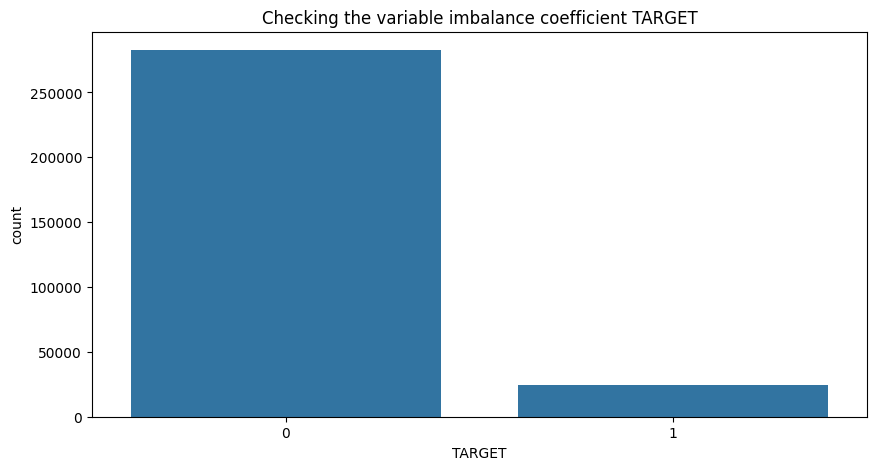

In [547]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['TARGET'], data = df)
plt.title('Checking the variable imbalance coefficient TARGET')
plt.show()

**Observations**

- We have an imbalance in the `TARGET` variable based on % of observations
- `TARGET` value 1 is a customer who is in payment difficulties (more than X days late on at least one of the first Y payments on the loan). This is only 8.07% of the data
- `TARGET` value 0 is all other cases except 1. This is 91.93% of the data

# Data distribution based on `TARGET`

### Create a new data frame with `TARGET` value 1
- `TARGET` value 1 represents a customer with payment difficulties (he/she is more than X days late on at least one of the first Y payments on the loan). This is only 8.07% of the data

In [285]:
df1 = df[df['TARGET'] == 1]

In [286]:
df1.TARGET.value_counts()

,count
TARGET,
1,24825


### Create a new data frame with `TARGET` value 0
- `TARGET` value 0 represents all cases other than 1. This is 91.93% of the data

In [287]:
df0 = df[df['TARGET'] == 0]

In [288]:
df0.TARGET.value_counts()

,count
TARGET,
0,282686


# Univariate analysis of categorical variables

### Analysis of the `NAME_CONTRACT_TYPE` column

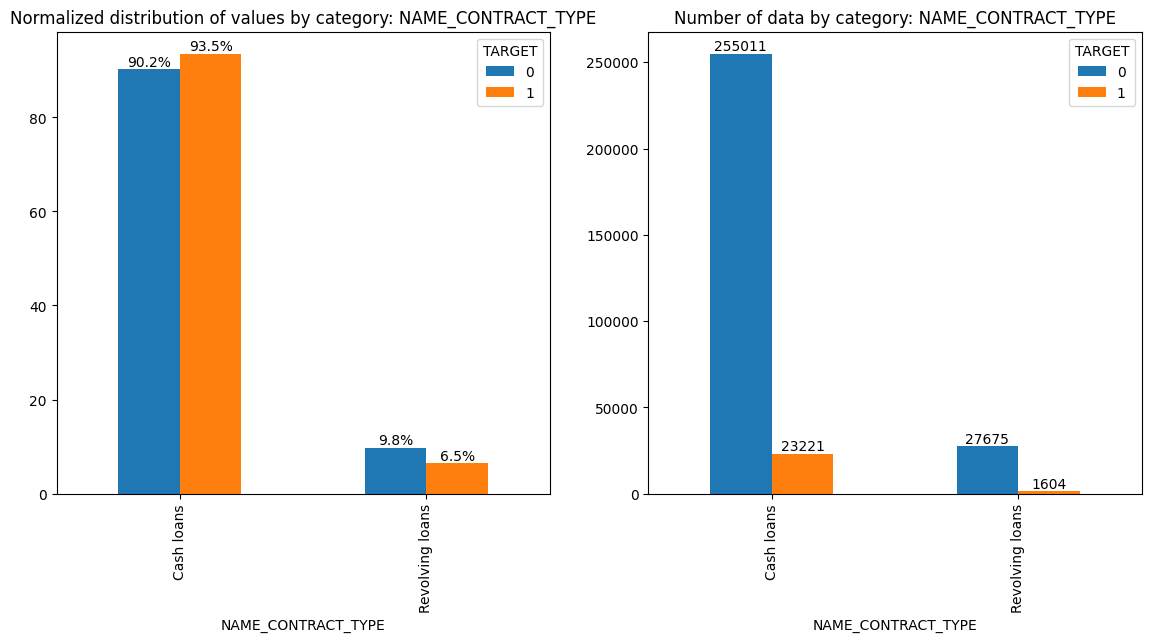

In [548]:
uni_cat_target_compare(df, 'NAME_CONTRACT_TYPE')

**Observation**

- Looking at the histograms, we do not see any significant differences in `NAME_CONTRACT_TYPE` between customers who have difficulty paying and customers who pay on time

**Conclusion**

- The `NAME_CONTRACT_TYPE` column does not provide any compelling evidence in favor of customers who have difficulty paying OR pay on time

### Analysis of `CODE_GENDER`

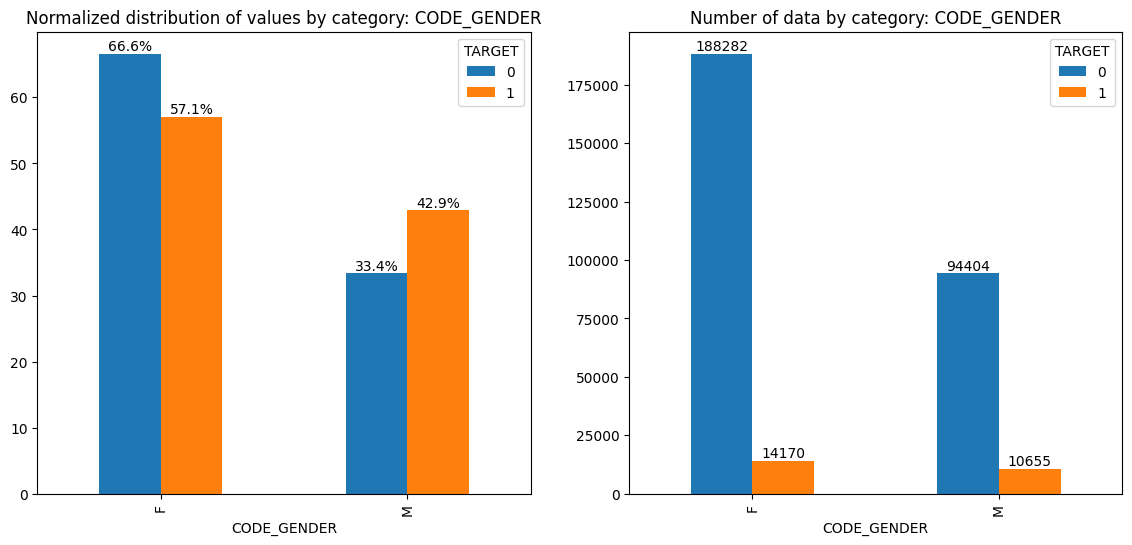

In [549]:
uni_cat_target_compare(df, 'CODE_GENDER')

**Observation**

- If we look at the normalized histogram, we see that the `M` value decreased by 9.5% from `CODE_GENDER` excluding customers who have difficulty paying to customers who pay their bills on time. This is a weak correlation that males have more difficulty paying.

**Conclusion**
- The `CODE_GENDER` column gives a weak inference that male customers have more difficulty paying

### Analysis of `FLAG_OWN_CAR`

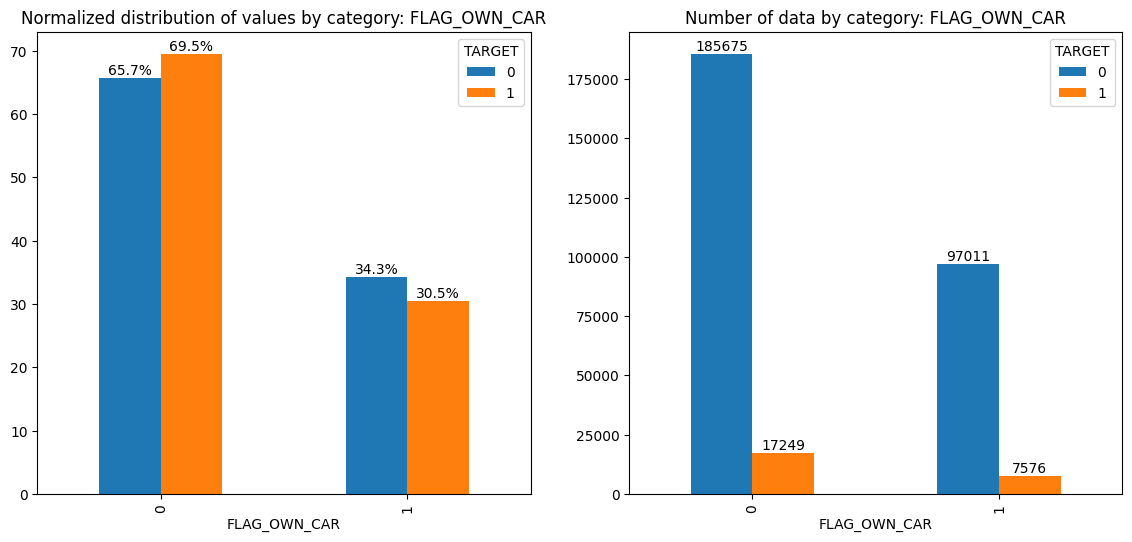

In [550]:
uni_cat_target_compare(df, 'FLAG_OWN_CAR')

**Observation**

- Looking at the histograms, we do not see any significant differences in `FLAG_OWN_CAR` between customers who have difficulty paying and customers who pay on time.

**Conclusion**
- The `FLAG_OWN_CAR` column does not provide strong evidence in favor of customers who have difficulty paying OR pay on time

### Analysis of `NAME_INCOME_TYP

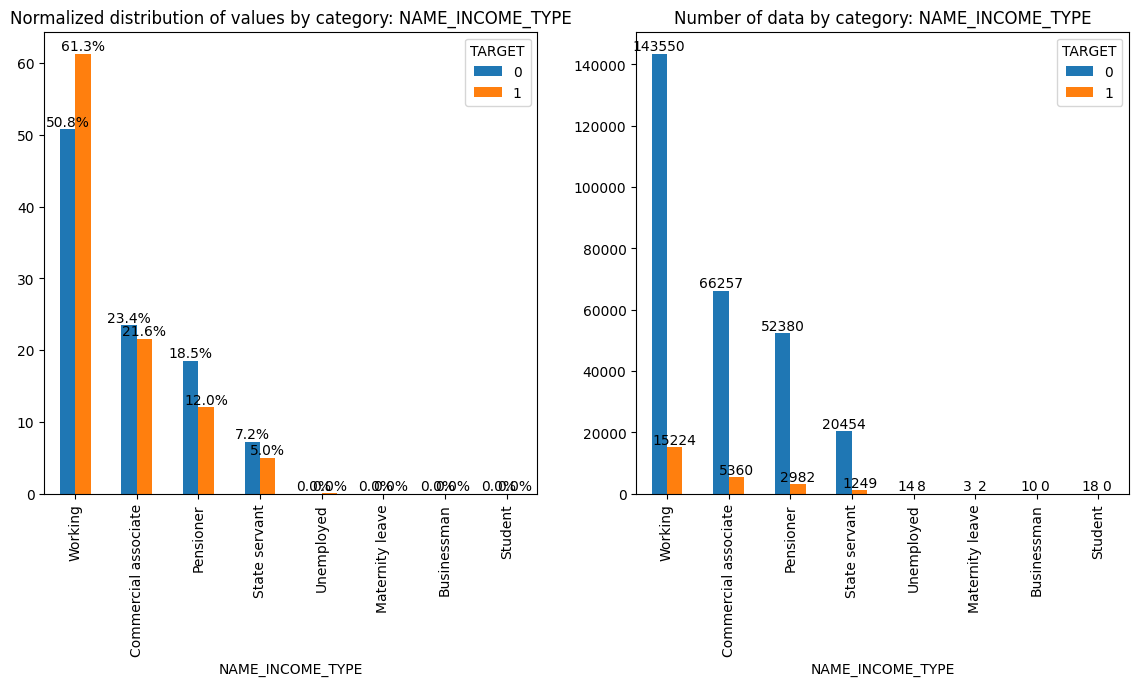

In [551]:
uni_cat_target_compare(df, 'NAME_INCOME_TYPE')

**Observations**

- Pensioners are more likely to pay on time
- Students have no difficulty paying
- Business people have no difficulty paying

**Conclusion**

- Pensioners are more likely to pay on time. This is a weak relationship.
- Students have no difficulty paying. In this case, students have only 18 observations, and this should be considered a weak correlation.
- Business people have no difficulty paying. In this case, business people have only 10 observations, and this should be considered a weak correlation

### Analysis of `NAME_EDUCATION_TYPE`

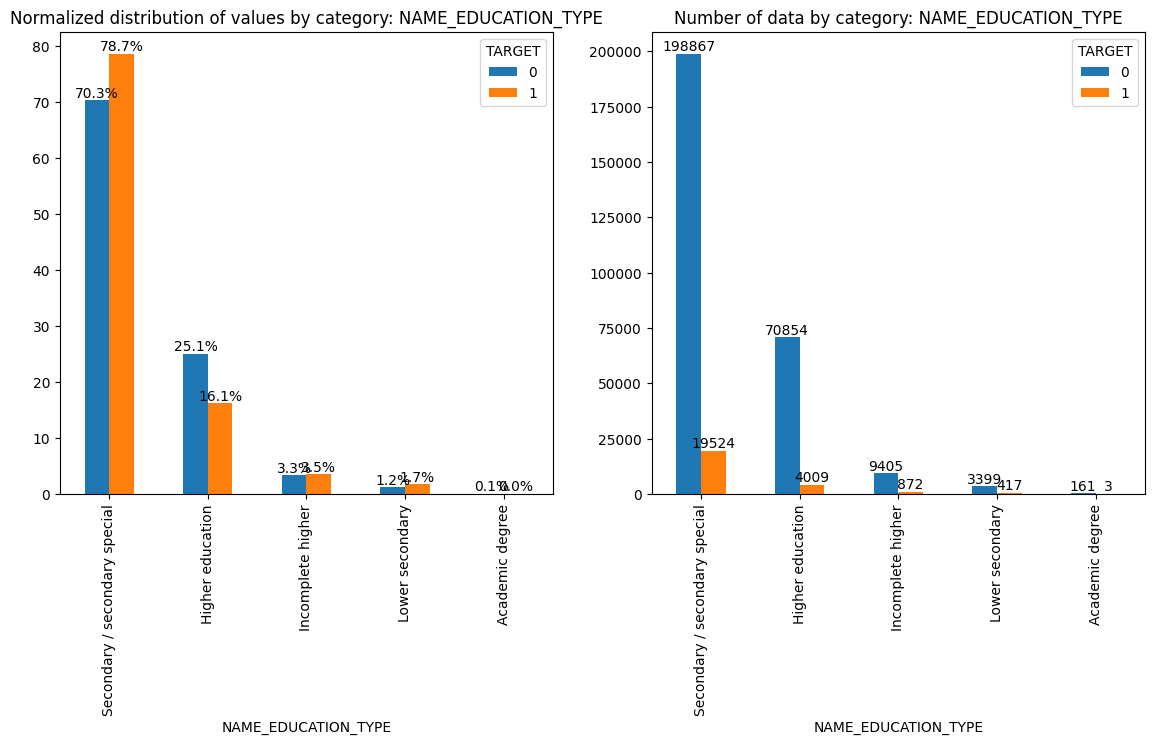

In [552]:
uni_cat_target_compare(df, 'NAME_EDUCATION_TYPE')

**Observations**

- Customers with `Higher education` are more likely to pay on time
- The remaining categories do not give convincing results

**Conclusion**

- Customers with `Higher education` have fewer difficulties with payment. However, this correlation is weak.

### Analysis of `NAME_FAMILY_STATUS`

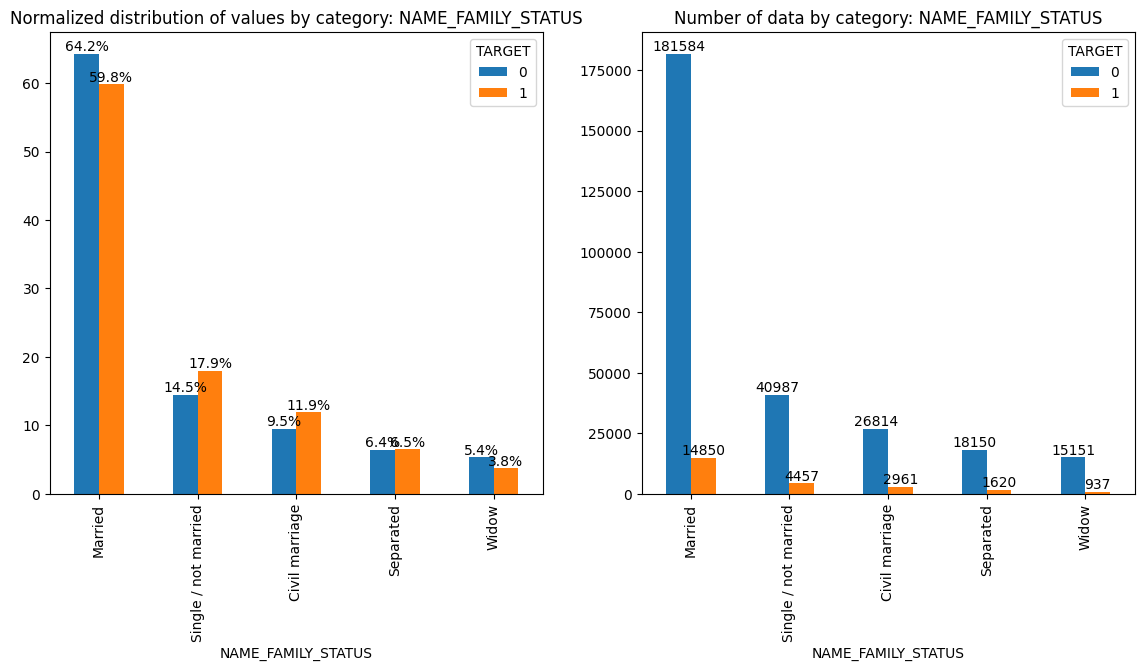

In [553]:
uni_cat_target_compare(df, 'NAME_FAMILY_STATUS')

**Observations**

- Among married customers, 59.8% have difficulty paying and 64.2% pay on time
- Customers who belong to the `Widow` category have 3.8% difficulty paying and 5.4% timely payments
- Among customers who belong to the `Single \ not married` category, 18.0% have difficulty paying and 14.5% timely payments.
- The remaining categories do not give convincing results

**Conclusion**

- Customers who are `Married` or `Widow` are comparatively better at making timely payments. However, the correlation between these indicators is weak.
- Customers who are `Single \ not married` have comparatively more difficulty paying on time. However, this correlation is weak.

# Correlation analysis of numerical variables

### Construction of a correlation matrix for cases with payment difficulties

In [296]:
df1.select_dtypes(include='number').shape

(24825, 68)

There are 67 numeric columns. Let's create a correlation matrix `corr` to better view the results

In [297]:
corr_df1 = df1.select_dtypes(include='number').corr()

In [298]:
corr_df1.head()

,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CODE_GENDER_CHANGED,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,NaN,1.00,0.02,0.07,0.02,0.10,0.14,0.10,0.03,-0.07,-0.11,-0.07,0.02,NaN,0.11,-0.02,0.00,-0.00,0.03,0.11,-0.01,-0.01,0.01,-0.00,0.02,0.02,-0.01,0.04,0.06,0.04,-0.01,0.01,-0.01,0.01,-0.01,0.05,0.01,-0.07,NaN,-0.01,-0.07,0.00,0.20,-0.00,NaN,-0.02,NaN,0.05,0.00,0.02,0.01,0.00,-0.00,-0.01,0.00,0.01,0.00,-0.01,0.00,0.03,-0.01,-0.01,NaN,-0.07,-0.11,-0.07,0.02,0.05
FLAG_OWN_REALTY,NaN,0.02,1.00,0.02,0.01,-0.01,0.00,-0.02,0.03,0.11,0.06,0.01,-0.02,NaN,-0.06,-0.14,-0.01,-0.05,0.03,0.03,-0.01,-0.01,-0.12,-0.05,-0.04,-0.02,-0.07,-0.07,-0.03,-0.00,0.02,0.04,0.01,0.04,0.00,-0.03,0.00,-0.05,NaN,-0.01,0.04,-0.01,-0.01,0.00,NaN,-0.02,NaN,-0.02,-0.03,-0.02,-0.05,-0.00,-0.07,-0.02,-0.01,-0.01,0.00,-0.00,0.02,-0.00,0.02,0.06,NaN,0.11,0.06,0.01,-0.02,-0.03
CNT_CHILDREN,NaN,0.07,0.02,1.00,0.00,-0.00,0.03,-0.01,-0.03,-0.26,-0.19,-0.15,0.03,NaN,0.19,0.05,0.00,-0.02,0.01,0.89,0.04,0.04,-0.02,-0.02,-0.02,-0.01,-0.00,0.05,0.05,-0.01,-0.02,0.03,0.00,0.03,-0.01,-0.01,-0.01,0.06,NaN,-0.02,-0.13,-0.00,0.03,0.00,NaN,-0.01,NaN,0.00,-0.00,0.00,-0.00,-0.01,0.00,-0.00,-0.00,0.00,-0.00,-0.01,-0.01,-0.01,-0.02,-0.04,NaN,-0.26,-0.19,-0.15,0.03,-0.01
AMT_INCOME_TOTAL,NaN,0.02,0.01,0.00,1.00,0.04,0.05,0.04,0.01,-0.00,-0.01,-0.00,0.00,NaN,0.01,-0.01,-0.00,-0.00,0.01,0.01,-0.02,-0.02,0.01,0.01,0.01,0.01,-0.00,-0.00,-0.00,0.01,-0.02,-0.00,-0.01,-0.00,-0.00,0.00,0.00,0.00,NaN,-0.00,-0.01,-0.00,0.02,0.00,NaN,-0.00,NaN,0.01,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,NaN,-0.00,-0.01,0.00,0.00,0.00


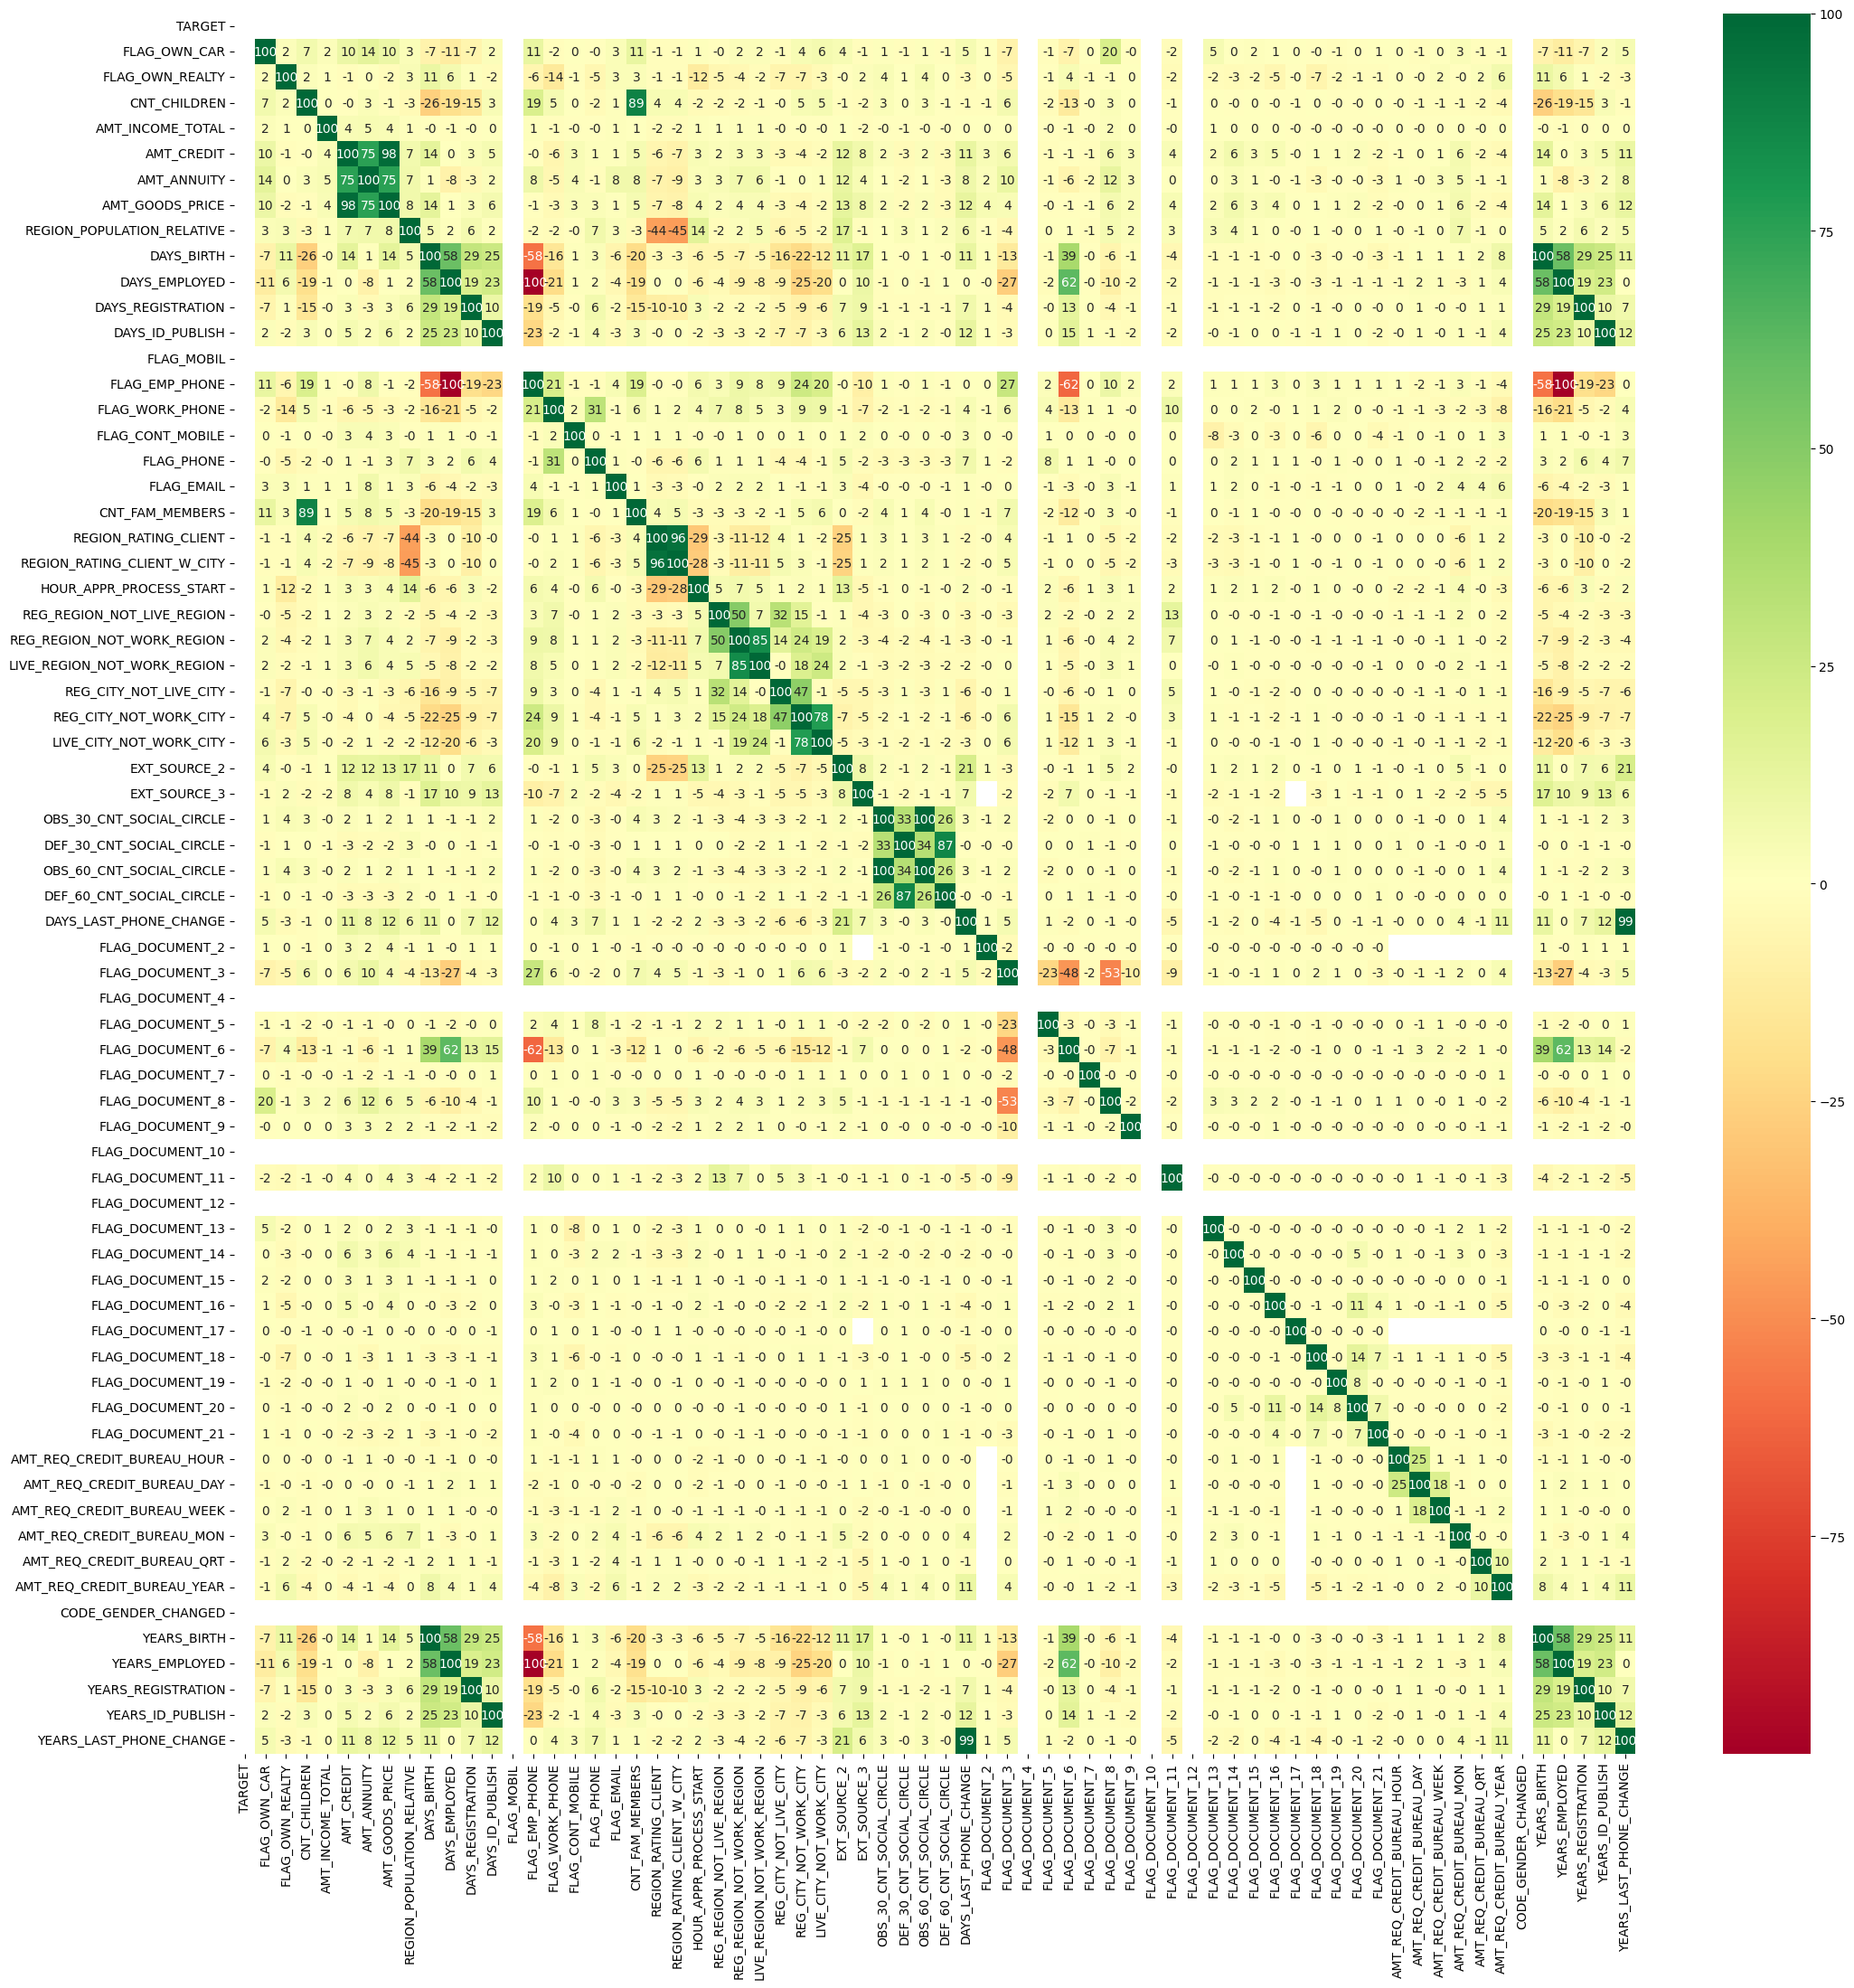

In [299]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df1*100, annot = True, cmap = "RdYlGn", cbar = True, fmt='.0f')
plt.show()

Let's create a heat map to view correlations above 80% and 99.99%

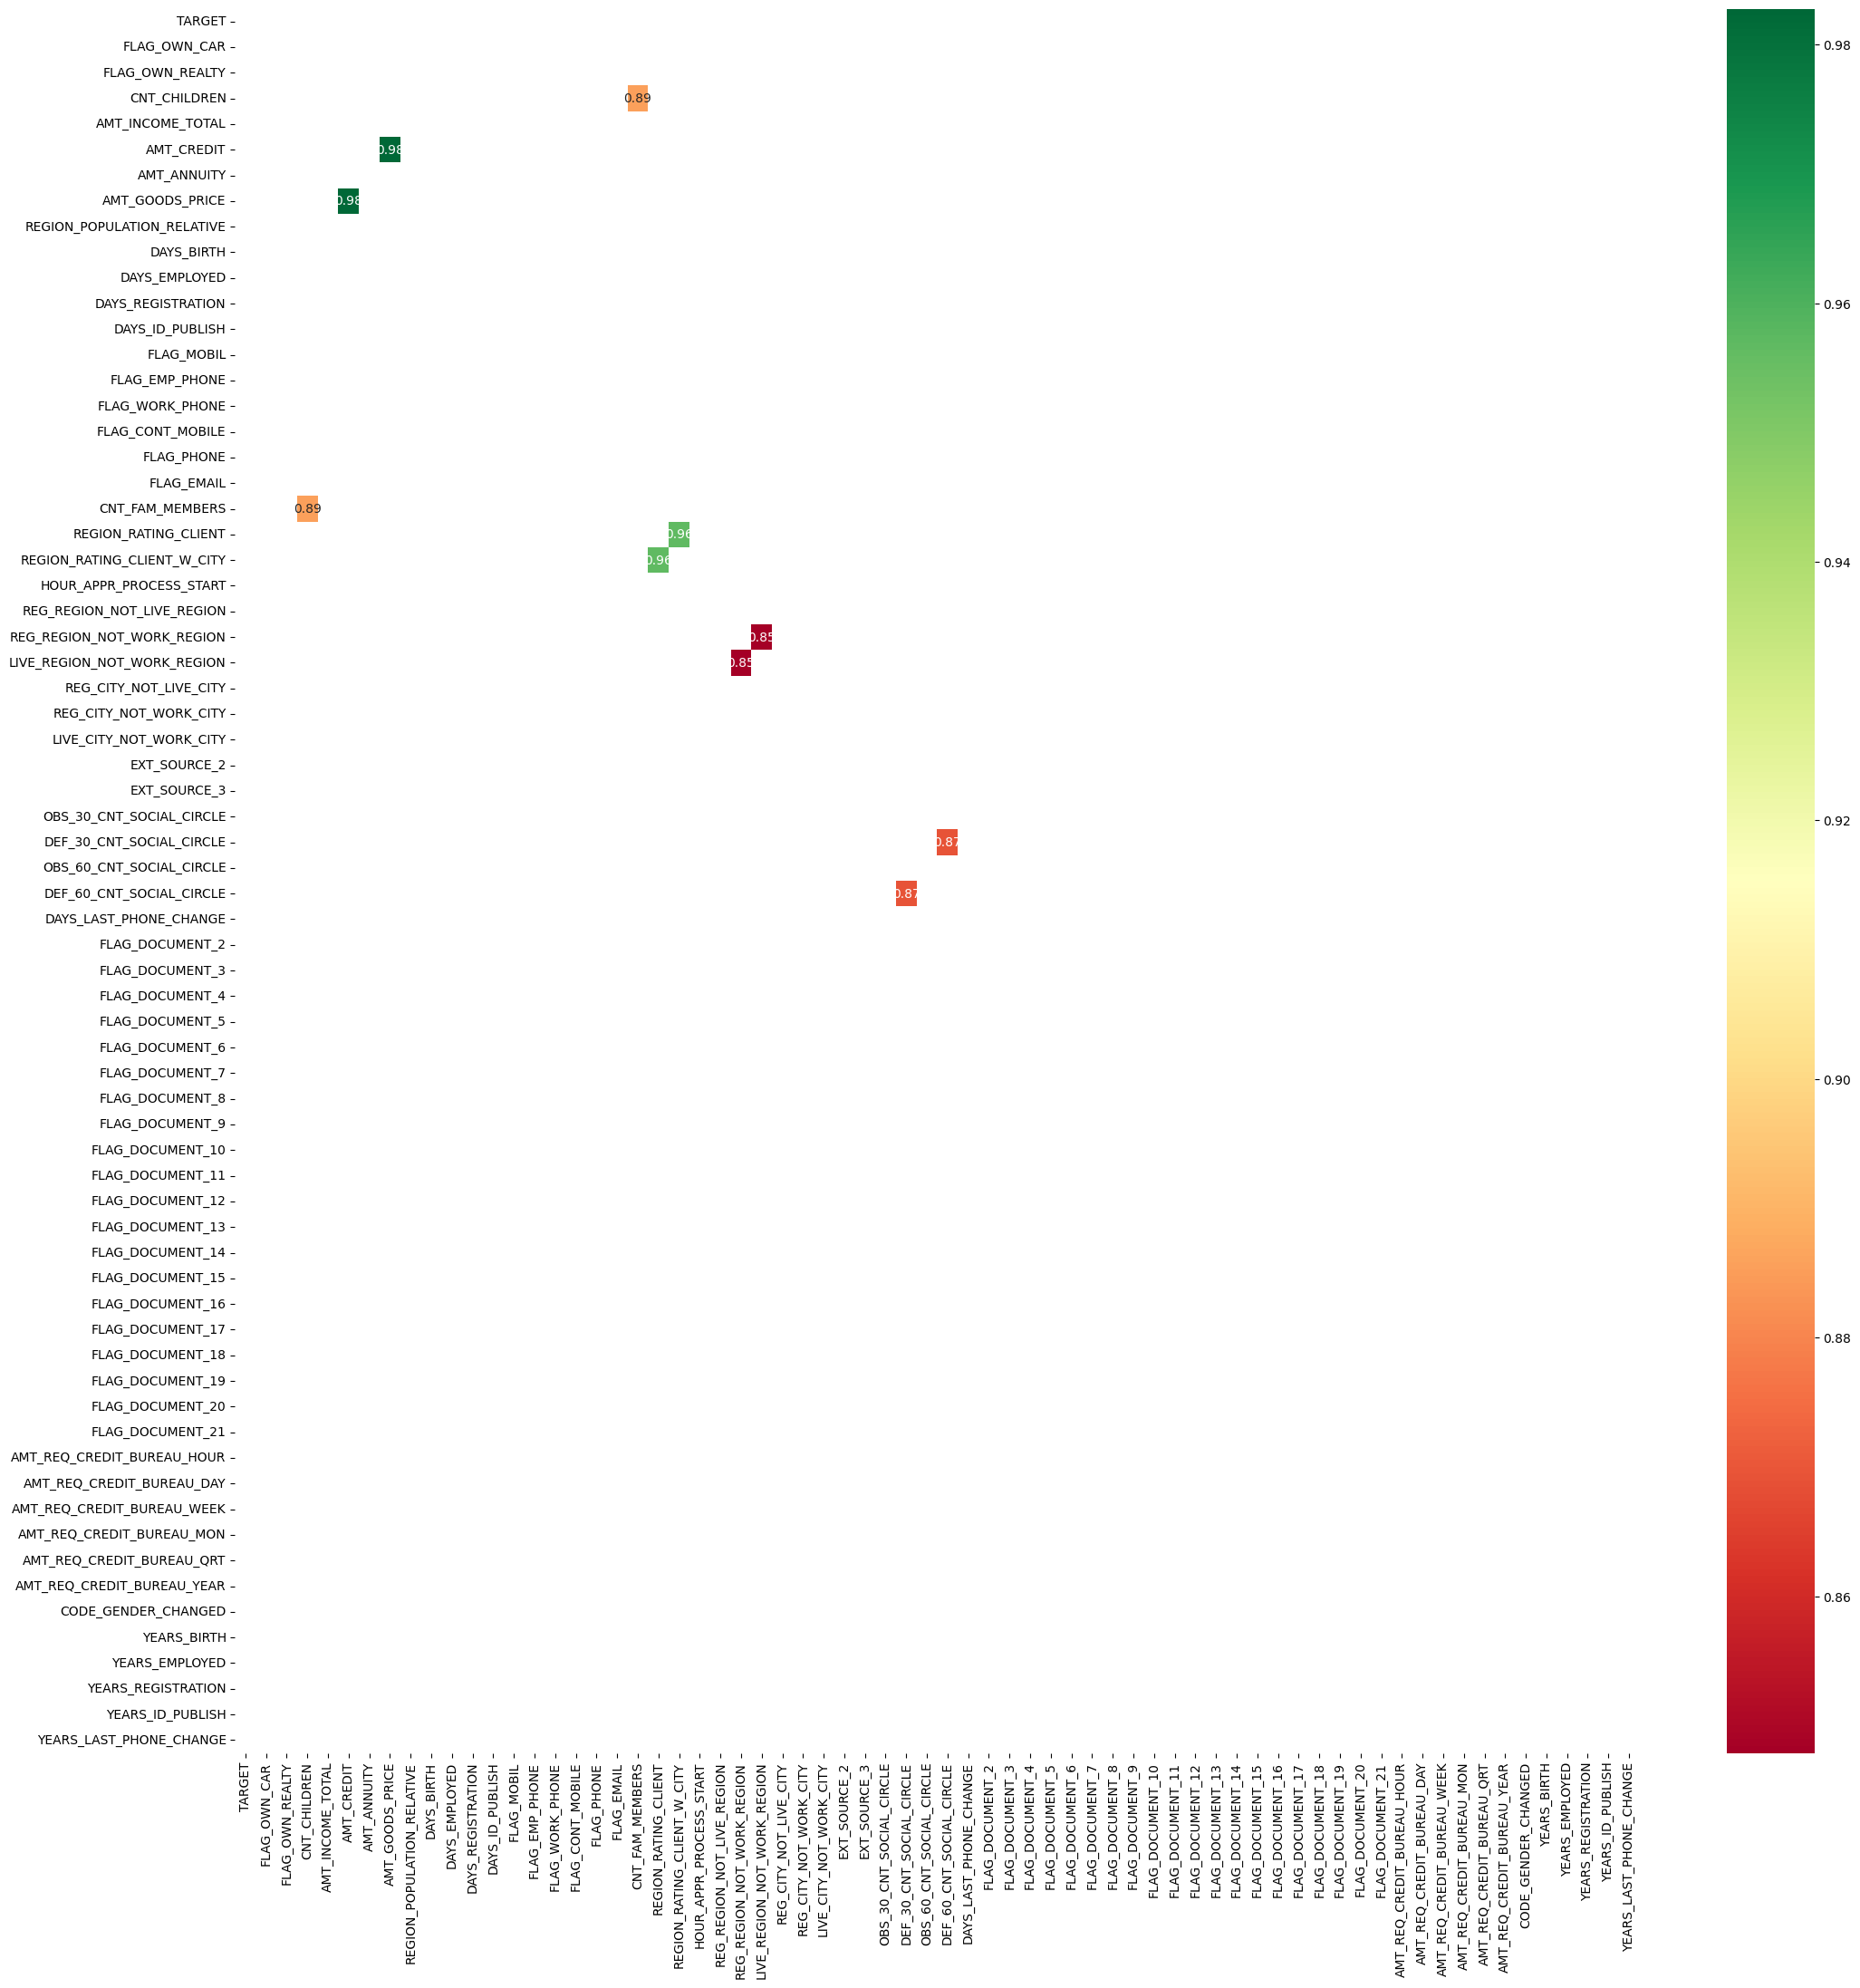

In [300]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df1[(corr_df1 >= 0.8) & (corr_df1 < 0.99)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

### Let's look at the top 10 correlations for payment difficulties cases

In [301]:
corr_df1[corr_df1 <= 0.99].unstack().sort_values(ascending = False).head(22)

,,0
AMT_CREDIT,AMT_GOODS_PRICE,0.98
AMT_GOODS_PRICE,AMT_CREDIT,0.98
REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.96
REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.96
CNT_FAM_MEMBERS,CNT_CHILDREN,0.89
CNT_CHILDREN,CNT_FAM_MEMBERS,0.89
DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.87
DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.87
REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,0.85
LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.85


Since we have repeating combinations, looking at the table above and removing duplicates, we get the top 10 correlations as shown below:

- AMT_GOODS_PRICE -              AMT_CREDIT                    0.98
- REGION_RATING_CLIENT -         REGION_RATING_CLIENT_W_CITY   0.96
- CNT_FAM_MEMBERS -              CNT_CHILDREN                  0.89
- DEF_60_CNT_SOCIAL_CIRCLE -     DEF_30_CNT_SOCIAL_CIRCLE      0.87
- REG_REGION_NOT_WORK_REGION -   LIVE_REGION_NOT_WORK_REGION   0.85
- LIVE_CITY_NOT_WORK_CITY -      REG_CITY_NOT_WORK_CITY        0.78
- AMT_ANNUITY -                  AMT_GOODS_PRICE               0.75
- AMT_ANNUITY -                  AMT_CREDIT                    0.75
- DAYS_EMPLOYED -                FLAG_DOCUMENT_6               0.62
- DAYS_BIRTH -                   DAYS_EMPLOYED                 0.58

### Construction of a correlation matrix for cases with timely payments

In [302]:
df0.select_dtypes(include='number').shape

(282686, 68)

There are 67 numeric columns. Let's create a correlation matrix `corr` to better view the resultsтатів

In [303]:
corr_df0 = df0.select_dtypes(include='number').corr()

In [304]:
corr_df0.head()

,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CODE_GENDER_CHANGED,YEARS_BIRTH,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,NaN,1.00,-0.01,0.11,0.18,0.12,0.14,0.12,0.04,-0.14,-0.16,-0.09,-0.02,-0.00,0.16,0.01,-0.01,-0.01,0.03,0.15,-0.02,-0.02,0.01,-0.00,0.04,0.05,0.01,0.08,0.09,0.05,-0.02,0.00,-0.01,0.00,-0.01,0.04,-0.00,-0.07,-0.00,-0.01,-0.11,0.00,0.23,-0.01,0.00,0.00,0.00,0.08,0.00,0.05,0.00,-0.00,-0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.02,-0.01,-0.04,0.00,-0.14,-0.16,-0.09,-0.02,0.04
FLAG_OWN_REALTY,NaN,-0.01,1.00,-0.00,0.00,-0.04,-0.01,-0.05,0.01,0.12,0.07,0.03,-0.01,-0.00,-0.07,-0.11,0.01,-0.04,0.03,0.01,0.00,0.00,-0.10,-0.03,-0.03,-0.02,-0.06,-0.06,-0.04,0.00,0.04,0.02,0.01,0.02,0.01,-0.03,0.00,-0.04,0.00,-0.01,0.04,0.00,-0.04,-0.00,0.00,-0.04,-0.00,-0.06,-0.06,-0.04,-0.10,-0.01,-0.09,-0.02,-0.03,0.00,-0.00,-0.01,0.01,-0.00,0.02,0.07,0.00,0.12,0.07,0.03,-0.01,-0.03
CNT_CHILDREN,NaN,0.11,-0.00,1.00,0.03,0.00,0.02,-0.00,-0.02,-0.34,-0.25,-0.19,0.03,0.00,0.24,0.06,-0.00,-0.03,0.02,0.88,0.02,0.02,-0.01,-0.01,0.01,0.02,0.02,0.07,0.07,-0.02,-0.04,0.01,-0.00,0.01,-0.00,0.01,0.00,0.06,-0.00,-0.02,-0.16,-0.00,0.05,-0.00,-0.00,-0.01,0.00,0.00,-0.01,0.00,0.01,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.01,-0.01,-0.04,0.00,-0.34,-0.25,-0.19,0.03,0.01
AMT_INCOME_TOTAL,NaN,0.18,0.00,0.03,1.00,0.34,0.42,0.35,0.17,-0.06,-0.14,-0.06,-0.02,0.00,0.14,-0.03,-0.02,0.00,0.08,0.03,-0.19,-0.20,0.08,0.07,0.14,0.13,0.01,0.02,0.02,0.14,-0.07,-0.03,-0.03,-0.03,-0.03,0.04,-0.00,-0.04,0.00,0.00,-0.10,0.01,0.16,0.04,0.00,0.01,0.01,0.05,0.05,0.02,0.02,0.01,0.01,0.01,0.00,-0.00,0.00,0.01,0.01,0.06,0.01,0.03,0.00,-0.06,-0.14,-0.06,-0.02,0.04


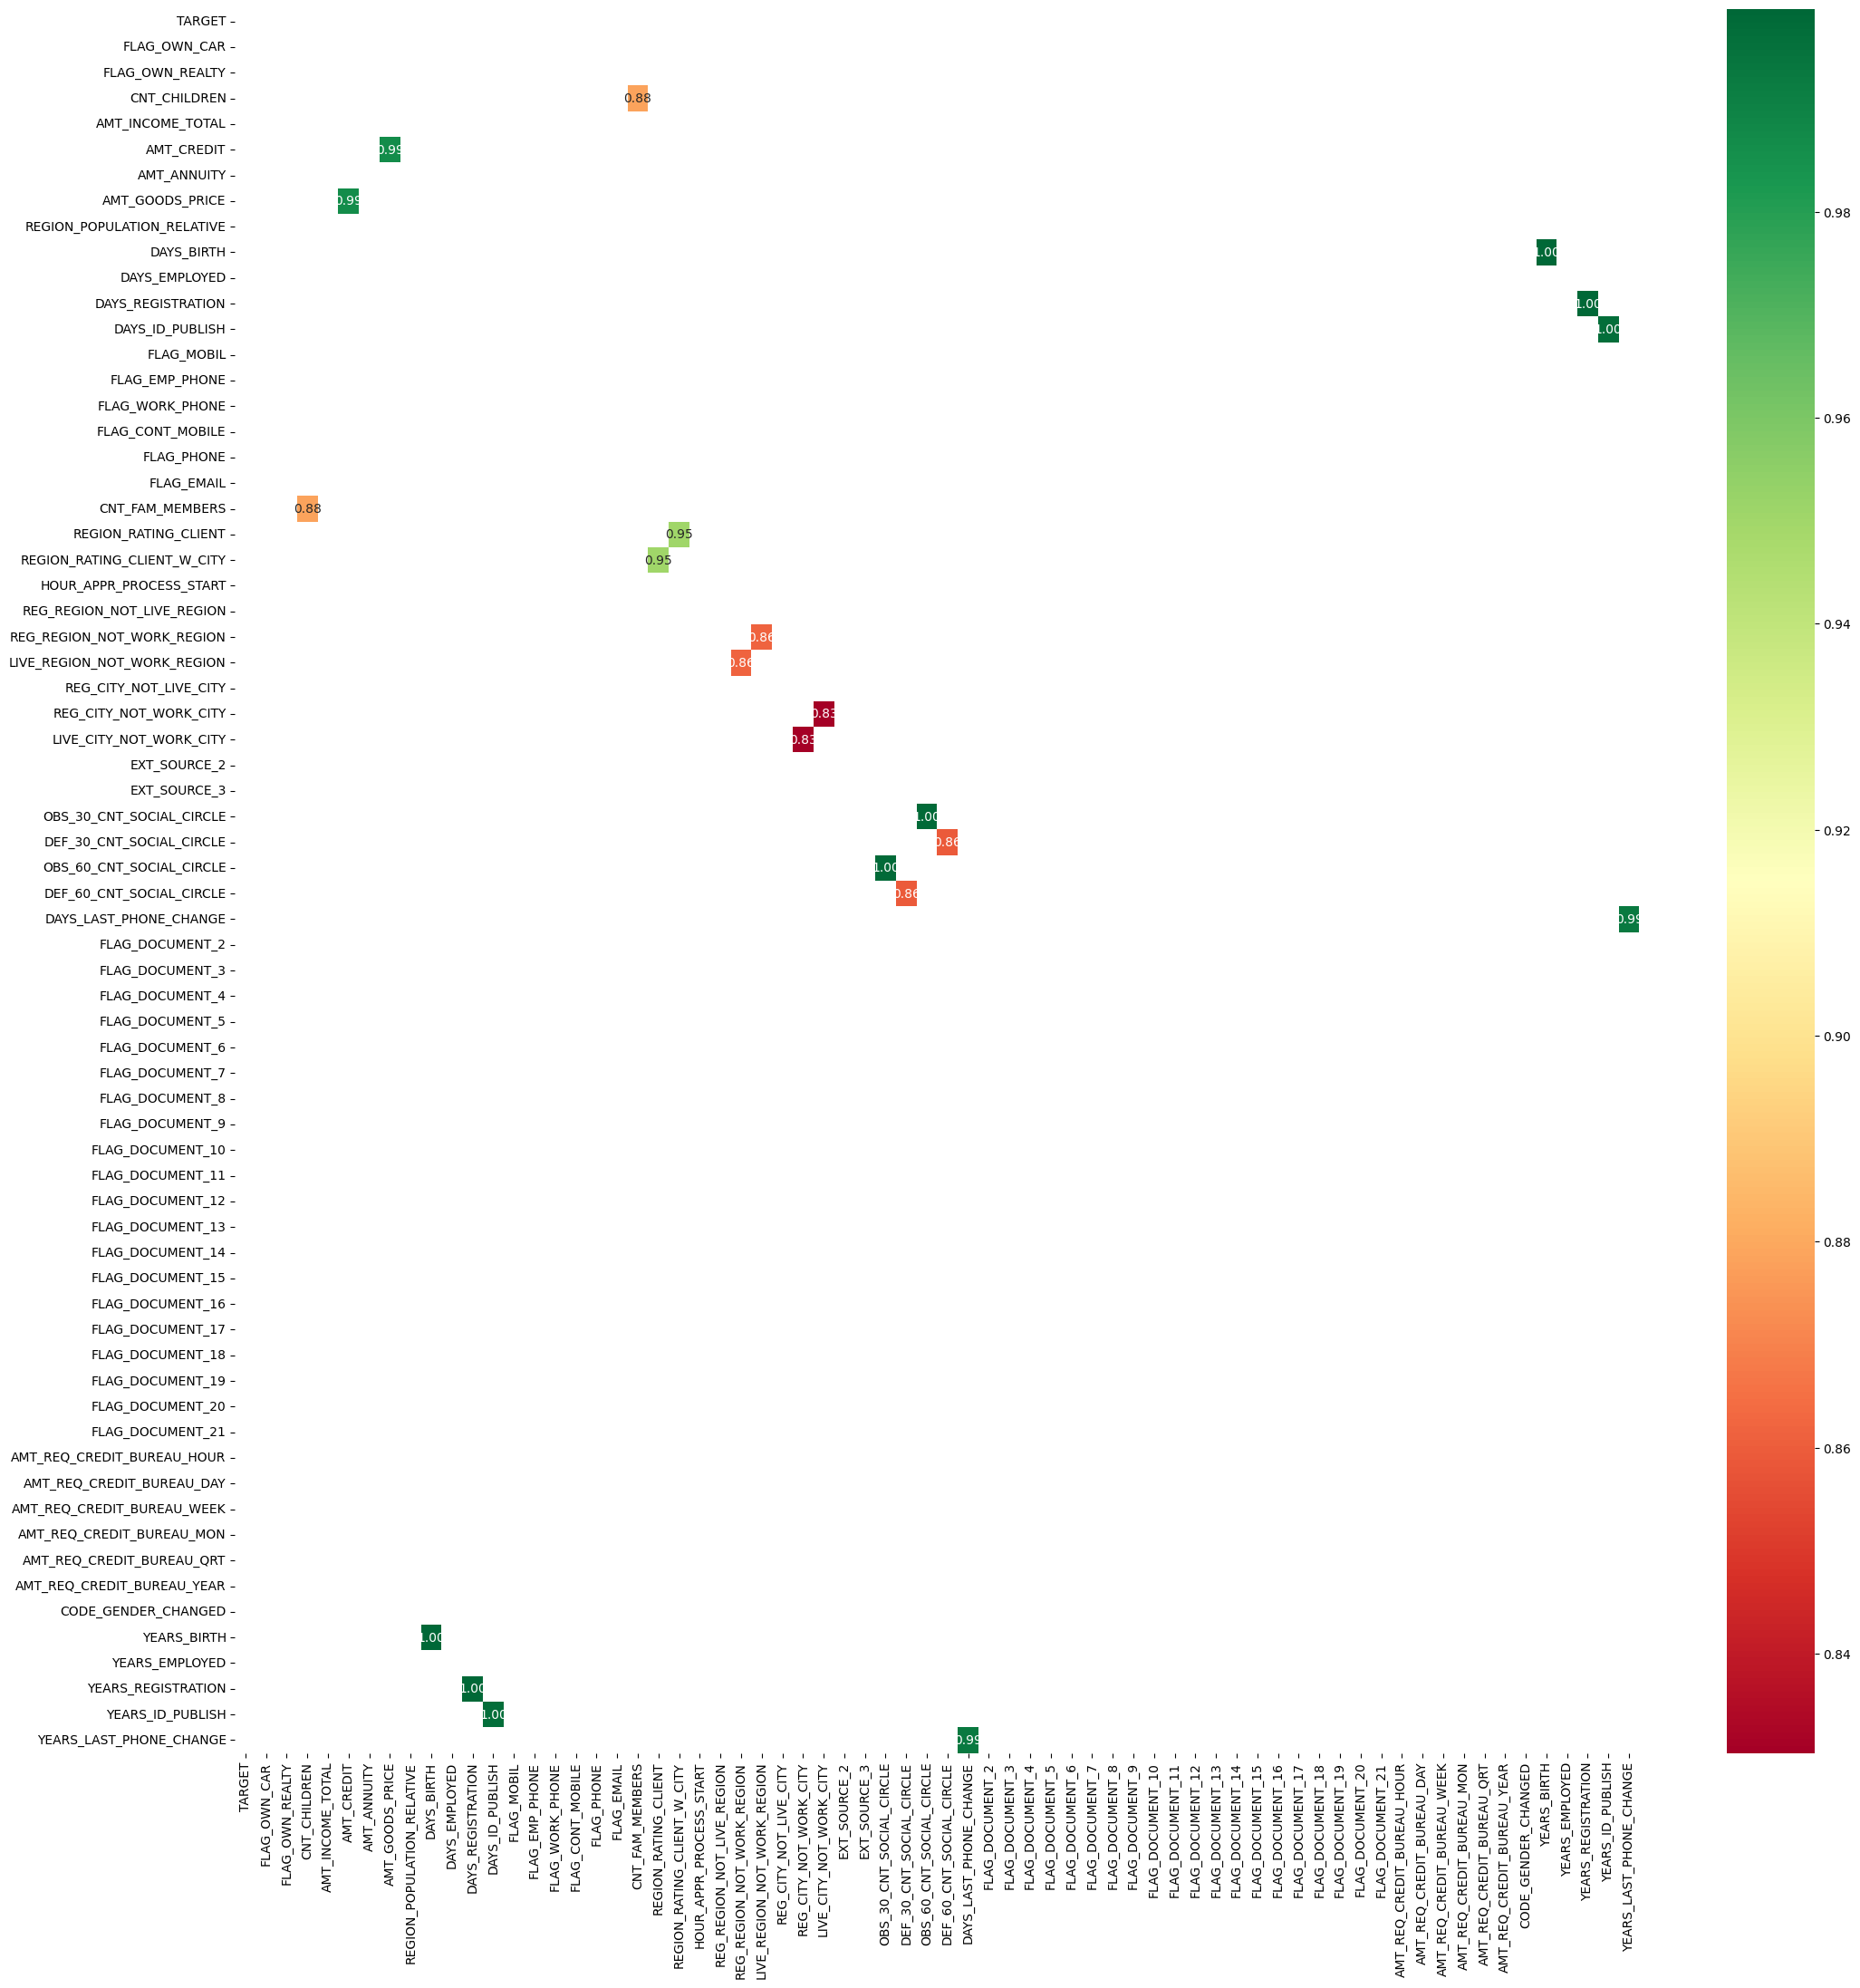

In [305]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_df0[(corr_df0 >= 0.8) & (corr_df0 < 0.9999)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

### Let's look at the top 10 correlations for on-time payments

In [306]:
corr_df0[corr_df0 <= 0.99].unstack().sort_values(ascending = False).head(28)

,,0
AMT_GOODS_PRICE,AMT_CREDIT,0.99
AMT_CREDIT,AMT_GOODS_PRICE,0.99
REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.95
REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.95
CNT_CHILDREN,CNT_FAM_MEMBERS,0.88
CNT_FAM_MEMBERS,CNT_CHILDREN,0.88
REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,0.86
LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.86
DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.86
DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.86


Since we have repeating combinations, looking at the above table and removing duplicates, we get the top 10 correlations as shown below:

- AMT_GOODS_PRICE              AMT_CREDIT                    0.99
- REGION_RATING_CLIENT         REGION_RATING_CLIENT_W_CITY   0.95
- CNT_FAM_MEMBERS              CNT_CHILDREN                  0.88
- REG_REGION_NOT_WORK_REGION   LIVE_REGION_NOT_WORK_REGION   0.86
- DEF_30_CNT_SOCIAL_CIRCLE     DEF_60_CNT_SOCIAL_CIRCLE      0.86
- LIVE_CITY_NOT_WORK_CITY      REG_CITY_NOT_WORK_CITY        0.83
- AMT_ANNUITY                  AMT_GOODS_PRICE               0.78
- AMT_ANNUITY                  AMT_CREDIT                    0.77
- DAYS_BIRTH                   DAYS_EMPLOYED                 0.63
- DAYS_EMPLOYED                FLAG_DOCUMENT_6               0.60

**Observations**

- The top 10 correlations for Payment Difficulty and On-time Payments are the same, except for slight differences in the correlation percentages
- The highest correlation is for the combination of `AMT_GOODS_PRICE` and `AMT_CREDIT`.
- For the Payment Difficulty dataset, the correlation between `AMT_GOODS_PRICE` and `AMT_CREDIT` is 0.98
- For the On-time Payments dataset, the correlation between `AMT_GOODS_PRICE` and `AMT_CREDIT` is 0.99

# Univariate analysis of numerical variables

### Analysis of `AMT_CREDIT`

In [554]:
Q1 = df1['AMT_CREDIT'].quantile(0.25)
Q3 = df1['AMT_CREDIT'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

448915.5


The values ​​*before* (Q1 - 1.5 * IQR) and *after* (Q3 + 1.5 * IQR) are outliers.

In [560]:
Min_value1 = (Q1 - 1.5 * IQR)
Max_value1 = (Q3 + 1.5 * IQR)
print("Minimum value up to which emissions exist: {}".format(Min_value1))
print("Maximum value after which emissions exist: {}".format(Max_value1))

Minimum value up to which emissions exist: -540000.0
Maximum value after which emissions exist: 1620000.0


In [556]:
Q1 = df0['AMT_CREDIT'].quantile(0.25)
Q3 = df0['AMT_CREDIT'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

540000.0


The values ​​*before* (Q1 - 1.5 * IQR) and *after* (Q3 + 1.5 * IQR) are outliers.

In [561]:
Min_value0 = (Q1 - 1.5 * IQR)
Max_value0 = (Q3 + 1.5 * IQR)
print("Minimum value up to which emissions exist: {}".format(Min_value0))
print("Maximum value after which emissions exist: {}".format(Max_value0))

Minimum value up to which emissions exist: -540000.0
Maximum value after which emissions exist: 1620000.0


Removing emissions and constructing a distribution diagram

In [558]:
def kde_no_outliers(df0, df1, Max_value0, Max_value1, column):
  plt.figure(figsize = (14,6))
  sns.kdeplot(df1[df1[column] <= Max_value1][column],label = 'Payment difficulties')
  sns.kdeplot(df0[df0[column] <= Max_value0][column],label = 'On-Time Payments')
  plt.ticklabel_format(style='plain', axis='x')
  plt.xticks(rotation = 45)
  plt.legend()
  plt.show()

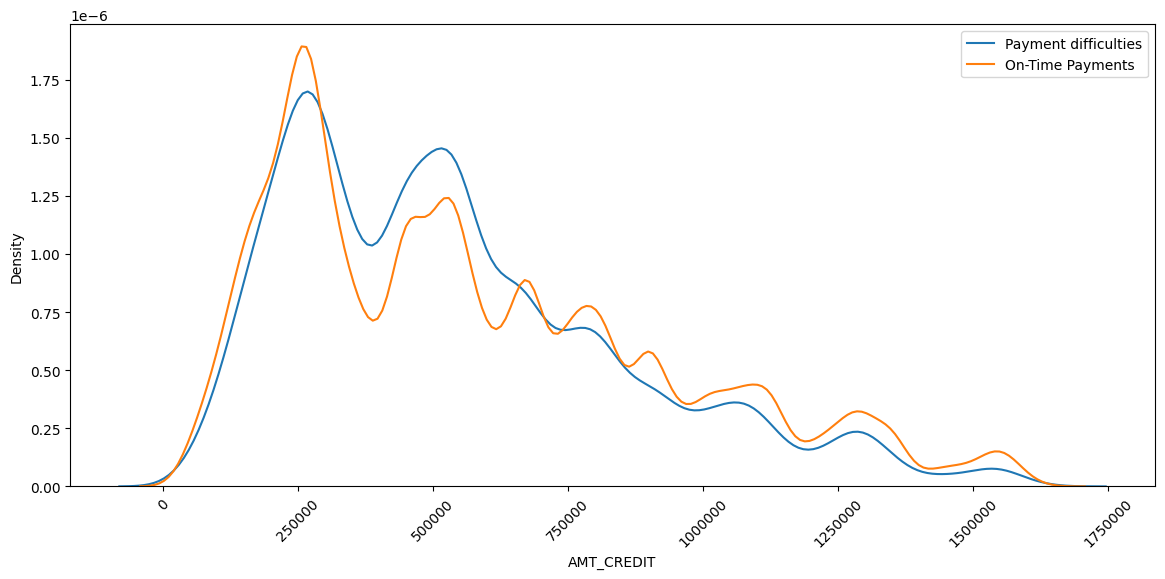

In [562]:
kde_no_outliers(df0, df1, Max_value0, Max_value1, 'AMT_CREDIT')

**Observations**

- For `AMT_CREDIT`, 250,000 to approximately 650,000 more customers are having difficulty paying
- For `AMT_CREDIT` > 750,000 more customers are making payments on time

### Analysis of  `YEARS_BIRTH`

In [ ]:
def calculate_iqr_and_plot(df0, df1, column):
    """
    Calculate the IQR for the column in both dataframes, identify outliers,
    and construct a distribution without outliers.

    Parameters:
    df0 (pd.DataFrame): DataFrame with data on on-time payments.
    df1 (pd.DataFrame): DataFrame with other payment data.
    """

    print("Calculate IQR for df1")
    Q1_df1 = df1[column].quantile(0.25)
    Q3_df1 = df1[column].quantile(0.75)
    IQR_df1 = Q3_df1 - Q1_df1
    print(f"IQR for df1: {IQR_df1}")

    print("\nDetermination of emissions for df1")
    min_value_df1 = Q1_df1 - 1.5 * IQR_df1
    max_value_df1 = Q3_df1 + 1.5 * IQR_df1
    print(f"Min value before which outlier exist in df1: {min_value_df1}")
    print(f"Max value after which outlier exist in df1: {max_value_df1}")

    print("\Calculate IQR for df0")
    Q1_df0 = df0[column].quantile(0.25)
    Q3_df0 = df0[column].quantile(0.75)
    IQR_df0 = Q3_df0 - Q1_df0
    print(f"IQR for df0: {IQR_df0}")

    print("\nDetermination of emissions for df0")
    min_value_df0 = Q1_df0 - 1.5 * IQR_df0
    max_value_df0 = Q3_df0 + 1.5 * IQR_df0
    print(f"Min value before which outlier exist in df0: {min_value_df0}")
    print(f"Max value after which outlier exist in df0: {max_value_df0}")

    print("\nRemoving emissions and constructing a distribution diagram")
    kde_no_outliers(df0, df1, max_value_df0, max_value_df1, column)



Calculate IQR for df1
IQR for df1: 18.0

Determination of emissions for df1
Min value before which outlier exist in df1: 4.0
Max value after which outlier exist in df1: 76.0
\Calculate IQR for df0
IQR for df0: 20.0

Determination of emissions for df0
Min value before which outlier exist in df0: 4.0
Max value after which outlier exist in df0: 84.0

Removing emissions and constructing a distribution diagram


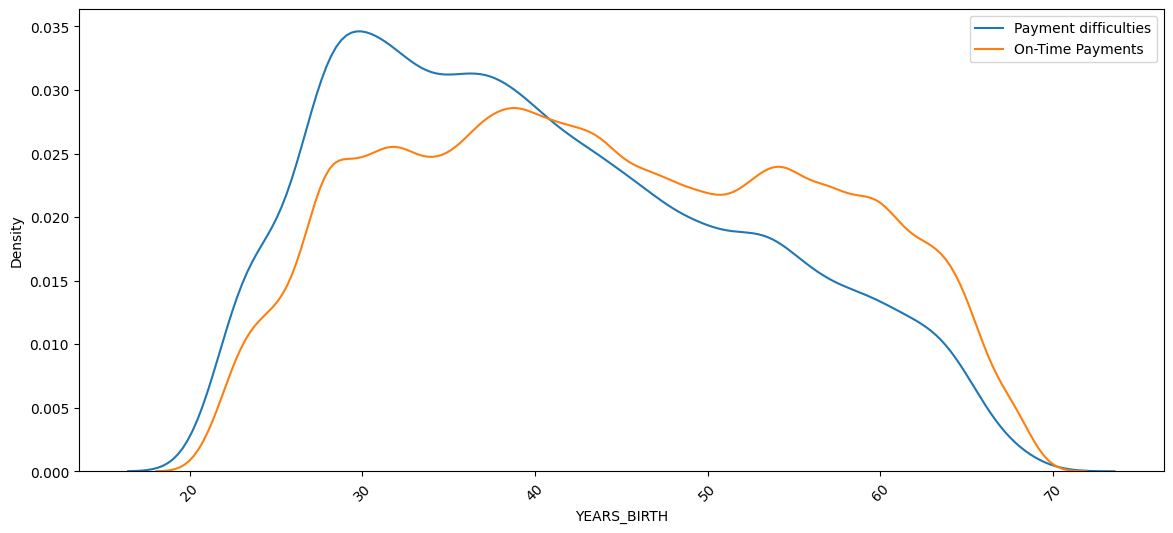

In [565]:
calculate_iqr_and_plot(df0, df1, 'YEARS_BIRTH')

**Observation**

- For `YEARS_BIRTH` from 20 to 40 more customers have difficulty paying
- Conversely, for `YEARS_BIRTH` > 40 more customers with on-time payments

### Analysis of `AMT_GOODS_PRICE `

Calculate IQR for df1
IQR for df1: 436500.0

Determination of emissions for df1
Min value before which outlier exist in df1: -416250.0
Max value after which outlier exist in df1: 1329750.0
\Calculate IQR for df0
IQR for df0: 446502.375

Determination of emissions for df0
Min value before which outlier exist in df0: -431253.5625
Max value after which outlier exist in df0: 1354755.9375

Removing emissions and constructing a distribution diagram


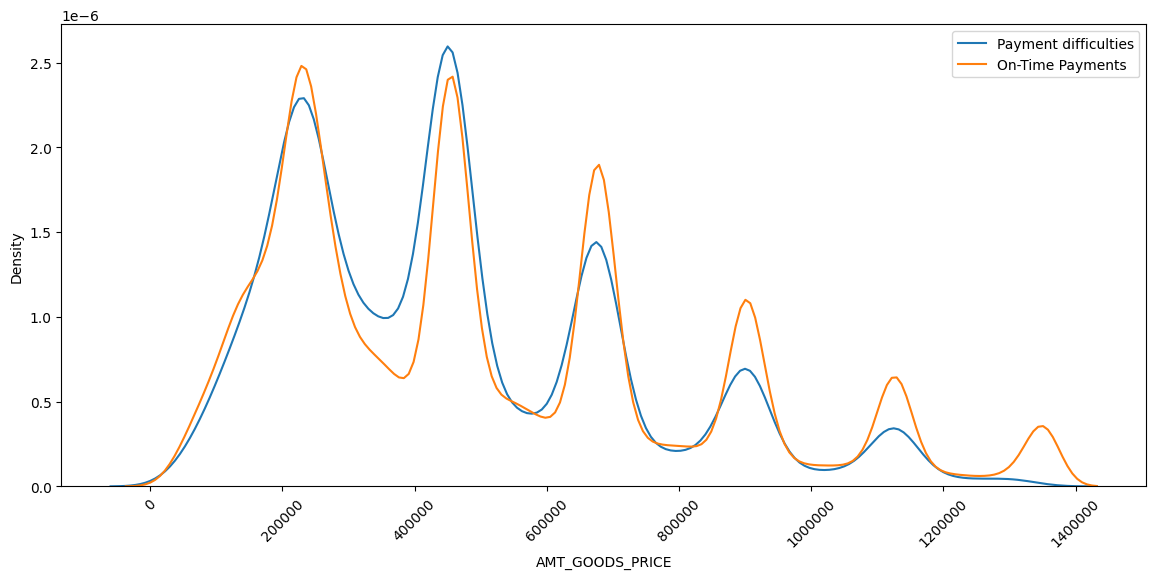

In [567]:
calculate_iqr_and_plot(df0, df1, 'AMT_GOODS_PRICE')

**Observations**

- For `AMT_GOODS_PRICE` between ~250000 and ~550000 more customers have difficulty paying
- In other cases there are spikes but they do not show any convincing observations

### Analysis of `DAYS_EMPLOYED`

Calculate IQR for df1
IQR for df1: 2603.0

Determination of emissions for df1
Min value before which outlier exist in df1: -3227.5
Max value after which outlier exist in df1: 7184.5
\Calculate IQR for df0
IQR for df0: 5107.0

Determination of emissions for df0
Min value before which outlier exist in df0: -6693.5
Max value after which outlier exist in df0: 13734.5

Removing emissions and constructing a distribution diagram


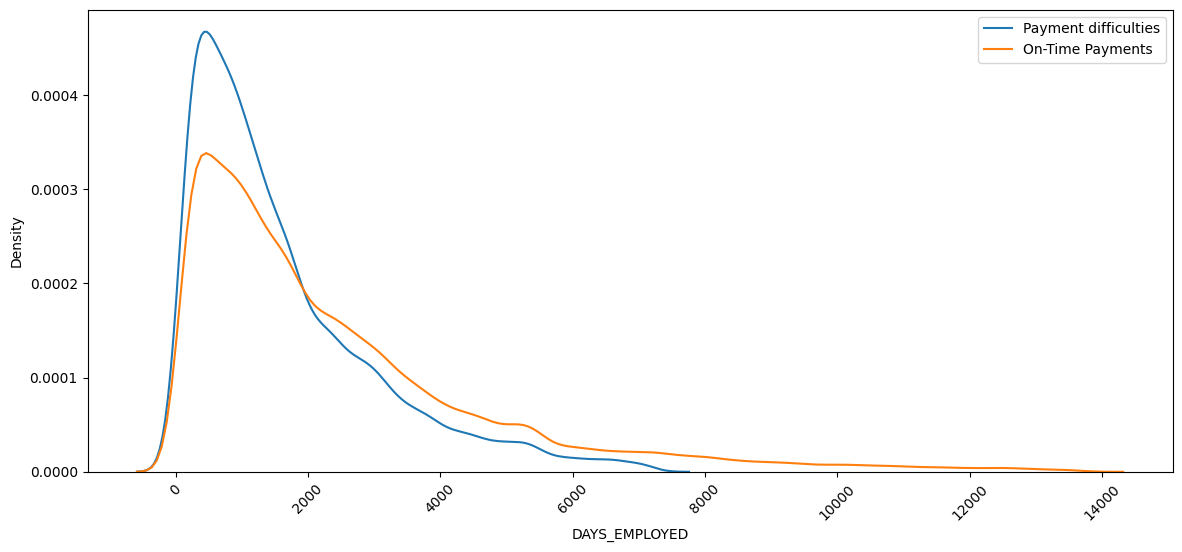

In [568]:
calculate_iqr_and_plot(df0, df1, 'DAYS_EMPLOYED')

**Observation**

- For `DAYS_EMPLOYED` less than 2000, there are more customers who have problems with payment
- Conversely, for `DAYS_EMPLOYED` > 2000, there are more customers with timely payments
- This means that those who work longer have a better chance of repaying the loan

### Analysis of `CNT_CHILDREN `

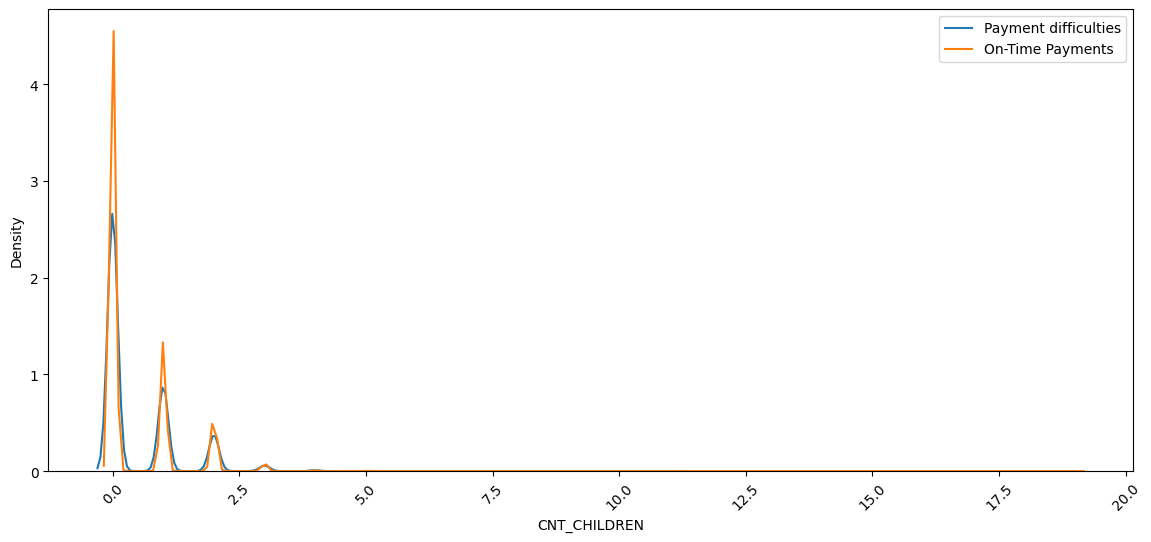

In [569]:
kde_no_outliers(df0, df1, Max_value0, Max_value1, 'CNT_CHILDREN')

**Observation**

- For `CNT_CHILDREN` with 0 (those without children), there are many customers with on-time payments
- For `CNT_CHILDREN` with 1 OR 2 (those with 1 or 2 children), there are slightly more customers with on-time payments

### Analysis of `AMT_INCOME_TOTAL `

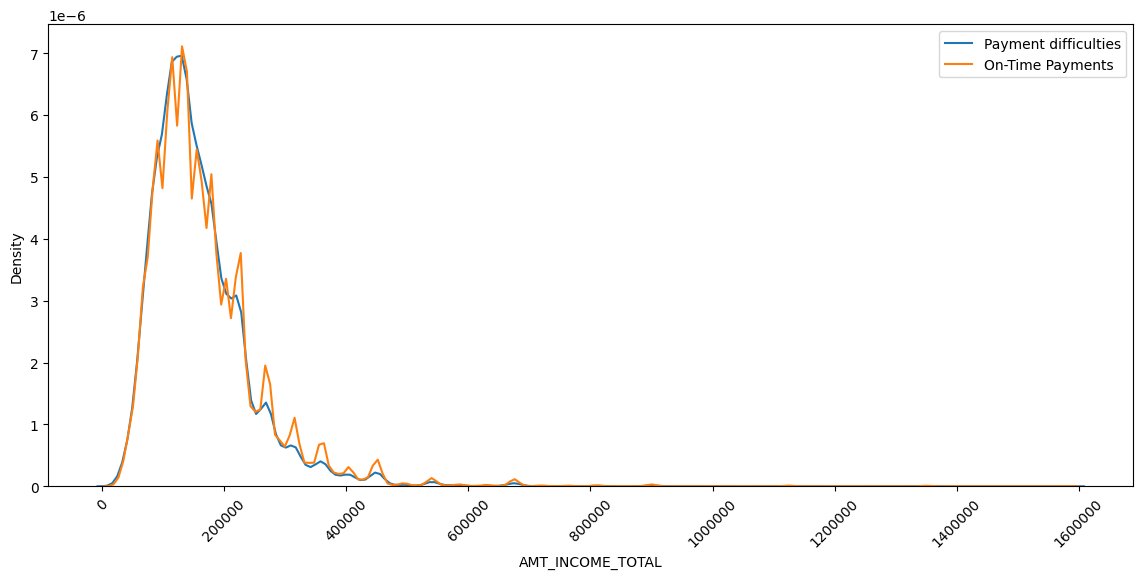

In [570]:
kde_no_outliers(df0, df1, Max_value0, Max_value1, 'AMT_INCOME_TOTAL')

**Observation**

- Based on `AMT_INCOME_TOTAL`, for customers who have difficulty paying, the distribution roughly resembles a normal distribution
- But for customers with on-time payments, there are unstable peaks in the distribution, which does not provide any reliable observations

# Bivariate/Multivariate Analysis

## Continuous vs continuous variables

### Analysis of `AMT_GOODS_PRICE` vs `AMT_CREDIT`

In [339]:
max_value1_AMT_GOODS_PRICE = outlier_range(df1,'AMT_GOODS_PRICE')
max_value1_AMT_GOODS_PRICE

np.float64(1329750.0)

In [340]:
max_value1_AMT_CREDIT = outlier_range(df1,'AMT_CREDIT')
max_value1_AMT_CREDIT

np.float64(1406688.75)

In [341]:
max_value0_AMT_GOODS_PRICE = outlier_range(df0,'AMT_GOODS_PRICE')
max_value0_AMT_GOODS_PRICE

np.float64(1354755.9375)

In [342]:
max_value0_AMT_CREDIT = outlier_range(df0,'AMT_CREDIT')
max_value0_AMT_CREDIT

np.float64(1620000.0)

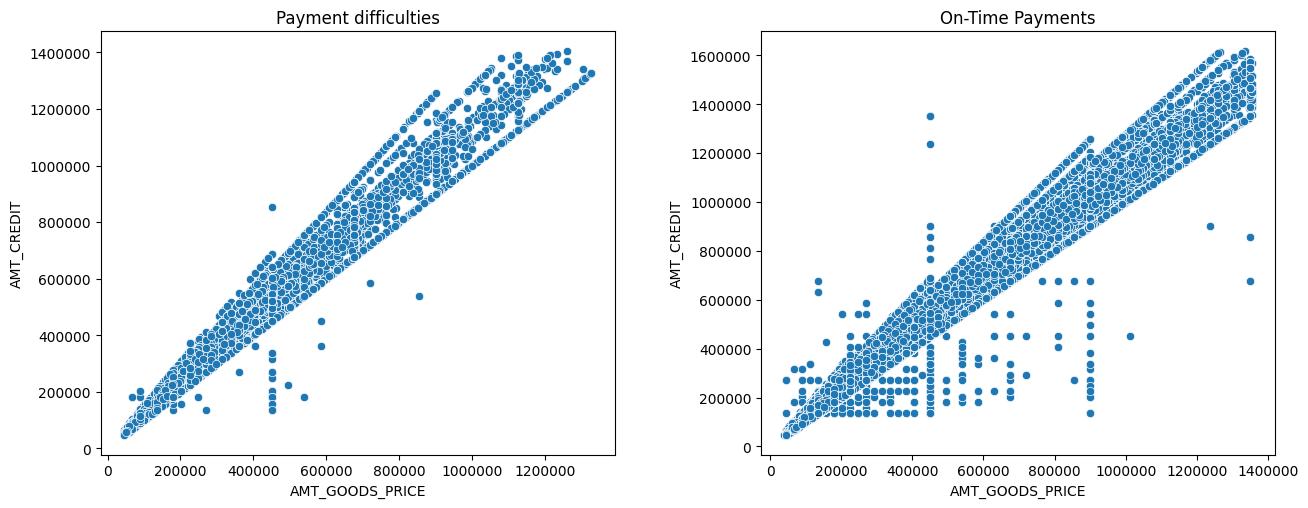

In [574]:
plt.figure(figsize = (14, 6))

plt.subplot(1,2,1)
plt.title('Payment difficulties')
sns.scatterplot(x = df1[df1['AMT_GOODS_PRICE'] < max_value1_AMT_GOODS_PRICE].AMT_GOODS_PRICE,
                y = df1[df1['AMT_CREDIT'] < max_value1_AMT_CREDIT].AMT_CREDIT, data = df1)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.subplot(1,2,2)
plt.title('On-Time Payments')
sns.scatterplot(x = df0[df0['AMT_GOODS_PRICE'] < max_value0_AMT_GOODS_PRICE].AMT_GOODS_PRICE,
                y = df0[df0['AMT_CREDIT'] < max_value0_AMT_CREDIT].AMT_CREDIT, data = df0)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout(pad = 4)
plt.show()

**Observation**
- AMT_GOODS_PRICE and AMT_CREDIT have a strong positive correlation. This means that as the price of the good increases, the amount of credit also increases

### Analysis of `AMT_ANNUITY` vs `AMT_CREDIT`

In [576]:
def bi_numerical_analysis(df0, df1, column_1, column_2):
  def build_scatter(df):
    sns.scatterplot(x = df[df[column_1] < max_value1_column_1][column_1],
                    y = df[df[column_2] < max_value1_column_2][column_2], data = df)
    plt.ticklabel_format(style='plain', axis='x')
    plt.ticklabel_format(style='plain', axis='y')

  max_value1_column_1 = outlier_range(df1, column_1)
  max_value1_column_1

  max_value1_column_2 = outlier_range(df1, column_2)
  max_value1_column_2

  max_value0_column_1 = outlier_range(df0, column_1)
  max_value0_column_1

  max_value0_column_2 = outlier_range(df0, column_2)
  max_value0_column_2

  print("Constructing a scatter diagram for comparison with removed emissions")

  plt.figure(figsize = (20,8))

  plt.subplot(1,2,1)
  plt.title('Payment difficulties')
  build_scatter(df1)

  plt.subplot(1,2,2)
  plt.title('On-Time Payments')
  build_scatter(df0)

  plt.tight_layout(pad = 4)
  plt.show()


Constructing a scatter diagram for comparison with removed emissions


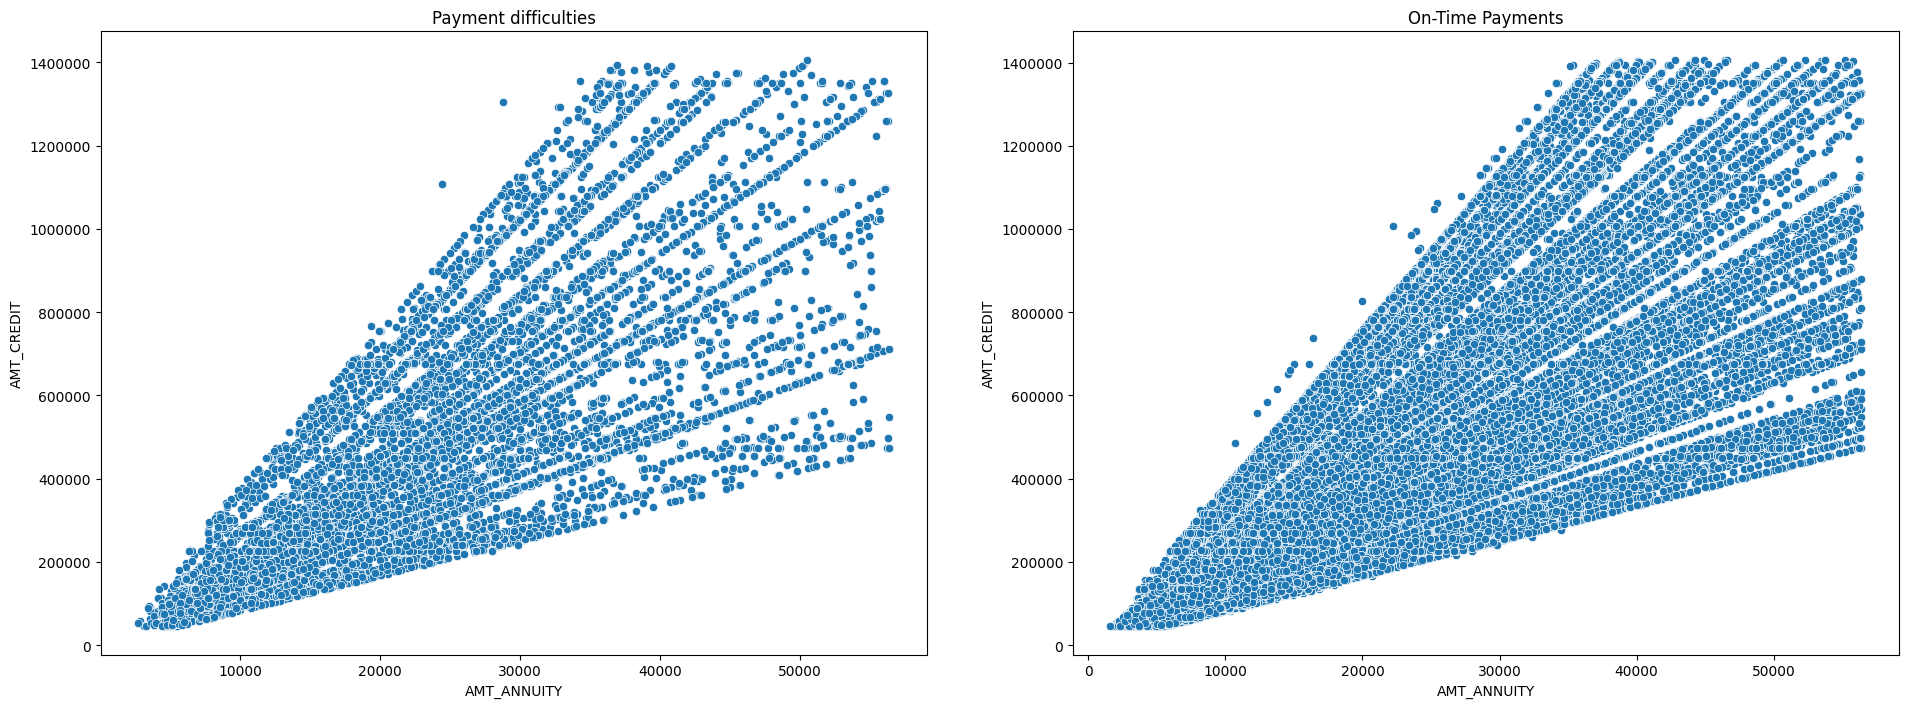

In [577]:
bi_numerical_analysis(df0, df1, column_1='AMT_ANNUITY', column_2='AMT_CREDIT')

**Observation**
- AMT_ANNUITY and AMT_CREDIT have a strong positive correlation. This means that as the Annuity Amount increases, the loan amount also increases.

### Analysis of `DAYS_EMPLOYED` vs `AMT_INCOME_TOTAL`

Constructing a scatter diagram for comparison with removed emissions


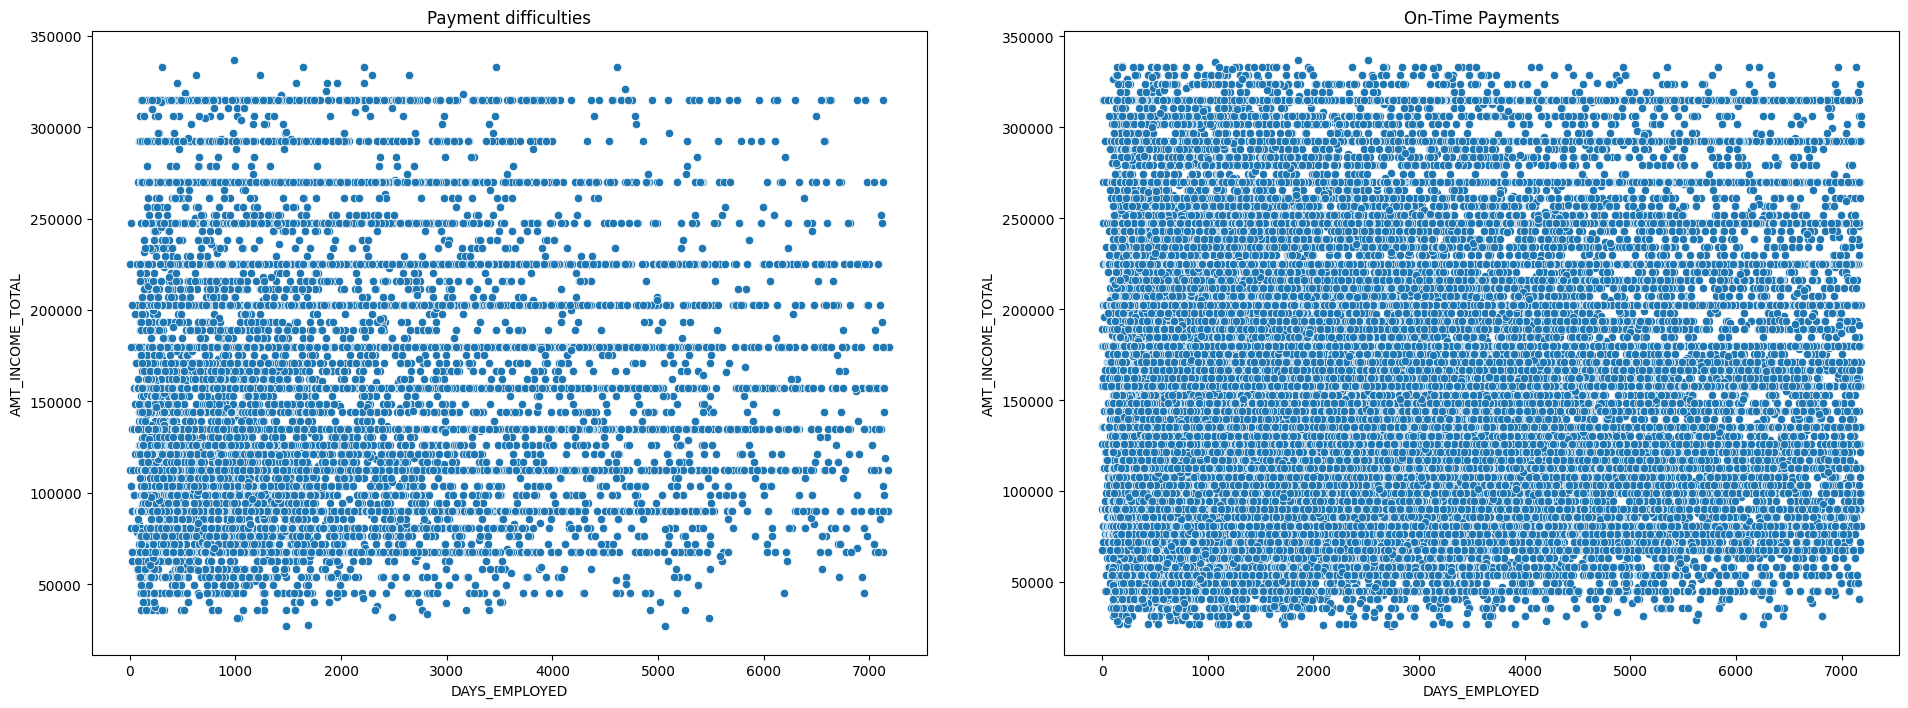

In [578]:
bi_numerical_analysis(df0, df1, column_1='DAYS_EMPLOYED', column_2='AMT_INCOME_TOTAL')

**Observation**
- Clients who have been working for a long time (>7000 days) make payments on time, but this category of clients is not in the "Payment Difficulties" group
- Even in the "Payment Difficulties" group, there are few clients who have been working for more than 4000 days

### Analysis of `AMT_CREDIT` vs `DAYS_BIRTH`

Constructing a scatter diagram for comparison with removed emissions


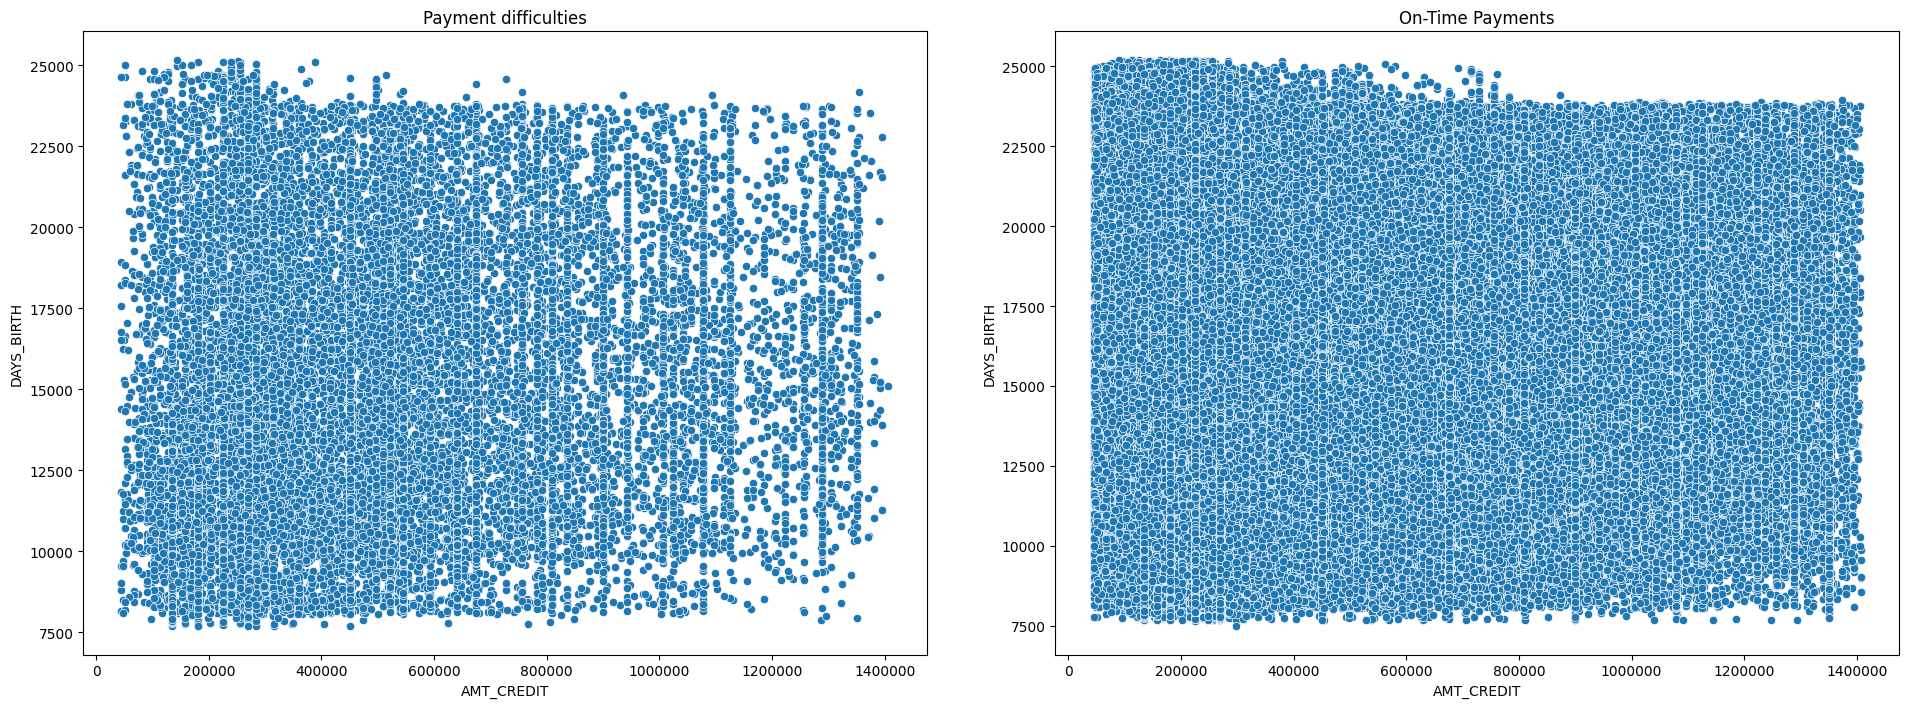

In [579]:
bi_numerical_analysis(df0, df1, column_1='AMT_CREDIT', column_2='DAYS_BIRTH')

**Observation**
- There is no significant correlation between birthday and loan amount

## Continuous and categorical variables

In [580]:
def draw_boxplot(df, categorical, continuous, max_continuous, title, hue_column, subplot_position):

    plt.subplot(1, 2, subplot_position)
    plt.title(title)
    red_diamond = dict(markerfacecolor='r', marker='D')
    sns.boxplot(x=categorical,
                y=df[df[continuous] < max_continuous][continuous],
                data=df,
                flierprops=red_diamond,
                order=sorted(df[categorical].unique(), reverse=True),
                hue=hue_column, hue_order=sorted(df[hue_column].unique(), reverse=True))
    plt.ticklabel_format(style='plain', axis='y')
    plt.xticks(rotation=90)

def bi_boxplot(categorical, continuous, max_continuous1, max_continuous0, hue_column):

    plt.figure(figsize=(16, 10))

    # Payment Difficulties
    draw_boxplot(df1, categorical, continuous, max_continuous1, 'Payment Difficulties', hue_column, 1)

    # On-Time Payments
    draw_boxplot(df0, categorical, continuous, max_continuous0, 'On-Time Payments', hue_column, 2)

    plt.tight_layout(pad=4)
    plt.show()

### Analysis of `AMT_CREDIT` vs `NAME_EDUCATION_TYPE` vs `CODE_GENDER`

In [349]:
max_value1_AMT_CREDIT = outlier_range(df1,'AMT_CREDIT')
max_value1_AMT_CREDIT

np.float64(1406688.75)

In [350]:
max_value0_AMT_CREDIT = outlier_range(df0,'AMT_CREDIT')
max_value0_AMT_CREDIT

np.float64(1620000.0)

In [351]:
df1.groupby(by = ['NAME_EDUCATION_TYPE','CODE_GENDER']).AMT_CREDIT.describe().head()

count      mean       std       min  \
NAME_EDUCATION_TYPE CODE_GENDER                                         
Academic degree     F              3.00 950245.50 504711.38 544491.00   
Higher education    F           2438.00 648500.58 410415.70  47970.00   
                    M           1571.00 642070.94 409695.93  45000.00   
Incomplete higher   F            504.00 520150.35 352227.49  91692.00   
                    M            368.00 554723.82 347843.71  74628.00   

                                      25%       50%        75%        max  
NAME_EDUCATION_TYPE CODE_GENDER                                            
Academic degree     F           667660.50 790830.00 1153122.75 1515415.50  
Higher education    F           323595.00 545040.00  877500.00 2687355.00  
                    M           329202.00 545040.00  832797.00 2695500.00  
Incomplete higher   F           269550.00 450000.00  675000.00 2695500.00  
                    M           284400.00 497520.00  699976.12 2013840.00

In [352]:
df0.groupby(by = ['NAME_EDUCATION_TYPE','CODE_GENDER']).AMT_CREDIT.describe().head()

count      mean       std       min  \
NAME_EDUCATION_TYPE CODE_GENDER                                          
Academic degree     F              97.00 708770.74 463052.42 130824.00   
                    M              64.00 735235.38 497739.97  74182.50   
Higher education    F           47852.00 682485.00 456642.78  45000.00   
                    M           23002.00 713144.54 486073.66  45000.00   
Incomplete higher   F            5780.00 555340.53 385980.60  45000.00   

                                      25%       50%        75%        max  
NAME_EDUCATION_TYPE CODE_GENDER                                            
Academic degree     F           354469.50 607500.00 1006920.00 2463840.00  
                    M           309519.00 610056.00 1036890.00 1984500.00  
Higher education    F           302206.50 568057.50  916470.00 4050000.00  
                    M           315000.00 592560.00  973503.00 4050000.00  
Incomplete higher   F           253737.00 454500.00  760225.50 2517300.00

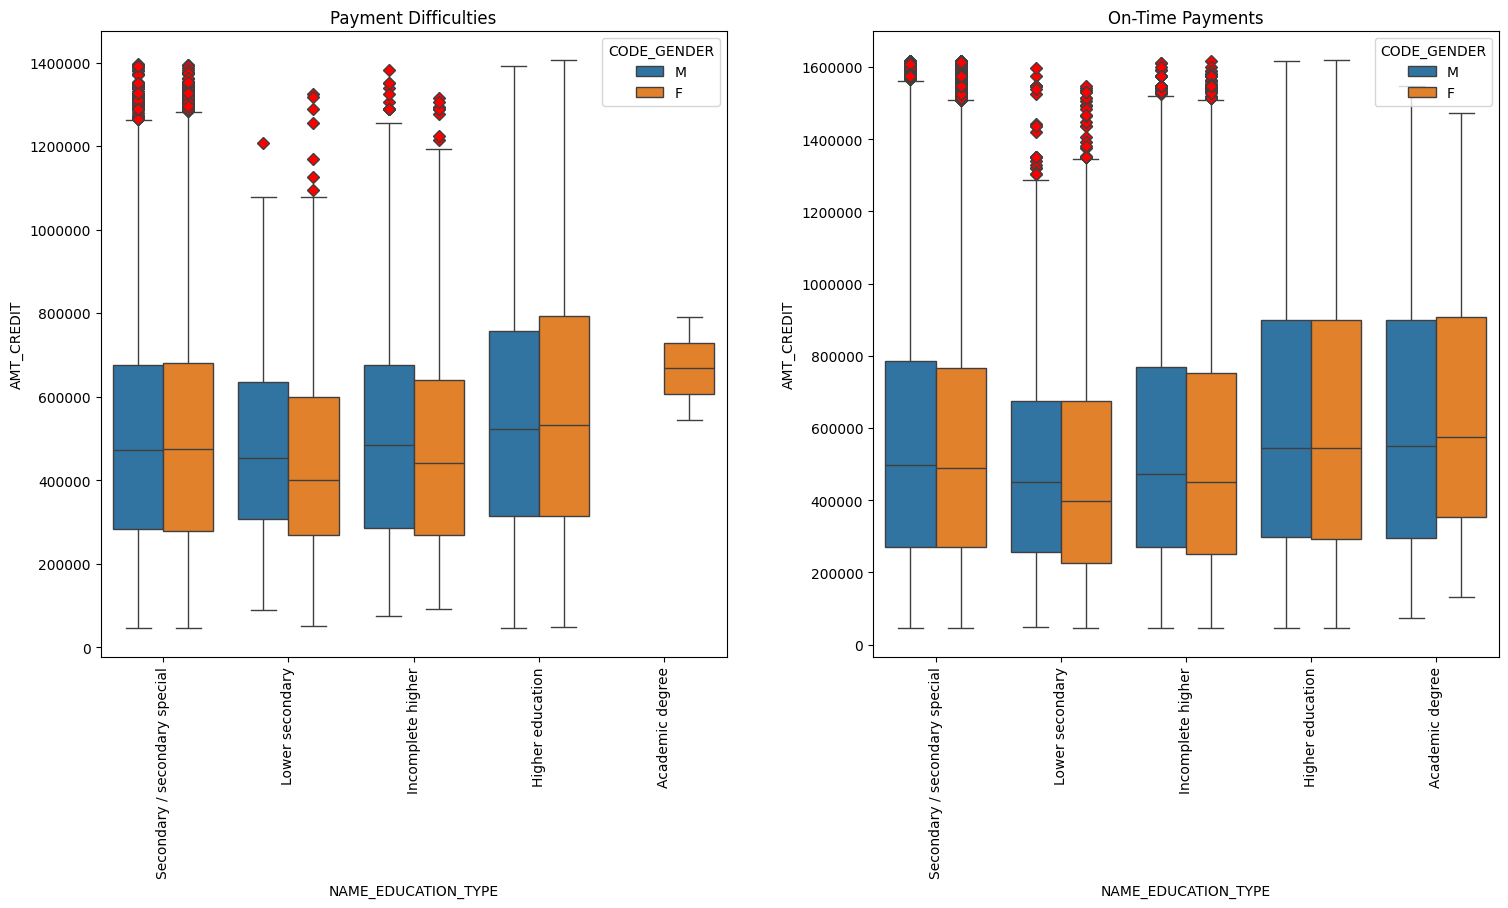

In [353]:
bi_boxplot('NAME_EDUCATION_TYPE','AMT_CREDIT',max_value1_AMT_CREDIT, max_value0_AMT_CREDIT, 'CODE_GENDER')

**Observation**
- Customers with a "college degree" have a wide range of loans for timely payments, while for customers with payment problems this range is much lower
- If you look at the aggregate statistics, customers with a "higher education" and payment problems take out a mean and median loan in a much larger range than customers with timely payments.
- Male customers with a "higher education" always pay their loans on time

In [581]:
def numeric_vs_categorical_analysis(df0, df1, column_1, column_2, column_3):
  max_value1_column_1 = outlier_range(df1, column_1)
  max_value0_column_1 = outlier_range(df0, column_1)

  display(df1.groupby(by = [column_2, column_3])[column_1].describe().head())


  display(df0.groupby(by = [column_2, column_3])[column_1].describe().head())

  bi_boxplot(column_2, column_1, max_value1_column_1, max_value0_column_1, column_3)

### Analysis of `AMT_INCOME_TOTAL` vs `NAME_FAMILY_STATUS` vs `CODE_GENDER`

count      mean        std      min  \
NAME_FAMILY_STATUS CODE_GENDER                                         
Civil marriage     F           1753.00 153620.72  101045.86 25650.00   
                   M           1208.00 173949.99   92449.17 36000.00   
Married            F           8324.00 159907.85 1283283.40 27000.00   
                   M           6526.00 182233.06   94787.77 31500.00   
Separated          F           1045.00 161159.55   82633.33 36000.00   

                                     25%       50%       75%          max  
NAME_FAMILY_STATUS CODE_GENDER                                             
Civil marriage     F           108000.00 135000.00 180000.00   3150000.00  
                   M           117000.00 157500.00 202500.00   1350000.00  
Married            F            90000.00 135000.00 180000.00 117000000.00  
                   M           126000.00 157500.00 225000.00   1890000.00  
Separated          F           112500.00 135000.00 202500.00    832500.00

count      mean       std      min  \
NAME_FAMILY_STATUS CODE_GENDER                                          
Civil marriage     F            19017.00 162086.05 106811.49 27000.00   
                   M             7797.00 184126.29 106559.49 27000.00   
Married            F           114125.00 154289.53  88593.43 26100.00   
                   M            67459.00 199592.83 147599.76 27000.00   
Separated          F            14416.00 166374.21  94782.18 27000.00   

                                     25%       50%       75%         max  
NAME_FAMILY_STATUS CODE_GENDER                                            
Civil marriage     F           112500.00 135000.00 202500.00  9000000.00  
                   M           121500.00 157500.00 225000.00  3825000.00  
Married            F            94500.00 135000.00 180000.00  3600000.00  
                   M           135000.00 180000.00 225000.00 18000090.00  
Separated          F           112500.00 139500.00 202500.00  2250000.00

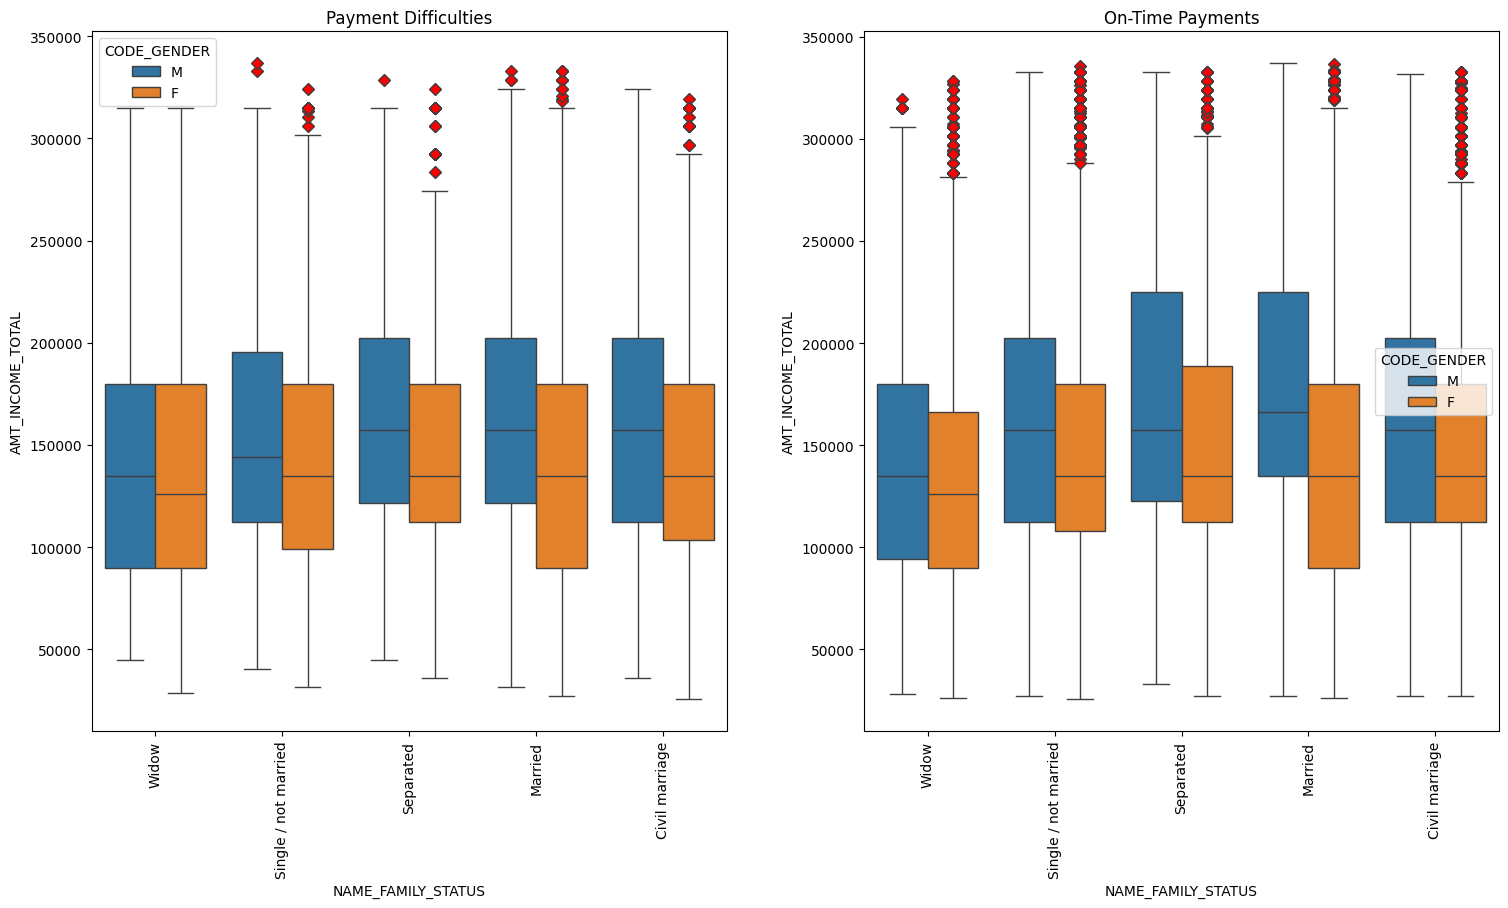

In [358]:
numeric_vs_categorical_analysis(df0, df1, 'AMT_INCOME_TOTAL', 'NAME_FAMILY_STATUS', 'CODE_GENDER')

**Observation**
- `Married` clients have a slightly higher average/median income in the ``Timely Payments'' category than in the `Payment Difficulties'' category

### Analysis of `AMT_INCOME_TOTAL` vs `YEARS_BIRTH_CATEGORY` vs `NAME_HOUSING_TYPE`

count      mean      std      min  \
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE                                         
20-30                Co-op apartment       40.00 148628.70 59516.24 67500.00   
                     House / apartment   4201.00 151897.22 70874.65 31500.00   
                     Municipal apartment  153.00 153608.82 78282.79 45000.00   
                     Office apartment      40.00 147375.00 50817.26 67500.00   
                     Rented apartment     229.00 144210.10 59998.66 45000.00   

                                               25%       50%       75%  \
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE                                   
20-30                Co-op apartment     110250.00 135000.00 185625.00   
                     House / apartment   112500.00 135000.00 180000.00   
                     Municipal apartment 108000.00 135000.00 180000.00   
                     Office apartment    112500.00 135000.00 180000.00   
                     Rented apartment     99000.00 135000.00 180000.00   

                                               max  
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE              
20-30                Co-op apartment     360000.00  
                     House / apartment   810000.00  
                     Municipal apartment 675000.00  
                     Office apartment    270000.00  
                     Rented apartment    405000.00

count      mean       std  \
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE                                  
20-30                Co-op apartment       298.00 161153.15  76171.26   
                     House / apartment   33165.00 163944.39  92313.18   
                     Municipal apartment  1099.00 166235.08  88698.47   
                     Office apartment      455.00 177960.18 115765.13   
                     Rented apartment     1535.00 153028.06  70748.99   

                                              min       25%       50%  \
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE                                  
20-30                Co-op apartment     45000.00 112500.00 139500.00   
                     House / apartment   27000.00 112500.00 141264.00   
                     Municipal apartment 45000.00 112500.00 144000.00   
                     Office apartment    36000.00 112500.00 157500.00   
                     Rented apartment    29250.00 109125.00 135000.00   

                                               75%        max  
YEARS_BIRTH_CATEGORY NAME_HOUSING_TYPE                         
20-30                Co-op apartment     202500.00  720000.00  
                     House / apartment   202500.00 4500000.00  
                     Municipal apartment 202500.00 1417500.00  
                     Office apartment    225000.00 1800000.00  
                     Rented apartment    180000.00  742500.00

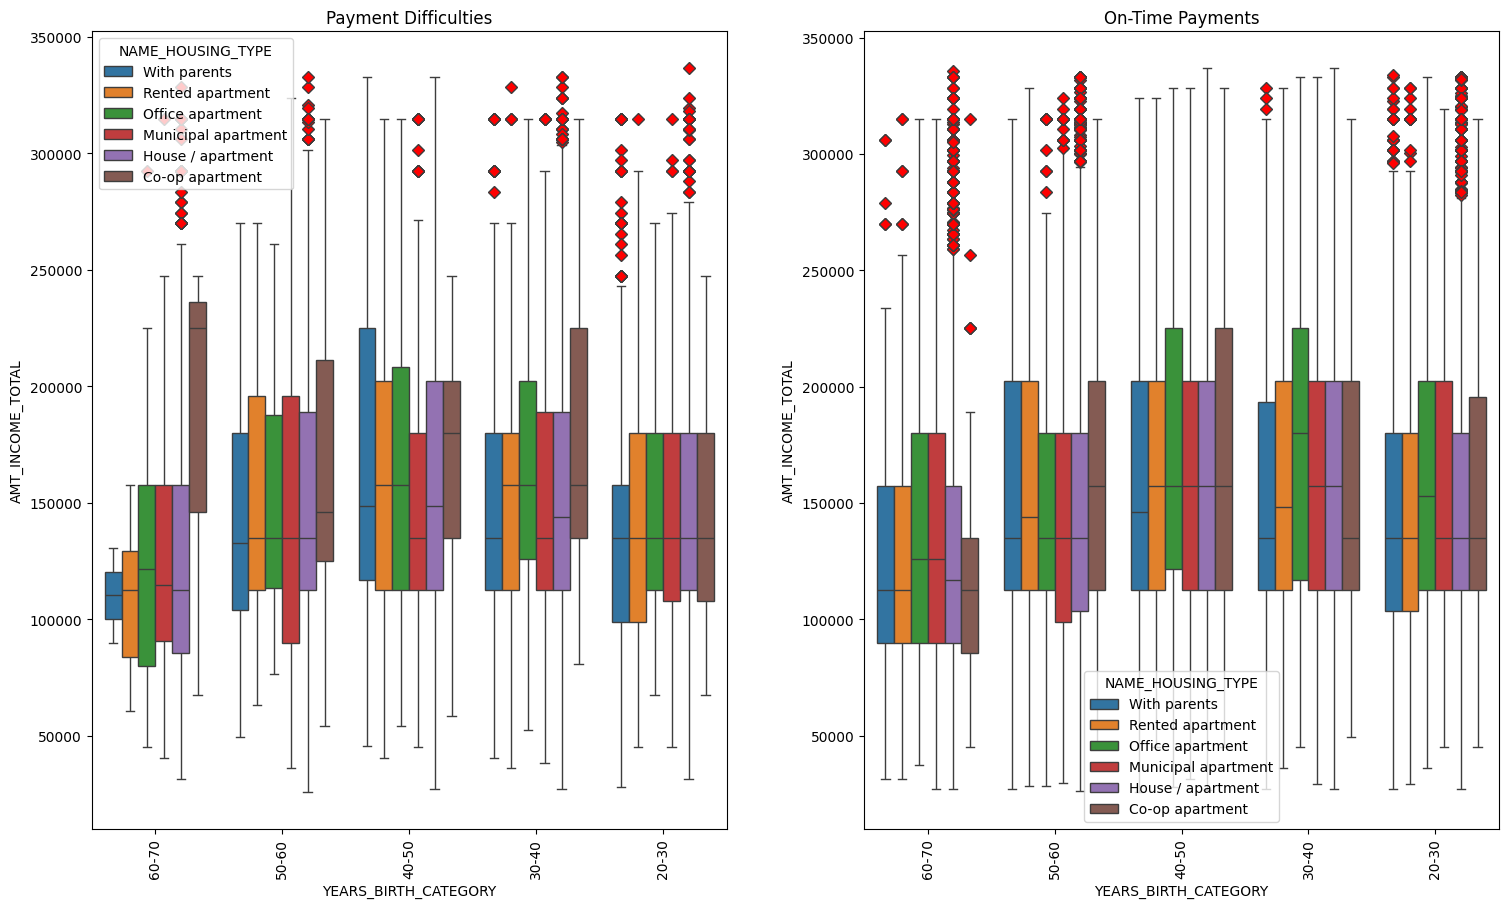

In [359]:
numeric_vs_categorical_analysis(df0, df1, 'AMT_INCOME_TOTAL', 'YEARS_BIRTH_CATEGORY', 'NAME_HOUSING_TYPE')

**Observation**
- Clients aged `60-70` living in `Co-op apartment` have a very high income range in the `Difficult to pay` category than in the `Timely payments` category.
- Clients aged `20-30` living in `Office apartment` have a very high median income in the `Timely payments` category compared to the `Difficult to pay` category.

### Analysis of `AMT_GOODS_PRICE` vs `NAME_INCOME_TYPE` vs `CODE_GENDER`

count      mean       std       min  \
NAME_INCOME_TYPE     CODE_GENDER                                         
Commercial associate F           2968.00 536304.02 353598.52  45000.00   
                     M           2392.00 526355.38 335793.33  45000.00   
Maternity leave      F              2.00 929250.00 715945.62 423000.00   
Pensioner            F           2243.00 494976.12 316903.86  45000.00   
                     M            739.00 486543.08 321104.43  45000.00   

                                       25%       50%        75%        max  
NAME_INCOME_TYPE     CODE_GENDER                                            
Commercial associate F           270000.00 450000.00  675000.00 3600000.00  
                     M           270000.00 450000.00  675000.00 2961000.00  
Maternity leave      F           676125.00 929250.00 1182375.00 1435500.00  
Pensioner            F           229500.00 450000.00  675000.00 2173500.00  
                     M           229500.00 450000.00  675000.00 1800000.00

count       mean        std       min  \
NAME_INCOME_TYPE     CODE_GENDER                                            
Businessman          F               3.00 1125000.00 1031079.53 225000.00   
                     M               7.00 1272857.14  755104.06 495000.00   
Commercial associate F           41552.00  602132.71  400701.09  45000.00   
                     M           24705.00  620123.74  422345.24  45000.00   
Maternity leave      F               2.00  562500.00  350017.86 315000.00   

                                       25%        50%        75%        max  
NAME_INCOME_TYPE     CODE_GENDER                                             
Businessman          F           562500.00  900000.00 1575000.00 2250000.00  
                     M           607500.00 1350000.00 1800000.00 2250000.00  
Commercial associate F           270000.00  472500.00  837000.00 4050000.00  
                     M           270000.00  472500.00  900000.00 4050000.00  
Maternity leave      F           438750.00  562500.00  686250.00  810000.00

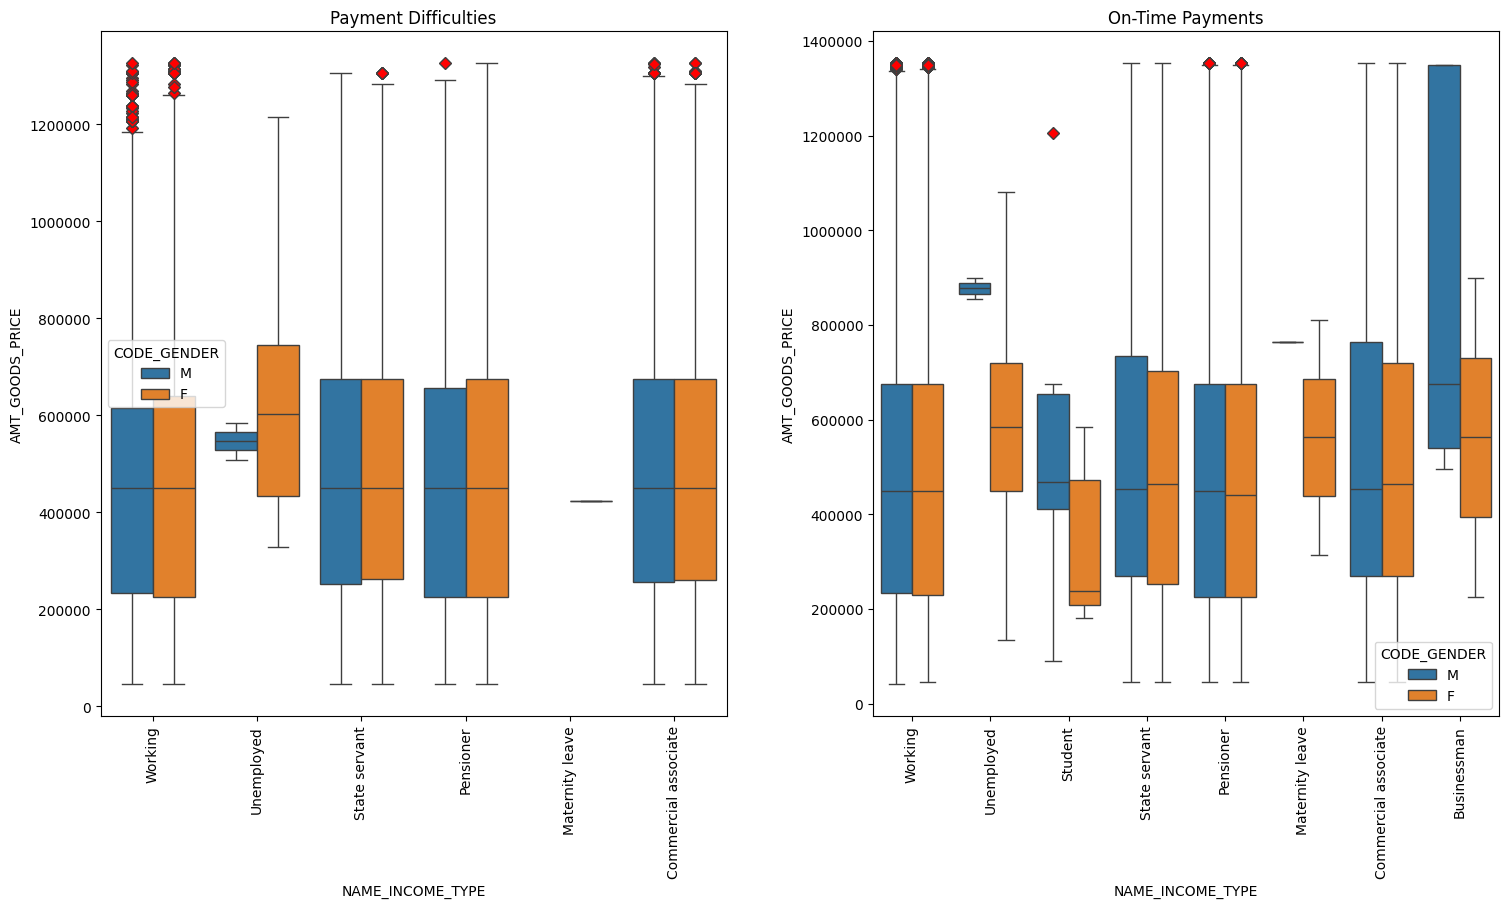

In [361]:
numeric_vs_categorical_analysis(df0, df1, 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'CODE_GENDER')

**Observations**
- Customers who are `Unemployed` and `Male` have a very high price of goods in `Timely Payments` than `Payment Difficulties`
- Customers who are `Student` and `Male` or `Female` make their payments on time. They are completely absent in `Payment Difficulties` category. `Student` category seems attractive for lending.
- Customers who are `Businessman` and `Male` or `Female` make their payments on time. They are completely absent in `Payment Difficulties` category. `Businessman` seems attractive for lending.

### Analysis of `AMT_INCOME_TOTAL` vs `OCCUPATION_TYPE` vs `CODE_GENDER`

count      mean      std      min       25%  \
OCCUPATION_TYPE CODE_GENDER                                                
Accountants     F           457.00 174840.64 79021.04 54000.00 112500.00   
                M            17.00 202367.65 98623.66 81000.00 121500.00   
Cleaning staff  F           410.00 128907.99 70328.23 31500.00  90000.00   
                M            37.00 119493.24 45786.21 45000.00  90000.00   
Cooking staff   F           555.00 129298.38 55531.88 32400.00  90000.00   

                                  50%       75%       max  
OCCUPATION_TYPE CODE_GENDER                                
Accountants     F           157500.00 202500.00 540000.00  
                M           180000.00 252000.00 438750.00  
Cleaning staff  F           112500.00 157500.00 720000.00  
                M           112500.00 135000.00 247500.00  
Cooking staff   F           112500.00 157500.00 405000.00

count      mean       std      min       25%  \
OCCUPATION_TYPE CODE_GENDER                                                  
Accountants     F           9072.00 194324.51 109135.61 27000.00 130500.00   
                M            267.00 236490.89 131795.33 54000.00 141750.00   
Cleaning staff  F           3904.00 130602.05  63495.05 25650.00  90000.00   
                M            302.00 137172.52  64373.09 31500.00  90000.00   
Cooking staff   F           4830.00 134460.40  60213.56 27000.00  90000.00   

                                  50%       75%        max  
OCCUPATION_TYPE CODE_GENDER                                 
Accountants     F           175500.00 225000.00 2214117.00  
                M           216000.00 270000.00 1035000.00  
Cleaning staff  F           112500.00 157500.00 1080000.00  
                M           132750.00 169875.00  450000.00  
Cooking staff   F           121500.00 157500.00  540000.00

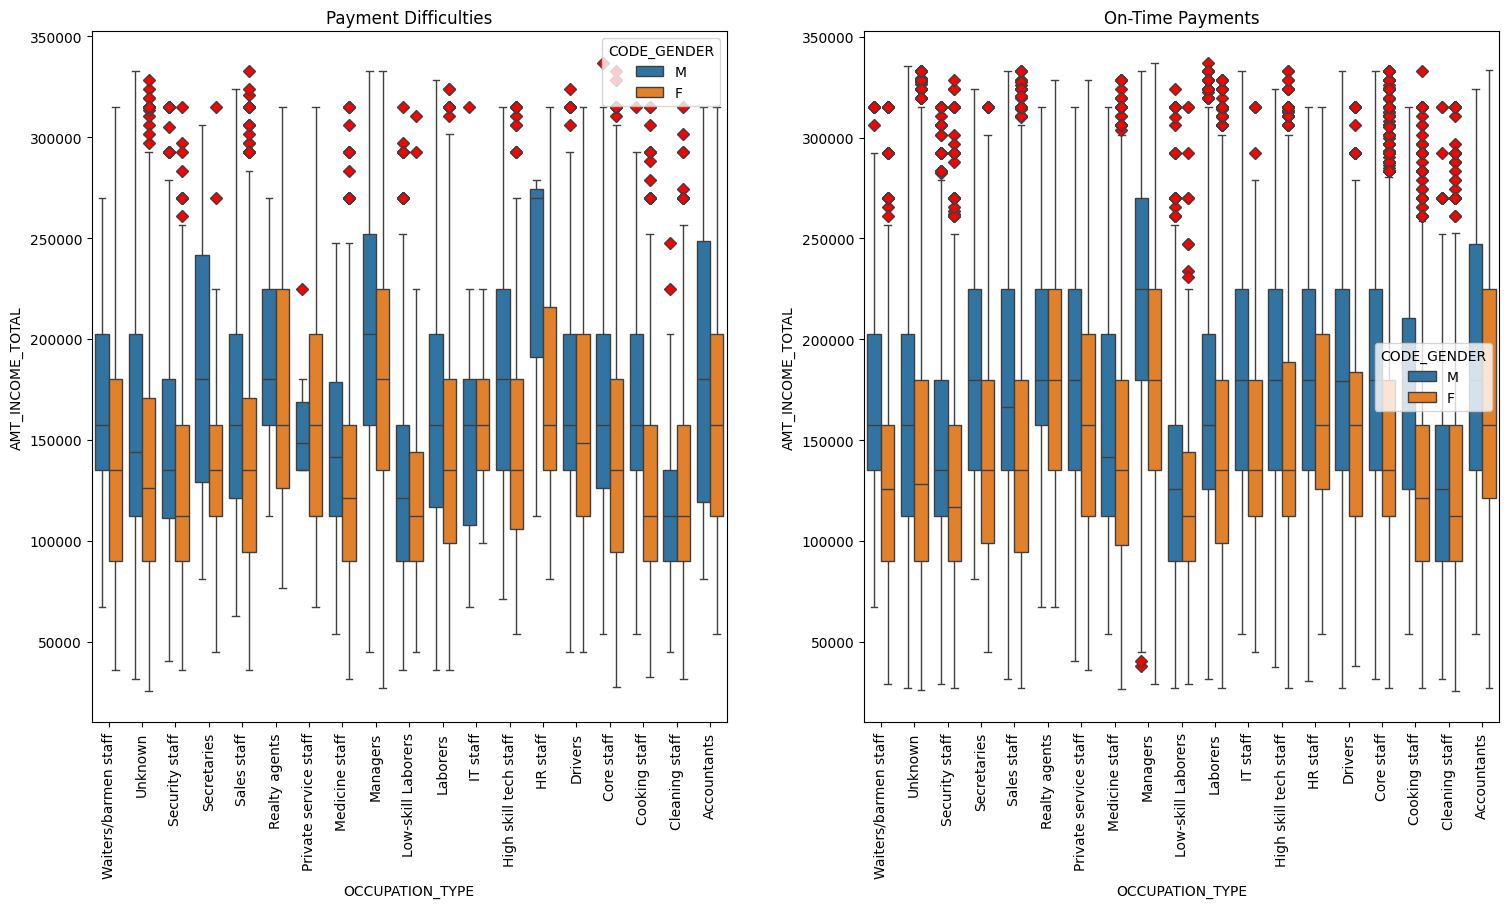

In [360]:
numeric_vs_categorical_analysis(df0, df1, 'AMT_INCOME_TOTAL', 'OCCUPATION_TYPE', 'CODE_GENDER')

**Observations**
- Customers belonging to the category `Waiters/barmen staff` and `Female` have a lower average income in the category `Timely payments` than in the category `Payment difficulties`
- Customers belonging to the category `Cleaning staff` and `Female` have a higher average income in the category `Timely payments` than in the category `Payment difficulties`
- Customers belonging to the category `HR staff` and `Male` have a higher average income in the category `Payment difficulties` than in the category `Timely payments`
- Customers belonging to the category `Managers` and `Male` have a higher average income in the category `Timely payments` than in the category `Payment difficulties`

## Categorical and categorical variables

In [363]:
def bi_countplot_target(df0, df1, column, hue_column):
    group_name = f'Normalized distribution of values ​​by category: {column}'
    print(group_name.upper())

    pltname = 'Client with payment difficulties'
    unique_hue_values = df1[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,4)

    proportions = df1.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[0], title=pltname)

    for container in ax.containers:
      ax.bar_label(container, fmt='{:,.1f}%')

    pltname = 'Customers with timely payments'
    unique_hue_values = df0[hue_column].unique()

    proportions = df0.groupby(hue_column)[column].value_counts (normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
    by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container, fmt='{:,.1f}%')

    plt.show()


    #------------
    group_name = f'Number of values ​​per category {column}'
    print(group_name.upper())

    pltname = 'Client with timely payments'
    unique_hue_values = df1[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,4)
    counts = df1.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
      by=unique_hue_values [0], ascending=False
      ).plot.bar(ax=axes [0], title=pltname )

    for container in ax.containers:
      ax.bar_label(container)

    pltname = 'Client with timely payments'
    unique_hue_values = df0[hue_column].unique()
    counts = df0.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values (
      by=unique_hue_values[0], ascending=False
      ).plot.bar(ax=axes[1], title=pltname)

    for container in ax. containers:
      ax.bar_label(container)

    plt.show()

NORMALIZED DISTRIBUTION OF VALUES ​​BY CATEGORY: NAME_INCOME_TYPE


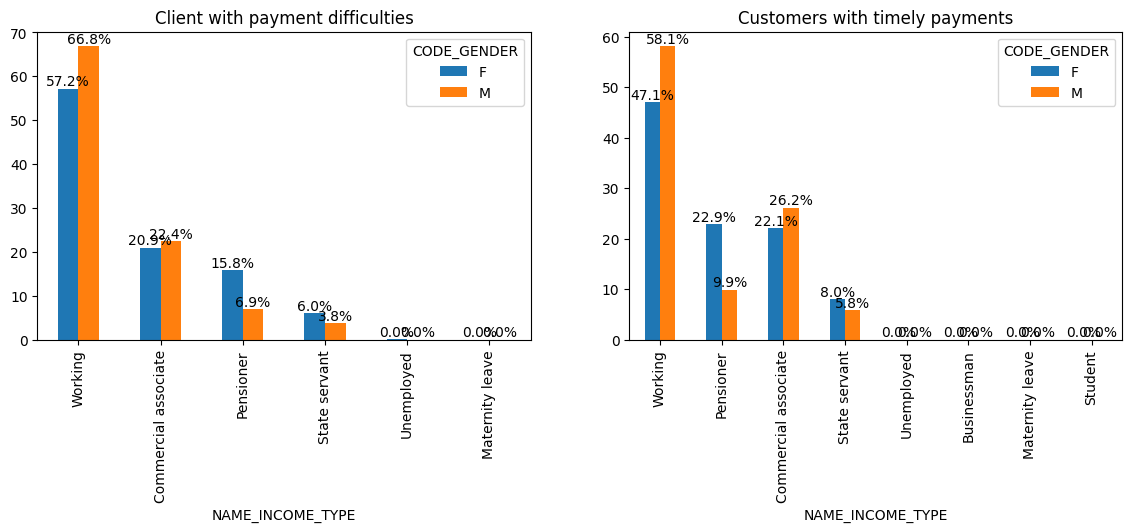

NUMBER OF VALUES ​​PER CATEGORY NAME_INCOME_TYPE


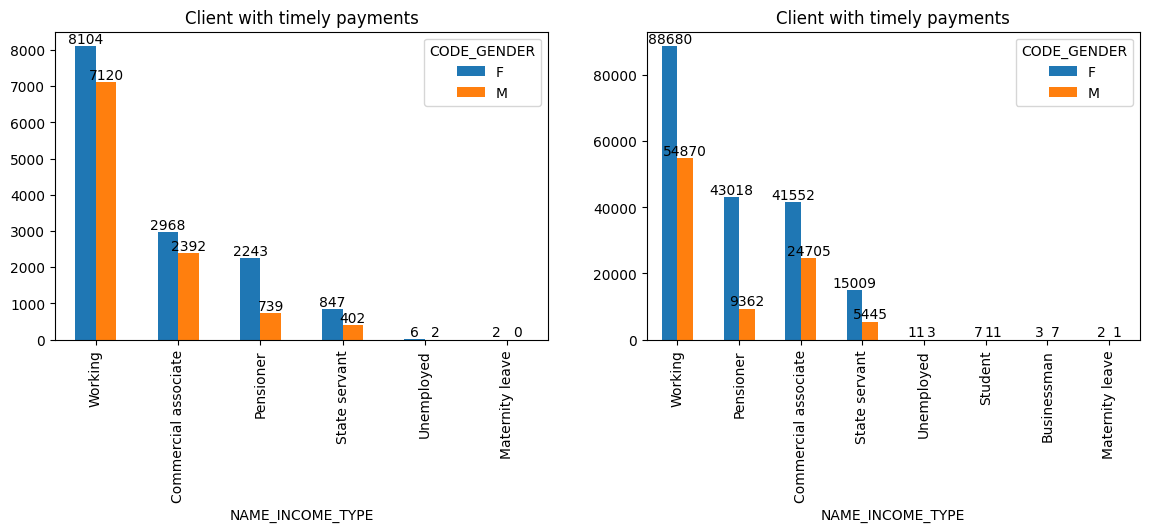

In [364]:
bi_countplot_target(df0, df1, 'NAME_INCOME_TYPE','CODE_GENDER')

**Observations**
- `Working` and `Male` customers have more difficulty paying compared to those who pay on time
- `Pensioner` and `Female` customers have more difficulty paying compared to those who pay on time
- `Businessman` and `Student` customers make payments on time, although their history is short

### Analysis of NAME_EDUCATION_TYPE vs CODE_GENDER

NORMALIZED DISTRIBUTION OF VALUES ​​BY CATEGORY: NAME_EDUCATION_TYPE


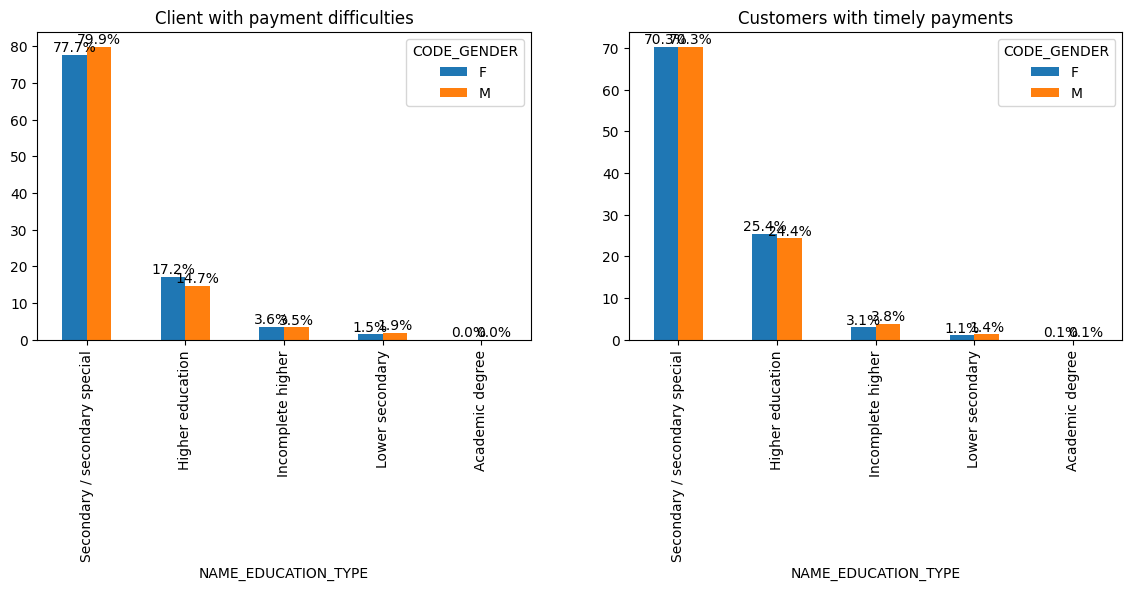

NUMBER OF VALUES ​​PER CATEGORY NAME_EDUCATION_TYPE


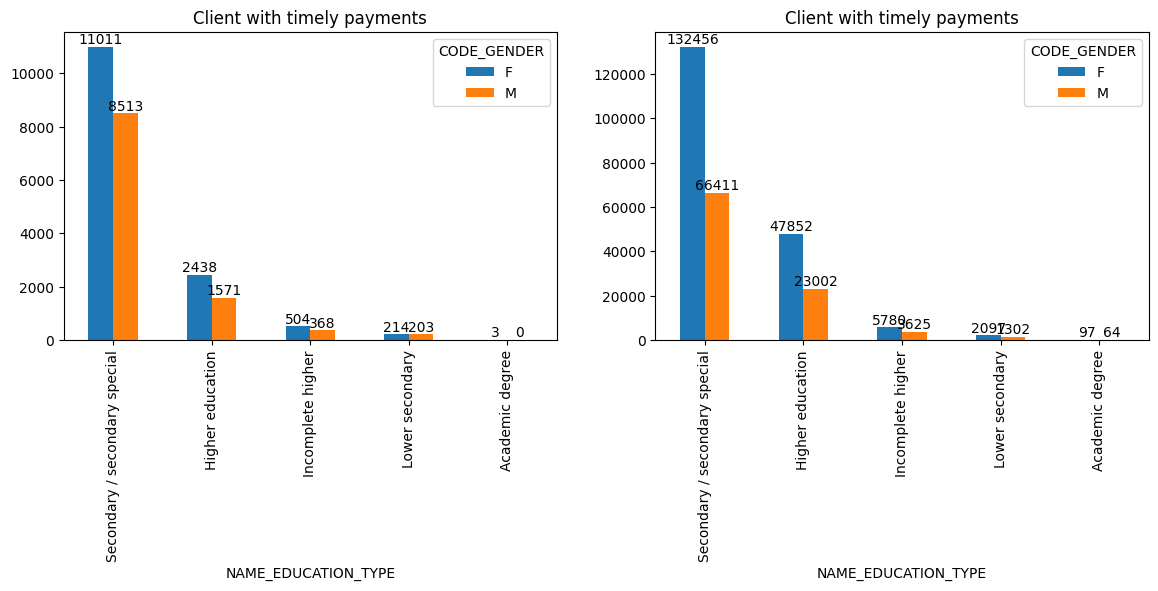

In [365]:
bi_countplot_target(df0, df1, 'NAME_EDUCATION_TYPE','CODE_GENDER')

**Observation**
- Customers with `Secondary/Secondary special` education and `Male` have more difficulties with payment compared to those who pay on time
- Customers with `Higher education` and `Famale` have more problems with timely payments compared to those who have difficulties with paymentти.

### Analysis of NAME_FAMILY_STATUS vs OCCUPATION_TYPE

NORMALIZED DISTRIBUTION OF VALUES ​​BY CATEGORY: OCCUPATION_TYPE


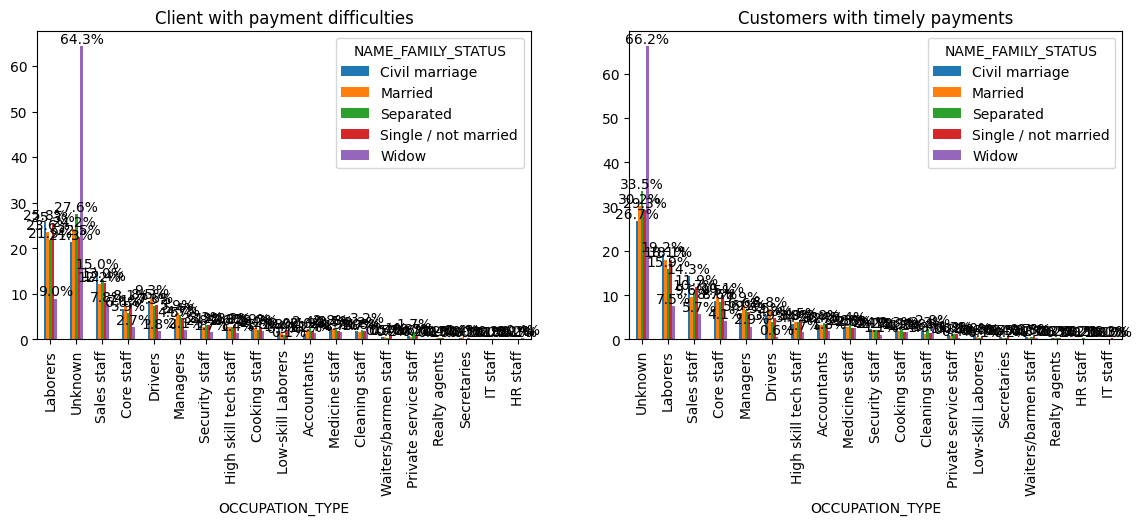

NUMBER OF VALUES ​​PER CATEGORY OCCUPATION_TYPE


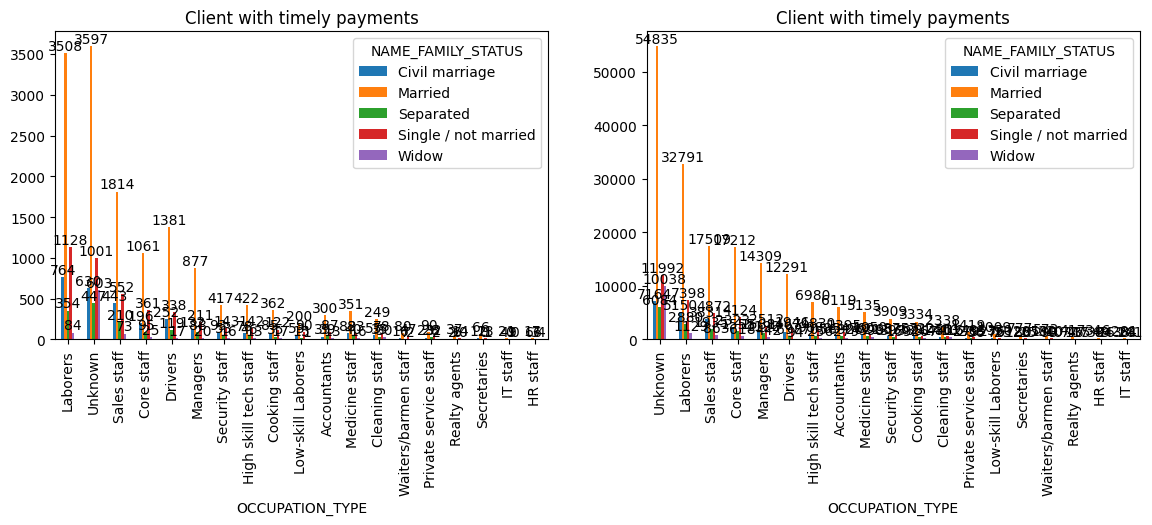

In [366]:
bi_countplot_target(df0, df1, 'OCCUPATION_TYPE','NAME_FAMILY_STATUS')

**Observations**
- Customers who are `Single\not married`, `Married` and `Civil married`, as well as `Waiters\barmen staff` have more difficulty paying compared to those who pay on time
- Customers who are `Married` and `Drivers` have more difficulty paying compared to those who pay on time
- `Married` and `Accountants` have better on-time payment rates

### Analysis of OCCUPATION_TYPE VS NAME_CONTRACT_TYPE

NORMALIZED DISTRIBUTION OF VALUES ​​BY CATEGORY: OCCUPATION_TYPE


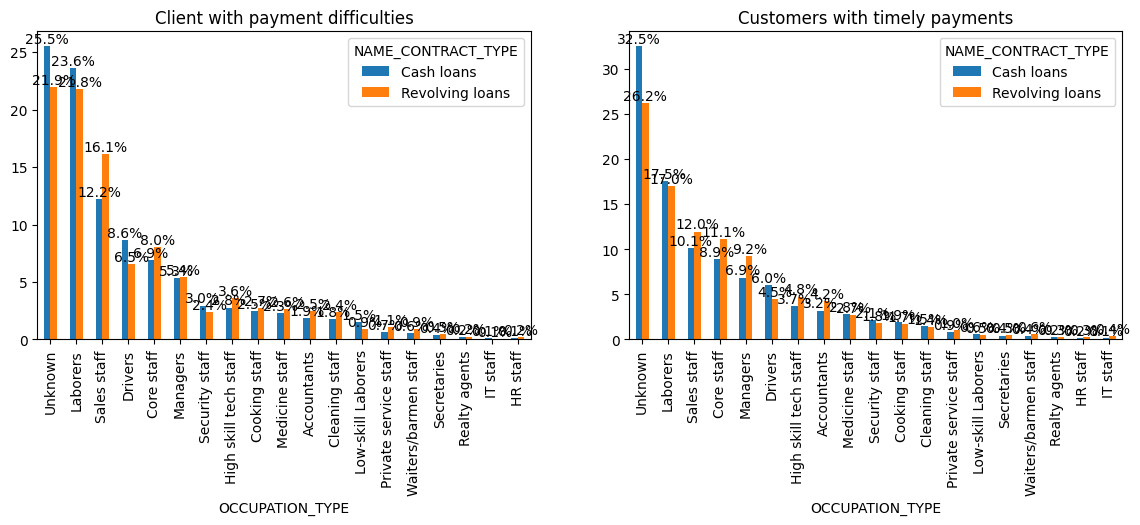

NUMBER OF VALUES ​​PER CATEGORY OCCUPATION_TYPE


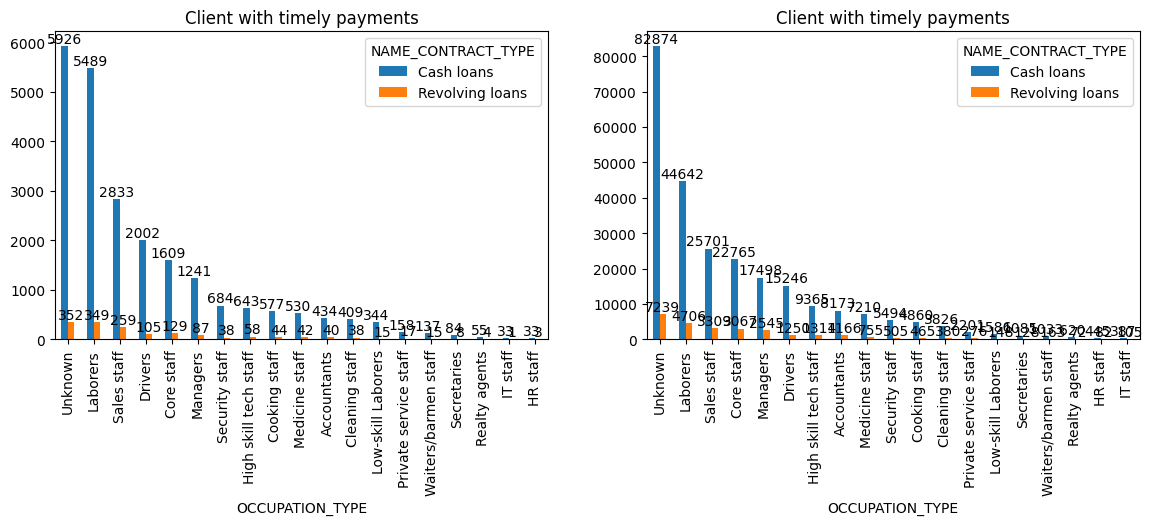

In [367]:
bi_countplot_target(df0, df1, 'OCCUPATION_TYPE', 'NAME_CONTRACT_TYPE')

**Observation**
- Customers who are `Sales staff`, `Laborers`, `Drivers` and have `Cash loans` have more difficulty in paying compared to those who pay on time

# Conclusion: Categories of clients to focus on when granting a loan

- Clients who have been working for more than 19 years
- Clients aged 30-40 and 40-50
- Married clients
- Male clients with higher education
- Students and businessmen.